In [ ]:
# ===============================

In [ ]:
# كود تدريب الخوارزمية

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms #لتحويل الصور ومعالجتها قبل إدخالها إلى نموذج التعلم العميق.
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns #رسم المخططات الإحصائية والبيانية
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
from tqdm import tqdm #تُستخدم لإظهار شريط تقدم (Progress Bar)
import warnings
import gc #إدارة الذاكرة والتخلص من الكائنات (Objects) التي لم يعد البرنامج يستخدمها
import os
from pathlib import Path
from itertools import cycle #للتعامل مع التكرارات (Iterators)
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
warnings.filterwarnings('ignore')

# Set matplotlib to non-interactive mode
plt.ioff()  # Turn off interactive mode
import matplotlib
matplotlib.use('Agg')  # Use non-GUI backend

# Set style for professional plots
plt.style.use('default')
sns.set_palette("husl")

# Memory optimization
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.cuda.empty_cache()
gc.collect()

# Device setup
try:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if torch.cuda.is_available():
        torch.cuda.set_per_process_memory_fraction(0.8)
        print(f"GPU: {torch.cuda.get_device_name()}")
        print(f"Available Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
except Exception:
    device = torch.device('cpu')
    print("Using CPU")

print(f"Using device: {device}")


# ============================
# Dataset Class
# ============================
class BrainTumorMRIDataset(Dataset):
    def __init__(self, data_dir, transform=None, subset_ratio=1.0):
        self.data_dir = Path(data_dir)
        self.transform = transform
        self.subset_ratio = subset_ratio

        self.class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
        self.class_to_idx = {class_name: idx for idx, class_name in enumerate(self.class_names)}

        self.samples = []
        self._scan_directory()

        if subset_ratio < 1.0:
            subset_size = int(len(self.samples) * subset_ratio)
            self.samples = self.samples[:subset_size]

        print(f"📁 Found {len(self.samples)} images")
        self._print_class_distribution()

    def _scan_directory(self):
        training_folder = self.data_dir / "Training"
        if training_folder.exists():
            print(f"📂 Using Training directory: {training_folder}")

            seen_paths = set()

            for class_name in self.class_names:
                class_folder = training_folder / class_name
                if class_folder.exists():
                    label = self.class_to_idx[class_name]

                    # البحث عن أي صورة بدون تحديد الامتداد
                    for img_path in class_folder.glob('*'):
                        if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                            img_path_str = str(img_path.resolve())
                            if img_path_str not in seen_paths:
                                seen_paths.add(img_path_str)
                                self.samples.append((img_path_str, label))
        else:
            print("❌ Training folder not found!")

        print(f"✅ تم تحميل {len(self.samples)} صورة فريدة")

    def _print_class_distribution(self):
        class_counts = [0] * len(self.class_names)
        for _, label in self.samples:
            class_counts[label] += 1

        print("📊 Class Distribution:")
        for class_name, count in zip(self.class_names, class_counts):
            print(f"  {class_name}: {count} images")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            # Return black image as fallback
            black_img = Image.new('RGB', (128, 128), (0, 0, 0))
            if self.transform:
                return self.transform(black_img), label
            return torch.zeros(3, 128, 128), label


# ============================
# Patent Components
# ============================
class MicroAdaptiveFeatureExtractor(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        reduced_ch = max(1, channels // reduction)

        self.spatial_conv = nn.Conv2d(channels, 1, 1)
        self.channel_avg = nn.AdaptiveAvgPool2d(1)
        self.channel_fc = nn.Conv2d(channels, reduced_ch, 1)
        self.channel_out = nn.Conv2d(reduced_ch, channels, 1)
        self.alpha = nn.Parameter(torch.tensor(0.3), requires_grad=True)

    def forward(self, x):
        spatial_weights = torch.sigmoid(self.spatial_conv(x))
        x_spatial = x * spatial_weights

        channel_pool = self.channel_avg(x_spatial)
        channel_weights = torch.sigmoid(self.channel_out(F.relu(self.channel_fc(channel_pool))))
        x_enhanced = x_spatial * channel_weights

        return x + self.alpha * x_enhanced


class MicroMultiScaleProcessor(nn.Module):
    def __init__(self, channels):
        super().__init__()
        inter = max(8, channels // 4)
        while inter % 4 != 0 and inter > 4:
            inter -= 1
        if inter < 4:
            inter = 4

        self.scale1 = nn.Conv2d(channels, inter, 1, bias=False)
        self.scale3 = nn.Conv2d(channels, inter, 3, padding=1, bias=False)

        if channels >= 8 and inter >= 4:
            groups = 1
            for g in [8, 4, 2]:
                if channels % g == 0:
                    groups = g
                    break
            self.scale3dw = nn.Conv2d(channels, inter, 3, padding=1, groups=groups, bias=False)
        else:
            self.scale3dw = nn.Conv2d(channels, inter, 3, padding=1, bias=False)

        self.fusion = nn.Conv2d(inter * 3, channels, 1, bias=False)
        self.beta = nn.Parameter(torch.tensor(0.3), requires_grad=True)

    def forward(self, x):
        s1 = F.relu(self.scale1(x))
        s3 = F.relu(self.scale3(x))
        s3dw = F.relu(self.scale3dw(x))

        combined = torch.cat([s1, s3, s3dw], dim=1)
        fused = self.fusion(combined)

        return F.relu(x + self.beta * fused)


class MicroIntelligentPooling(nn.Module):
    def __init__(self, channels):
        super().__init__()
        decision_ch = max(2, channels // 8)

        self.decision = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, decision_ch, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(decision_ch, 2, 1),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        B, C, H, W = x.shape
        decision_weights = self.decision(x)

        max_pool = F.max_pool2d(x, kernel_size=2, stride=2)
        avg_pool = F.avg_pool2d(x, kernel_size=2, stride=2)

        w1 = decision_weights[:, 0:1, :, :].view(B, 1, 1, 1)
        w2 = decision_weights[:, 1:2, :, :].view(B, 1, 1, 1)

        return w1 * max_pool + w2 * avg_pool


# ============================
# Main Model
# ============================
class UltraLightPatentBrainTumorCNN(nn.Module):
    def __init__(self, num_classes=4, base_channels=[32, 64, 128, 256]):
        super().__init__()
        c1, c2, c3, c4 = base_channels

        print(f"🏗️ Building model with channels: {base_channels}")

        self.conv1 = nn.Conv2d(3, c1, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(c1)
        self.adaptive1 = MicroAdaptiveFeatureExtractor(c1, reduction=4)
        self.pool1 = MicroIntelligentPooling(c1)

        self.conv2 = nn.Conv2d(c1, c2, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(c2)
        self.multiscale2 = MicroMultiScaleProcessor(c2)
        self.pool2 = MicroIntelligentPooling(c2)

        self.conv3 = nn.Conv2d(c2, c3, 3, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(c3)
        self.adaptive3 = MicroAdaptiveFeatureExtractor(c3, reduction=8)
        self.pool3 = MicroIntelligentPooling(c3)

        self.conv4 = nn.Conv2d(c3, c4, 3, padding=1, bias=False)
        self.bn4 = nn.BatchNorm2d(c4)
        self.multiscale4 = MicroMultiScaleProcessor(c4)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(c4, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

        self._init_weights()
        print(f"✅ Model built successfully!")

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.)

    def forward(self, x):
        # Stage 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.adaptive1(x)
        x = self.pool1(x)

        # Stage 2
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.multiscale2(x)
        x = self.pool2(x)

        # Stage 3
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.adaptive3(x)
        x = self.pool3(x)

        # Stage 4
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.multiscale4(x)

        return self.classifier(x)


# ============================
# Training Functions
# ============================
def train_epoch(model, dataloader, optimizer, criterion, device, epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1} - Training", ncols=100)

    for batch_idx, (data, targets) in enumerate(progress_bar):
        if device.type == 'cuda':
            torch.cuda.empty_cache()

        data, targets = data.to(device, non_blocking=True), targets.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, targets)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

        # Update progress bar
        acc = 100. * correct / total
        progress_bar.set_postfix({
            'Loss': f'{loss.item():.3f}',
            'Acc': f'{acc:.1f}%'
        })

        del outputs, loss
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    return running_loss / len(dataloader), 100. * correct / total


def validate_epoch(model, dataloader, criterion, device, epoch):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_targets = []
    all_probs = []

    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1} - Validation", ncols=100)

    with torch.no_grad():
        for data, targets in progress_bar:
            if device.type == 'cuda':
                torch.cuda.empty_cache()

            data, targets = data.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            outputs = model(data)
            loss = criterion(outputs, targets)

            # Get probabilities for ROC curves
            probs = F.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

            acc = 100. * correct / total
            progress_bar.set_postfix({
                'Loss': f'{loss.item():.3f}',
                'Acc': f'{acc:.1f}%'
            })

            del outputs, loss
            if device.type == 'cuda':
                torch.cuda.empty_cache()

    return running_loss / len(dataloader), 100. * correct / total, all_preds, all_targets, np.array(all_probs)


# ============================
# Advanced Visualization Functions
# ============================

def create_training_progress_plots(train_losses, val_losses, train_accuracies, val_accuracies):
    """رسم مخططات التقدم في التدريب - فقط"""
    epochs = range(1, len(train_losses) + 1)

    # مخطط Loss
    plt.figure(figsize=(14, 8))
    plt.plot(epochs, train_losses, 'b-', linewidth=3, marker='o', markersize=6, label='Training Loss')
    plt.plot(epochs, val_losses, 'r-', linewidth=3, marker='s', markersize=6, label='Validation Loss')
    plt.title('Training Progress - Loss', fontsize=18, fontweight='bold')
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('01_training_loss.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print("✅ تم حفظ: 01_training_loss.png")

    # مخطط Accuracy
    plt.figure(figsize=(14, 8))
    plt.plot(epochs, train_accuracies, 'b-', linewidth=3, marker='o', markersize=6, label='Training Accuracy')
    plt.plot(epochs, val_accuracies, 'r-', linewidth=3, marker='s', markersize=6, label='Validation Accuracy')
    plt.title('Training Progress - Accuracy', fontsize=18, fontweight='bold')
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Accuracy (%)', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('02_training_accuracy.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print("✅ تم حفظ: 02_training_accuracy.png")


def create_confusion_matrix_plot(val_targets, val_preds, class_names):
    """رسم مصفوفة الالتباس"""
    plt.figure(figsize=(12, 10))
    cm = confusion_matrix(val_targets, val_preds)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    im = plt.imshow(cm_normalized, interpolation='nearest', cmap='Blues')
    plt.colorbar(im, fraction=0.046, pad=0.04)

    plt.xticks(np.arange(cm.shape[1]), class_names, fontsize=12, rotation=45, ha='right')
    plt.yticks(np.arange(cm.shape[0]), class_names, fontsize=12)
    plt.title('Confusion Matrix (Normalized)', fontsize=18, fontweight='bold', pad=20)
    plt.ylabel('True Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)

    # إضافة القيم
    fmt = '.2f'
    thresh = cm_normalized.max() / 2.
    for i in range(cm_normalized.shape[0]):
        for j in range(cm_normalized.shape[1]):
            plt.text(j, i, format(cm_normalized[i, j], fmt),
                      ha="center", va="center",
                      color="white" if cm_normalized[i, j] > thresh else "black",
                      fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('03_confusion_matrix.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print("✅ تم حفظ: 03_confusion_matrix.png")


def create_roc_curves(val_targets, val_probs, class_names):
    """رسم منحنيات ROC متعددة الفئات"""
    plt.figure(figsize=(14, 10))

    y_test_bin = label_binarize(val_targets, classes=range(len(class_names)))
    n_classes = len(class_names)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], val_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=colors[i], lw=3,
                  label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=14)
    plt.ylabel('True Positive Rate', fontsize=14)
    plt.title('ROC Curves - Multi-class Classification', fontsize=18, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('04_roc_curves.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print("✅ تم حفظ: 04_roc_curves.png")


def create_precision_recall_curves(val_targets, val_probs, class_names):
    """رسم منحنيات Precision-Recall"""
    plt.figure(figsize=(14, 10))

    y_test_bin = label_binarize(val_targets, classes=range(len(class_names)))
    n_classes = len(class_names)

    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

    for i in range(n_classes):
        precision_curve, recall_curve, _ = precision_recall_curve(y_test_bin[:, i], val_probs[:, i])
        plt.plot(recall_curve, precision_curve, color=colors[i], lw=3,
                  label=f'{class_names[i]}')

    plt.xlabel('Recall', fontsize=14)
    plt.ylabel('Precision', fontsize=14)
    plt.title('Precision-Recall Curves', fontsize=18, fontweight='bold')
    plt.legend(loc="lower left", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('05_precision_recall_curves.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print("✅ تم حفظ: 05_precision_recall_curves.png")


def create_class_distribution_plot(val_targets, class_names):
    """رسم توزيع الفئات"""
    plt.figure(figsize=(12, 8))

    class_counts = [np.sum(np.array(val_targets) == i) for i in range(len(class_names))]
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

    bars = plt.bar(class_names, class_counts, color=colors, alpha=0.8, edgecolor='black', linewidth=2)

    plt.title('Class Distribution', fontsize=18, fontweight='bold')
    plt.ylabel('Number of Samples', fontsize=14)
    plt.xlabel('Classes', fontsize=14)
    plt.xticks(rotation=45, fontsize=12)
    plt.grid(True, alpha=0.3, axis='y')

    # إضافة القيم على الأعمدة
    for bar, count in zip(bars, class_counts):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 2,
                  f'{count}', ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('06_class_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print("✅ تم حفظ: 06_class_distribution.png")


def create_per_class_metrics_plot(val_targets, val_preds, class_names):
    """رسم مقاييس الأداء لكل فئة"""
    plt.figure(figsize=(14, 8))

    precision = precision_score(val_targets, val_preds, average=None)
    recall = recall_score(val_targets, val_preds, average=None)
    f1 = f1_score(val_targets, val_preds, average=None)

    x = np.arange(len(class_names))
    width = 0.25

    bars1 = plt.bar(x - width, precision, width, label='Precision', color='#FF6B6B', alpha=0.8, edgecolor='black')
    bars2 = plt.bar(x, recall, width, label='Recall', color='#4ECDC4', alpha=0.8, edgecolor='black')
    bars3 = plt.bar(x + width, f1, width, label='F1-Score', color='#45B7D1', alpha=0.8, edgecolor='black')

    plt.xlabel('Classes', fontsize=14)
    plt.ylabel('Score', fontsize=14)
    plt.title('Per-class Performance Metrics', fontsize=18, fontweight='bold')
    plt.xticks(x, class_names, fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3, axis='y')
    plt.ylim([0, 1.1])

    # إضافة القيم على الأعمدة
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                      f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig('07_per_class_metrics.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print("✅ تم حفظ: 07_per_class_metrics.png")


def create_learning_rate_schedule(train_losses, num_epochs):
    """رسم جدول معدل التعلم"""
    plt.figure(figsize=(14, 8))

    epochs = np.arange(len(train_losses))
    initial_lr = 0.001

    # صيغة Cosine Annealing
    learning_rates = [initial_lr * (1 + np.cos(np.pi * epoch / num_epochs)) / 2
                       for epoch in epochs]

    ax1 = plt.gca()
    ax2 = ax1.twinx()

    line1 = ax1.plot(epochs, train_losses, 'b-', linewidth=3, marker='o', markersize=5, label='Training Loss')
    ax1.set_xlabel('Epoch', fontsize=14)
    ax1.set_ylabel('Training Loss', color='b', fontsize=14)
    ax1.tick_params(axis='y', labelcolor='b')

    line2 = ax2.plot(epochs, learning_rates, 'r--', linewidth=3, marker='s', markersize=5, label='Learning Rate', alpha=0.7)
    ax2.set_ylabel('Learning Rate', color='r', fontsize=14)
    ax2.tick_params(axis='y', labelcolor='r')

    plt.title('Learning Rate Schedule & Training Loss', fontsize=18, fontweight='bold')

    # دمج الأسطورات
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right', fontsize=12)

    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('08_learning_rate_schedule.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print("✅ تم حفظ: 08_learning_rate_schedule.png")



def create_patent_architecture_diagram():
    """Create detailed architecture diagram for patent documentation"""

    fig, ax = plt.subplots(figsize=(16, 10))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 8)
    ax.axis('off')

    # Define positions and sizes
    components = [
        {"name": "Input\nMRI Image\n128×128×3", "pos": (0.5, 4), "size": (1, 1.5), "color": "#E8F4F8"},
        {"name": "Conv Layer 1\n32 filters\n3×3 kernel", "pos": (2, 4), "size": (1, 1), "color": "#FFE5E5"},
        {"name": "Micro Adaptive\nFeature Extractor\n(Patent Component)", "pos": (3.5, 5.5), "size": (1.5, 1), "color": "#FF6B6B"},
        {"name": "Intelligent\nPooling\n(Patent Component)", "pos": (3.5, 2.5), "size": (1.5, 1), "color": "#FF6B6B"},
        {"name": "Conv Layer 2\n64 filters\n3×3 kernel", "pos": (5.5, 4), "size": (1, 1), "color": "#FFE5E5"},
        {"name": "Multi-Scale\nProcessor\n(Patent Component)", "pos": (7, 5.5), "size": (1.5, 1), "color": "#4ECDC4"},
        {"name": "Conv Layer 3\n128 filters", "pos": (7, 2.5), "size": (1, 1), "color": "#FFE5E5"},
        {"name": "Final\nClassification\n4 classes", "pos": (9, 4), "size": (1, 1.5), "color": "#96CEB4"}
    ]

    # Draw components
    for comp in components:
        x, y = comp["pos"]
        w, h = comp["size"]

        # Create rectangle
        rect = patches.FancyBboxPatch((x-w/2, y-h/2), w, h,
                                       boxstyle="round,pad=0.1",
                                       facecolor=comp["color"],
                                       edgecolor='black',
                                       linewidth=2.5 if "Patent" in comp["name"] else 1.5,
                                       alpha=0.85)
        ax.add_patch(rect)

        # Add text
        fontweight = 'bold' if "Patent" in comp["name"] else 'normal'
        ax.text(x, y, comp["name"], ha='center', va='center',
                 fontsize=10, fontweight=fontweight, wrap=True)

    # Draw arrows
    arrows = [
        ((1, 4), (1.5, 4)),         # Input to Conv1
        ((2.5, 4), (3, 4)),         # Conv1 to split
        ((3, 4.5), (3.25, 5.25)),   # Split to Adaptive
        ((3, 3.5), (3.25, 2.75)),   # Split to Pooling
        ((4.25, 5.5), (4.75, 4.5)), # Adaptive to merge
        ((4.25, 2.5), (4.75, 3.5)), # Pooling to merge
        ((6, 4), (6.5, 4)),         # To Multi-scale
        ((7.75, 5.5), (8.25, 4.5)), # Multi-scale to final
        ((7.5, 2.5), (8.25, 3.5)),  # Conv3 to final
    ]

    for start, end in arrows:
        ax.annotate('', xy=end, xytext=start,
                     arrowprops=dict(arrowstyle='->', lw=2.5, color='black'))

    # Add title
    ax.text(5, 7.5, 'Patent Architecture: Ultra-Light Brain Tumor CNN',
             ha='center', va='center', fontsize=16, fontweight='bold')

    # Legend
    legend_items = [
        {"color": "#FF6B6B", "label": "Novel Patent Components"},
        {"color": "#FFE5E5", "label": "Standard Convolution Layers"},
        {"color": "#4ECDC4", "label": "Multi-Scale Processing"},
        {"color": "#96CEB4", "label": "Classification Layer"}
    ]

    for i, item in enumerate(legend_items):
        ax.add_patch(patches.Rectangle((0.2, 1.5 - i * 0.3), 0.3, 0.2,
                                        facecolor=item["color"], alpha=0.8, edgecolor='black'))
        ax.text(0.6, 1.6 - i * 0.3, item["label"], va='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig('11_patent_architecture.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()

    print("🏗️ Patent architecture diagram saved: 11_patent_architecture.png")


def create_innovation_timeline():
    """Create timeline showing innovation development"""

    fig, ax = plt.subplots(figsize=(16, 8))

    # Timeline data
    milestones = [
        {"date": "Month 1", "event": "Initial CNN Architecture", "y": 1, "color": "#FFE5E5"},
        {"date": "Month 2", "event": "Micro Adaptive Feature Extractor", "y": 2, "color": "#FF6B6B"},
        {"date": "Month 3", "event": "Multi-Scale Processing Module", "y": 3, "color": "#4ECDC4"},
        {"date": "Month 4", "event": "Intelligent Pooling Strategy", "y": 2, "color": "#45B7D1"},
        {"date": "Month 5", "event": "Architecture Optimization", "y": 1, "color": "#96CEB4"},
        {"date": "Month 6", "event": "Patent Filing & Publication", "y": 3, "color": "#FFEAA7"}
    ]

    # Draw timeline line
    ax.plot([0, 6], [2, 2], 'k-', linewidth=4, alpha=0.6)

    # Draw milestones
    for i, milestone in enumerate(milestones):
        x = i + 0.5
        y = milestone["y"]

        # Draw connection line
        ax.plot([x, x], [2, y], 'k--', alpha=0.5, linewidth=2)

        # Draw milestone circle
        circle = patches.Circle((x, y), 0.18, facecolor=milestone["color"],
                                 edgecolor='black', linewidth=2.5)
        ax.add_patch(circle)

        # Add text
        ax.text(x, y + 0.45, milestone["event"], ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
        ax.text(x, 1.55, milestone["date"], ha='center', va='top',
                 fontsize=9, style='italic', fontweight='bold')

    ax.set_xlim(-0.5, 6.5)
    ax.set_ylim(0.3, 4)
    ax.set_title('Innovation Development Timeline', fontsize=18, fontweight='bold', pad=20)
    ax.axis('off')

    plt.tight_layout()
    plt.savefig('12_innovation_timeline.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()

    print("📅 Innovation timeline saved: 12_innovation_timeline.png")


# ============================
# Data Setup
# ============================
def create_transforms(image_size=128, is_training=True):
    if is_training:
        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(p=0.4),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.RandomRotation(degrees=20),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])


def create_data_loaders(data_dir, batch_size=16, image_size=128, train_split=0.8):
    print(f"🔄 Creating data loaders from: {data_dir}")

    train_transform = create_transforms(image_size, is_training=True)
    val_transform = create_transforms(image_size, is_training=False)

    # Load full dataset
    full_dataset = BrainTumorMRIDataset(data_dir, transform=None)

    # Split dataset
    total_size = len(full_dataset)
    train_size = int(train_split * total_size)

    indices = list(range(total_size))
    np.random.seed(42)  # For reproducibility
    np.random.shuffle(indices)

    train_indices = indices[:train_size]
    val_indices = indices[train_size:]

    # Create datasets with transforms
    train_samples = [full_dataset.samples[i] for i in train_indices]
    val_samples = [full_dataset.samples[i] for i in val_indices]

    train_dataset = BrainTumorMRIDataset.__new__(BrainTumorMRIDataset)
    train_dataset.data_dir = full_dataset.data_dir
    train_dataset.transform = train_transform
    train_dataset.class_names = full_dataset.class_names
    train_dataset.class_to_idx = full_dataset.class_to_idx
    train_dataset.samples = train_samples

    val_dataset = BrainTumorMRIDataset.__new__(BrainTumorMRIDataset)
    val_dataset.data_dir = full_dataset.data_dir
    val_dataset.transform = val_transform
    val_dataset.class_names = full_dataset.class_names
    val_dataset.class_to_idx = full_dataset.class_to_idx
    val_dataset.samples = val_samples

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=True if device.type == 'cuda' else False,
        drop_last=True,
        persistent_workers=False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True if device.type == 'cuda' else False,
        persistent_workers=False
    )

    print(f"📈 Training samples: {len(train_dataset)}")
    print(f"📊 Validation samples: {len(val_dataset)}")

    return train_loader, val_loader, full_dataset.class_names


# ============================
# Feature Extraction Visualization
# ============================
def create_feature_extraction_visualization(model, val_loader, device, class_names):
    """
    رسم Feature Maps في كل طبقة من طبقات النموذج
    مع استخدام Otsu Thresholding لحساب Focus Score بدقة
    """
    from skimage import filters
    from scipy.ndimage import binary_dilation

    model.eval()

    # جمع عينات من كل فئة
    samples_by_class = {i: [] for i in range(len(class_names))}

    with torch.no_grad():
        for images, labels in val_loader:
            for i, label in enumerate(labels):
                if len(samples_by_class[label.item()]) < 1:
                    samples_by_class[label.item()].append((images[i:i+1], label.item()))

            # توقف عند جمع عينة واحدة من كل فئة
            if all(len(v) >= 1 for v in samples_by_class.values()):
                break

    # إنشاء الرسم الرئيسي مع تخطيط محسّن
    num_rows = len(class_names) + 1  # صفوف البيانات + صف العناوين
    fig = plt.figure(figsize=(24, 14))
    gs = GridSpec(num_rows, 11, figure=fig, hspace=0.5, wspace=0.35, height_ratios=[0.5] + [1] * len(class_names))

    # عنوان كل عمود
    column_titles = ['Input', 'Conv1\n(32ch)', 'Conv2\n(64ch)', 'Conv3\n(128ch)', 'Conv4\n(256ch)',
                      'Top Filter 1', 'Top Filter 2', 'Top Filter 3', 'Attention', 'Focus Score', 'Analysis']

    for col_idx, title in enumerate(column_titles):
        ax = fig.add_subplot(gs[0, col_idx])
        ax.text(0.5, 0.5, title, ha='center', va='center', fontsize=11, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.7))
        ax.axis('off')

    # رسم البيانات لكل فئة
    for class_idx, class_name in enumerate(class_names, 1):
        if not samples_by_class[class_idx - 1]:
            continue

        image, label = samples_by_class[class_idx - 1][0]
        image = image.to(device)

        # ========== 1. الصورة الأصلية ==========
        ax = fig.add_subplot(gs[class_idx, 0])
        img_display = image[0].cpu().numpy().transpose(1, 2, 0)
        img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min() + 1e-8)
        ax.imshow(img_display, cmap='gray')
        ax.set_ylabel(class_name, fontsize=11, fontweight='bold', labelpad=10)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines['left'].set_visible(True)
        ax.spines['left'].set_linewidth(2)

        # استخراج Feature Maps من كل طبقة
        layer_names = ['Conv1', 'Conv2', 'Conv3', 'Conv4']
        feature_maps_list = []

        with torch.no_grad():
            x = image.clone()
            feature_maps_list.append(x.clone())

            # Layer 1
            x = F.relu(model.bn1(model.conv1(x)))
            x = model.adaptive1(x)
            feature_maps_list.append(x.clone())
            x = model.pool1(x)

            # Layer 2
            x = F.relu(model.bn2(model.conv2(x)))
            x = model.multiscale2(x)
            feature_maps_list.append(x.clone())
            x = model.pool2(x)

            # Layer 3
            x = F.relu(model.bn3(model.conv3(x)))
            x = model.adaptive3(x)
            feature_maps_list.append(x.clone())
            x = model.pool3(x)

            # Layer 4
            x = F.relu(model.bn4(model.conv4(x)))
            x = model.multiscale4(x)
            feature_maps_list.append(x.clone())

        # ========== 2-5. Feature Maps من كل طبقة ==========
        for layer_idx, (feat_map, layer_name) in enumerate(zip(feature_maps_list[1:], layer_names)):
            ax = fig.add_subplot(gs[class_idx, layer_idx + 1])

            if feat_map.shape[1] > 0:
                # حساب متوسط جميع القنوات
                feat_map_avg = feat_map[0].mean(dim=0).cpu().numpy()
                feat_map_avg = (feat_map_avg - feat_map_avg.min()) / (feat_map_avg.max() - feat_map_avg.min() + 1e-8)

                ax.imshow(feat_map_avg, cmap='hot')
            else:
                ax.text(0.5, 0.5, 'Empty', ha='center', va='center')

            ax.set_xticks([])
            ax.set_yticks([])

        # استخراج Top-3 Filters من الطبقة الأخيرة
        last_feat_map = feature_maps_list[-1][0]  # (channels, height, width)
        channel_activity = last_feat_map.mean(dim=(1, 2))
        top_channels = torch.argsort(channel_activity, descending=True)[:3]

        # ========== 6-8. Top-3 Filters ==========
        for top_k in range(3):
            ax = fig.add_subplot(gs[class_idx, 5 + top_k])

            if top_k < len(top_channels):
                feat = last_feat_map[top_channels[top_k]].cpu().numpy()
                feat = (feat - feat.min()) / (feat.max() - feat.min() + 1e-8)
                ax.imshow(feat, cmap='viridis')
            else:
                ax.text(0.5, 0.5, '-', ha='center', va='center', fontsize=14)

            ax.set_xticks([])
            ax.set_yticks([])

        # ========== 9. Attention Map ==========
        ax = fig.add_subplot(gs[class_idx, 8])
        attention = last_feat_map.mean(dim=0).cpu().numpy()
        attention = (attention - attention.min()) / (attention.max() - attention.min() + 1e-8)
        ax.imshow(attention, cmap='hot')
        ax.set_xticks([])
        ax.set_yticks([])

        # ========== 10. Focus Score Chart (محسّن مع Otsu) ==========
        ax = fig.add_subplot(gs[class_idx, 9])

        # استخدام Otsu Thresholding لإيجاد المناطق المهمة
        otsu_threshold = filters.threshold_otsu(attention)
        binary_mask = attention > otsu_threshold

        # توسيع المنطقة المهمة قليلاً باستخدام Morphological Operations
        dilated_mask = binary_dilation(binary_mask, iterations=2)

        # حساب التركيز على المناطق المهمة
        focus_on_important = attention[dilated_mask].mean() if dilated_mask.sum() > 0 else 0
        focus_on_background = attention[~dilated_mask].mean() if (~dilated_mask).sum() > 0 else 0

        # حساب Entropy كمقياس لتوزيع الاهتمام
        hist, _ = np.histogram(attention, bins=256, range=(0, 1))
        hist_normalized = hist / hist.sum()
        entropy = -np.sum(hist_normalized * np.log(hist_normalized + 1e-8))

        # حساب نسبة التركيز
        focus_ratio = focus_on_important / (focus_on_background + 1e-8)

        # رسم النتيجة
        categories = ['Important\nRegions', 'Background']
        values = [focus_on_important, focus_on_background]
        colors_bar = ['#FF6B6B', '#4ECDC4']

        bars = ax.bar(categories, values, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=2)
        ax.set_ylim([0, 1])
        ax.set_ylabel('Attention', fontsize=9, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)

        # إضافة القيم على الأعمدة
        for bar, val in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2., height + 0.02,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

        # ========== 11. Analysis Text (محسّن) ==========
        ax = fig.add_subplot(gs[class_idx, 10])
        ax.axis('off')

        # تحليل التركيز بناءً على الحسابات الجديدة
        if focus_ratio > 1.8:
            status = "✓ Excellent\nFocus on tumor"
            color = 'lightgreen'
        elif focus_ratio > 1.2:
            status = "✓ Good\nFocus on tumor"
            color = 'lightgreen'
        elif focus_ratio > 0.8:
            status = "~ Fair\nBalanced focus"
            color = 'lightyellow'
        elif focus_ratio > 0.5:
            status = "✗ Poor\nFocus on background"
            color = 'lightcoral'
        else:
            status = "✗ Bad\nNoise/Background"
            color = 'red'

        text_str = f"Focus Ratio: {focus_ratio:.2f}x\n" \
                   f"Entropy: {entropy:.3f}\n\n{status}"

        ax.text(0.5, 0.5, text_str, ha='center', va='center', fontsize=9.5, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.8', facecolor=color, alpha=0.5, edgecolor='black', linewidth=1.5))

    # العنوان الرئيسي
    fig.suptitle('Advanced Feature Extraction Analysis - Model Focus Detection\nOtsu Thresholding + Entropy Analysis',
                  fontsize=18, fontweight='bold', y=0.995)

    plt.savefig('13_feature_extraction_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()

    print("=" * 80)
    print("ADVANCED FEATURE EXTRACTION ANALYSIS COMPLETED")
    print("=" * 80)
    print("Output File: 13_feature_extraction_analysis.png")
    print("=" * 80)
    print("Analysis Methods:")
    print("  • Otsu Thresholding: Automatic detection of important regions")
    print("  • Morphological Dilation: Region expansion for better focus detection")
    print("  • Entropy Calculation: Measurement of attention distribution")
    print("  • Focus Ratio: Comparison between important regions and background")
    print("=" * 80)
    print("Visualization Columns:")
    print("  1. Original MRI Image")
    print("  2-5. Feature Maps from Conv Layers (1-4)")
    print("  6-8. Top-3 Most Active Filters from Final Layer")
    print("  9. Attention Map (Model Focus Visualization)")
    print("  10. Focus Score (Otsu-based Analysis)")
    print("  11. Model Performance Assessment")
    print("=" * 80)


# ============================
# Main Function
# ============================
def main():
    print("=" * 60)
    print("ADVANCED BRAIN TUMOR MRI TRAINING - PATENT DOCUMENTATION")
    print("=" * 60)

    # ======= UPDATE THIS PATH =======
    DATA_DIR = "Brain Tumor MRI Dataset Big"
    # ================================

    if not os.path.exists(DATA_DIR):
        print(f"❌ Data directory not found: {DATA_DIR}")
        return None, None

    # Parameters
    batch_size = 96
    learning_rate = 0.0005
    num_epochs = 300
    image_size = 128

    print(f"📂 Data directory: {DATA_DIR}")
    print(f"🖼️ Image size: {image_size}x{image_size}")
    print(f"📦 Batch size: {batch_size}")
    print(f"🔥 Starting advanced training with comprehensive analysis...")

    # Create data loaders
    try:
        train_loader, val_loader, class_names = create_data_loaders(
            DATA_DIR, batch_size=batch_size, image_size=image_size
        )
        print(f"✅ Data loaded! Classes: {class_names}")
    except Exception as e:
        print(f"❌ Error loading data: {e}")
        return None, None

    # Initialize model
    model = UltraLightPatentBrainTumorCNN(num_classes=4).to(device)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"📊 Model parameters: {total_params:,}")

    # Training setup
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    # Training loop
    print(f"\n🚀 STARTING ADVANCED TRAINING!")
    print("=" * 50)

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    best_val_acc = 0.0
    val_preds, val_targets, val_probs = [], [], np.array([])

    start_time = time.time()

    for epoch in range(num_epochs):
        print(f"\n🔄 EPOCH {epoch+1}/{num_epochs}")

        # Training
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device, epoch)

        # Validation (with probabilities for ROC curves)
        val_loss, val_acc, val_preds, val_targets, val_probs = validate_epoch(model, val_loader, criterion, device, epoch)

        # Update scheduler
        scheduler.step()

        # Store metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # Print results
        print(f"📈 Train: Loss={train_loss:.4f}, Acc={train_acc:.2f}%")
        print(f"📊 Val: Loss={val_loss:.4f}, Acc={val_acc:.2f}%")
        print(f"📉 LR: {optimizer.param_groups[0]['lr']:.6f}")

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_acc': best_val_acc,
                'class_names': class_names,
                'train_losses': train_losses,
                'val_losses': val_losses,
                'train_accuracies': train_accuracies,
                'val_accuracies': val_accuracies,
                'val_probs': val_probs,
                'val_targets': val_targets,
                'val_preds': val_preds
            }, 'best_brain_tumor_model_patent.pth')
            print(f"💾 NEW BEST MODEL! Accuracy: {best_val_acc:.2f}%")

        # Memory cleanup
        if device.type == 'cuda':
            torch.cuda.empty_cache()
        gc.collect()

        # Early stopping (disabled)
        # if val_acc > 98.0:
        #     print(f"🎯 EXCELLENT ACCURACY REACHED! Stopping early.")
        #     break

    training_time = time.time() - start_time

    print(f"\n🏆 TRAINING COMPLETED!")
    print("=" * 50)
    print(f"⏱️ Training Time: {training_time:.1f} seconds")
    print(f"🥇 Best Accuracy: {best_val_acc:.2f}%")
    print(f"📊 Total Parameters: {total_params:,}")

    # Final evaluation
    print(f"\n📋 FINAL CLASSIFICATION REPORT:")
    print(classification_report(val_targets, val_preds, target_names=class_names, digits=3))

    # Create comprehensive results dictionary
    results = {
        'best_accuracy': best_val_acc,
        'training_time': training_time,
        'total_params': total_params,
        'final_preds': val_preds,
        'final_targets': val_targets,
        'final_probs': val_probs,
        'class_names': class_names
    }

    # بعد الانتهاء من التدريب والتصور
    create_feature_extraction_visualization(model, val_loader, device, class_names)

    # Create all visualizations
    print(f"\n🎨 Creating comprehensive visualizations...")

    create_training_progress_plots(train_losses, val_losses, train_accuracies, val_accuracies)
    create_confusion_matrix_plot(val_targets, val_preds, class_names)
    create_roc_curves(val_targets, val_probs, class_names)
    create_precision_recall_curves(val_targets, val_probs, class_names)
    create_class_distribution_plot(val_targets, class_names)
    create_per_class_metrics_plot(val_targets, val_preds, class_names)

    precision = precision_score(val_targets, val_preds, average=None)
    recall = recall_score(val_targets, val_preds, average=None)
    f1 = f1_score(val_targets, val_preds, average=None)

    create_learning_rate_schedule(train_losses, num_epochs)
    create_patent_architecture_diagram()
    create_innovation_timeline()

    # Additional simple summary plot
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    epochs = range(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, 'b-', linewidth=2, marker='o', markersize=4, label='Train Loss')
    plt.plot(epochs, val_losses, 'r-', linewidth=2, marker='s', markersize=4, label='Val Loss')
    plt.title('Training Progress - Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 2)
    plt.plot(epochs, train_accuracies, 'b-', linewidth=2, marker='o', markersize=4, label='Train Acc')
    plt.plot(epochs, val_accuracies, 'r-', linewidth=2, marker='s', markersize=4, label='Val Acc')
    plt.title('Training Progress - Accuracy', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 3)
    cm = confusion_matrix(val_targets, val_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.tight_layout()
    plt.savefig('training_summary.png', dpi=300, bbox_inches='tight')
    plt.close()

    print(f"\n📊 ALL VISUALIZATIONS CREATED!")
    print(f"💾 Files saved:")
    print(f"  - 13_feature_extraction_analysis.png (Feature analysis)")
    print(f"  - 11_patent_architecture.png (Architecture diagram)")
    print(f"  - 12_innovation_timeline.png (Development timeline)")
    print(f"  - training_summary.png (Training summary)")
    print(f"  - best_brain_tumor_model_patent.pth (Best model)")

    return model, results


if __name__ == "__main__":
    print("🧠 ADVANCED BRAIN TUMOR MRI CLASSIFICATION")
    print("📋 COMPREHENSIVE ANALYSIS FOR PATENT DOCUMENTATION")
    print("=" * 60)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        gc.collect()

    try:
        model, results = main()
        if model is not None:
            print(f"\n🎉 SUCCESS! COMPREHENSIVE ANALYSIS COMPLETED!")
            print(f"🏆 Best Accuracy: {results['best_accuracy']:.2f}%")
            print(f"⏱️ Training Time: {results['training_time']:.1f}s")
            print(f"📊 Parameters: {results['total_params']:,}")
            print(f"\n✅ Ready for Master's thesis and patent documentation!")
            print(f"📋 All plots and analysis files have been generated.")
        else:
            print(f"\n❌ Training failed. Check data directory path.")
    except Exception as e:
        print(f"\n❌ Error: {e}")
        import traceback
        traceback.print_exc()
        print("\nTroubleshooting tips:")
        print("1. Ensure 'Brain Tumor MRI Dataset Big' folder exists")
        print("2. Check that Training subfolder contains class folders")
        print("3. Verify image files are accessible")
        print("4. Try reducing batch_size if memory issues occur")

GPU: NVIDIA GeForce RTX 5080 Laptop GPU
Available Memory: 15.9 GB
Using device: cuda
🧠 ADVANCED BRAIN TUMOR MRI CLASSIFICATION
📋 COMPREHENSIVE ANALYSIS FOR PATENT DOCUMENTATION
ADVANCED BRAIN TUMOR MRI TRAINING - PATENT DOCUMENTATION
📂 Data directory: Brain Tumor MRI Dataset Big
🖼️ Image size: 128x128
📦 Batch size: 96
🔥 Starting advanced training with comprehensive analysis...
🔄 Creating data loaders from: Brain Tumor MRI Dataset Big
📂 Using Training directory: Brain Tumor MRI Dataset Big\Training
✅ تم تحميل 9650 صورة فريدة
📁 Found 9650 images
📊 Class Distribution:
 glioma: 3018 images
 meningioma: 2183 images
 notumor: 1945 images
 pituitary: 2504 images
📈 Training samples: 7720
📊 Validation samples: 1930
✅ Data loaded! Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
🏗️ Building model with channels: [32, 64, 128, 256]
✅ Model built successfully!
📊 Model parameters: 659,228

🚀 STARTING ADVANCED TRAINING!

🔄 EPOCH 1/300


Epoch 1 - Validation: 100%|██████████████████| 21/21 [00:04<00:00, 4.57it/s, Loss=1.159, Acc=36.5%]


📈 Train: Loss=1.2108, Acc=47.47%
📊 Val: Loss=1.3849, Acc=36.53%
📉 LR: 0.000500
💾 NEW BEST MODEL! Accuracy: 36.53%

🔄 EPOCH 2/300


Epoch 2 - Validation: 100%|██████████████████| 21/21 [00:04<00:00, 4.65it/s, Loss=0.936, Acc=67.5%]


📈 Train: Loss=1.0499, Acc=55.76%
📊 Val: Loss=0.8655, Acc=67.51%
📉 LR: 0.000500
💾 NEW BEST MODEL! Accuracy: 67.51%

🔄 EPOCH 3/300


...

📈 Train: Loss=0.0064, Acc=99.77%
📊 Val: Loss=0.0520, Acc=98.96%
📉 LR: 0.000000

🔄 EPOCH 299/300


Epoch 299 - Validation: 100%|████████████████| 21/21 [00:04<00:00, 4.76it/s, Loss=0.003, Acc=99.0%]


📈 Train: Loss=0.0044, Acc=99.86%
📊 Val: Loss=0.0507, Acc=99.02%
📉 LR: 0.000000

🔄 EPOCH 300/300


Epoch 300 - Validation: 100%|████████████████| 21/21 [00:04<00:00, 4.75it/s, Loss=0.002, Acc=99.0%]


📈 Train: Loss=0.0056, Acc=99.82%
📊 Val: Loss=0.0522, Acc=98.96%
📉 LR: 0.000000

🏆 TRAINING COMPLETED!
⏱️ Training Time: 14509.9 seconds
🥇 Best Accuracy: 99.22%
📊 Total Parameters: 659,228

📋 FINAL CLASSIFICATION REPORT:
 precision recall f1-score support

 glioma 0.990 0.982 0.986 607
 meningioma 0.982 0.991 0.986 441
 notumor 0.990 0.990 0.990 387
 pituitary 0.996 0.998 0.997 495

 accuracy 0.990 1930
 macro avg 0.989 0.990 0.990 1930
weighted avg 0.990 0.990 0.990 1930

ADVANCED FEATURE EXTRACTION ANALYSIS COMPLETED
Output File: 13_feature_extraction_analysis.png
Analysis Methods:
 • Otsu Thresholding: Automatic detection of important regions
 • Morphological Dilation: Region expansion for better focus detection
 • Entropy Calculation: Measurement of attention distribution
 • Focus Ratio: Comparison between important regions and background
Visualization Columns:
 1. Original MRI Image
 2-5. Feature Maps from Conv Layers (1-4)
 6-8. Top-3 Most Active Filters from Final Layer
 9. Atten

In [ ]:
# كود مخطط الهيكلية

تم الحفظ بنجاح


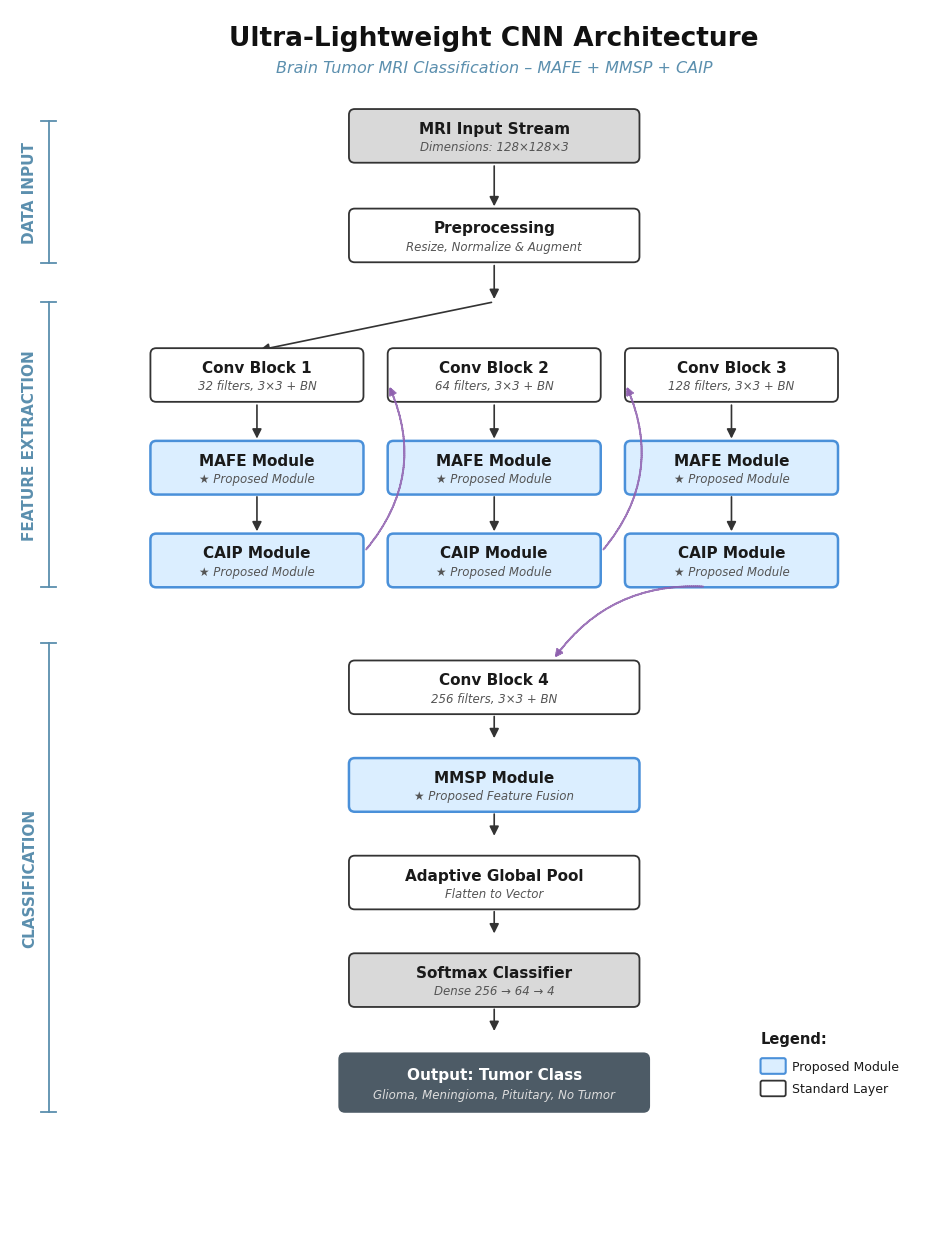

In [1]:
"""
رسم مخطط بنية شبكة CNN خفيفة الوزن (Ultra-Lightweight CNN Architecture)
لتصنيف صور الرنين المغناطيسي لأورام الدماغ.

يحتاج: matplotlib
تثبيت: pip install matplotlib --break-system-packages
"""

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch

# ------------------------------------------------------------------
# إعدادات عامة
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9.5, 12.5))
ax.set_xlim(0, 950)
ax.set_ylim(0, 1250)
ax.axis("off")
ax.invert_yaxis()  # نجعل الأعلى y=0 لسهولة الرسم من الأعلى للأسفل

# ألوان
GRAY_FILL = "#d9d9d9"
WHITE_FILL = "#ffffff"
BLUE_FILL = "#dbeeff"
BLUE_EDGE = "#4a90d9"
DARK_FILL = "#4d5b66"
BLACK_EDGE = "#333333"
TEXT_DARK = "#1a1a1a"
SUBTEXT = "#555555"
SECTION_COLOR = "#5b8fae"
CURVE_COLOR = "#8e5fae"  # بنفسجي هادئ ومتناسق للأسهم التسلسلية بين الفروع


def draw_box(x, y, w, h, title, subtitle,
             face=WHITE_FILL, edge=BLACK_EDGE, lw=1.3,
             title_color=TEXT_DARK, sub_color=SUBTEXT,
             star=False, title_size=11, sub_size=8.5):
    """يرسم صندوقًا مستطيلًا بحواف مدورة مع عنوان وعنوان فرعي."""
    box = patches.FancyBboxPatch(
        (x - w / 2, y - h / 2), w, h,
        boxstyle="round,pad=0,rounding_size=6",
        linewidth=lw, edgecolor=edge, facecolor=face,
        mutation_aspect=1
    )
    ax.add_patch(box)

    prefix = "★ " if star else ""
    ax.text(x, y - h * 0.14, title, ha="center", va="center",
            fontsize=title_size, fontweight="bold", color=title_color)
    ax.text(x, y + h * 0.20, prefix + subtitle, ha="center", va="center",
            fontsize=sub_size, style="italic", color=sub_color)


def draw_arrow(x1, y1, x2, y2, color="#333333"):
    """يرسم سهمًا من نقطة إلى أخرى."""
    arrow = FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle="-|>", mutation_scale=14,
        linewidth=1.2, color=color, shrinkA=2, shrinkB=2
    )
    ax.add_patch(arrow)


def draw_curved_arrow(x1, y1, x2, y2, rad=0.35, color=CURVE_COLOR):
    """يرسم سهمًا مقوسًا (منحني) بأسلوب ناعم ومتسق مع باقي التصميم."""
    arrow = FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle="-|>", mutation_scale=11,
        linewidth=1.4, color=color, shrinkA=3, shrinkB=3,
        linestyle=(0, (1, 0)),
        connectionstyle=f"arc3,rad={rad}",
        capstyle="round", joinstyle="round",
        alpha=0.85, zorder=1
    )
    ax.add_patch(arrow)


def section_bracket(y_top, y_bottom, label):
    """يرسم خطًا رأسيًا جانبيًا مع تسمية القسم (يسار المخطط)."""
    x = 40
    ax.plot([x, x], [y_top, y_bottom], color=SECTION_COLOR, linewidth=1.3)
    ax.plot([x - 8, x + 8], [y_top, y_top], color=SECTION_COLOR, linewidth=1.3)
    ax.plot([x - 8, x + 8], [y_bottom, y_bottom], color=SECTION_COLOR, linewidth=1.3)
    ax.text(x - 20, (y_top + y_bottom) / 2, label, rotation=90,
            ha="center", va="center", fontsize=11, fontweight="bold",
            color=SECTION_COLOR)


# ------------------------------------------------------------------
# العناوين الرئيسية
# ------------------------------------------------------------------
ax.text(500, 30, "Ultra-Lightweight CNN Architecture",
        ha="center", va="center", fontsize=19, fontweight="bold", color="#111111")
ax.text(500, 60, "Brain Tumor MRI Classification \u2013 MAFE + MMSP + CAIP",
        ha="center", va="center", fontsize=11.5, style="italic", color=SECTION_COLOR)

# ------------------------------------------------------------------
# طبقة الإدخال
# ------------------------------------------------------------------
draw_box(500, 130, 300, 55, "MRI Input Stream", "Dimensions: 128\u00d7128\u00d73", face=GRAY_FILL)
draw_arrow(500, 158, 500, 205)

draw_box(500, 232, 300, 55, "Preprocessing", "Resize, Normalize & Augment")
draw_arrow(500, 260, 500, 300)

section_bracket(115, 260, "DATA INPUT")

# ------------------------------------------------------------------
# الأفرع الثلاثة (Conv Block 1/2/3)
# ------------------------------------------------------------------
branch_x = [255, 500, 745]
branch_titles = ["Conv Block 1", "Conv Block 2", "Conv Block 3"]
branch_subs = ["32 filters, 3\u00d73 + BN", "64 filters, 3\u00d73 + BN", "128 filters, 3\u00d73 + BN"]

# سهم من Preprocessing إلى بداية Conv Block 1 فقط (التسلسل أصبح متتاليًا بين الأفرع)
draw_arrow(500, 300, branch_x[0], 350)

y_conv = 375
box_w_conv = 220
for bx, t, s in zip(branch_x, branch_titles, branch_subs):
    draw_box(bx, y_conv, box_w_conv, 55, t, s)

# سهم إلى MAFE
draw_arrow_y1 = y_conv + 28
y_mafe = 470
for bx in branch_x:
    draw_arrow(bx, draw_arrow_y1, bx, y_mafe - 27)
    draw_box(bx, y_mafe, 220, 55, "MAFE Module", "Proposed Module",
             face=BLUE_FILL, edge=BLUE_EDGE, lw=1.8, star=True)

# سهم إلى CAIP
y_pool = 565
for bx in branch_x:
    draw_arrow(bx, y_mafe + 27, bx, y_pool - 27)
    draw_box(bx, y_pool, 220, 55, "CAIP Module", "Proposed Module",
             face=BLUE_FILL, edge=BLUE_EDGE, lw=1.8, star=True)

# ------------------------------------------------------------------
# أسهم مقوسة تربط نهاية كل فرع (بعد CAIP Module) ببداية الفرع التالي:
# نهاية الفرع 1 (CAIP1) -> بداية Conv Block 2
# نهاية الفرع 2 (CAIP2) -> بداية Conv Block 3
# ترتبط من الحافة اليمنى لصندوق CAIP إلى الحافة اليسرى لصندوق Conv التالي
# ------------------------------------------------------------------
caip_right_y = y_pool - 8
conv_left_y = y_conv + 8
draw_curved_arrow(branch_x[0] + box_w_conv / 2, caip_right_y,
                   branch_x[1] - box_w_conv / 2, conv_left_y, rad=0.32)
draw_curved_arrow(branch_x[1] + box_w_conv / 2, caip_right_y,
                   branch_x[2] - box_w_conv / 2, conv_left_y, rad=0.32)

section_bracket(300, 592, "FEATURE EXTRACTION")

# ------------------------------------------------------------------
# Conv Block 4 (يستقبل فقط من نهاية الفرع 3 عبر السهم المقوس أدناه)
# ------------------------------------------------------------------
y_conv4 = 695
draw_box(500, y_conv4, 300, 55, "Conv Block 4", "256 filters, 3\u00d73 + BN")
draw_arrow(500, y_conv4 + 27, 500, 750)

# ------------------------------------------------------------------
# سهم مقوس يربط نهاية الفرع 3 (بعد CAIP3) ببداية Conv Block 4
# ينحدر بشكل ناعم من الحافة السفلية لـ CAIP3 إلى الحافة العلوية لـ Conv Block4
# ------------------------------------------------------------------
draw_curved_arrow(branch_x[2] - 25, y_pool + 27,
                   500 + 60, y_conv4 - 27, rad=0.28)

# ------------------------------------------------------------------
# Multi-Scale Processor
# ------------------------------------------------------------------
y_msp = 795
draw_box(500, y_msp, 300, 55, "MMSP Module", "Proposed Feature Fusion",
         face=BLUE_FILL, edge=BLUE_EDGE, lw=1.8, star=True)
draw_arrow(500, y_msp + 27, 500, 850)

# ------------------------------------------------------------------
# Adaptive Global Pool
# ------------------------------------------------------------------
y_pool2 = 895
draw_box(500, y_pool2, 300, 55, "Adaptive Global Pool", "Flatten to Vector")
draw_arrow(500, y_pool2 + 27, 500, 950)

# ------------------------------------------------------------------
# Softmax Classifier
# ------------------------------------------------------------------
y_softmax = 995
draw_box(500, y_softmax, 300, 55, "Softmax Classifier", "Dense 256 \u2192 64 \u2192 4",
         face=GRAY_FILL)
draw_arrow(500, y_softmax + 27, 500, 1050)

# ------------------------------------------------------------------
# مخرج التصنيف النهائي
# ------------------------------------------------------------------
y_out = 1100
draw_box(500, y_out, 320, 60, "Output: Tumor Class", "Glioma, Meningioma, Pituitary, No Tumor",
         face=DARK_FILL, edge=DARK_FILL, title_color="white", sub_color="#dddddd")

section_bracket(650, 1130, "CLASSIFICATION")

# ------------------------------------------------------------------
# مفتاح الرموز (Legend)
# ------------------------------------------------------------------
legend_x, legend_y = 790, 1090
ax.text(legend_x - 15, legend_y - 35, "Legend:", ha="left", va="center",
        fontsize=10.5, fontweight="bold", color=TEXT_DARK)

legend_box1 = patches.FancyBboxPatch(
    (legend_x - 15, legend_y - 15), 26, 16,
    boxstyle="round,pad=0,rounding_size=2",
    linewidth=1.5, edgecolor=BLUE_EDGE, facecolor=BLUE_FILL)
ax.add_patch(legend_box1)
ax.text(legend_x + 18, legend_y - 7, "Proposed Module", ha="left", va="center",
        fontsize=9, color=TEXT_DARK)

legend_box2 = patches.FancyBboxPatch(
    (legend_x - 15, legend_y + 8), 26, 16,
    boxstyle="round,pad=0,rounding_size=2",
    linewidth=1.3, edgecolor=BLACK_EDGE, facecolor=WHITE_FILL)
ax.add_patch(legend_box2)
ax.text(legend_x + 18, legend_y + 16, "Standard Layer", ha="left", va="center",
        fontsize=9, color=TEXT_DARK)

# ------------------------------------------------------------------
# حفظ الصورة
# ------------------------------------------------------------------
plt.tight_layout()
plt.savefig("cnn_architecture2.png", dpi=200, bbox_inches="tight",
            facecolor="white")
print("تم الحفظ بنجاح")

In [ ]:
# كود الاختبار على بيانات التدريب

Using device: cpu
BRAIN TUMOR MODEL TESTING & VISUALIZATION
📁 Results will be saved to: D:\Master\Brain Tumor MRI\evaluation_results

📥 Loading model from: best_brain_tumor_model_patent.pth
✅ Model loaded successfully from best_brain_tumor_model_patent.pth
📋 Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

📂 Loading test data from: Brain Tumor MRI Dataset Big
📁 Found 9650 images
📊 Class Distribution:
  glioma: 3018 images
  meningioma: 2183 images
  notumor: 1945 images
  pituitary: 2504 images

🔄 Evaluating model...

✅ EVALUATION RESULTS
Overall Accuracy: 0.9976 (99.76%)
Total Samples: 9650

📊 Generating and saving visualizations...



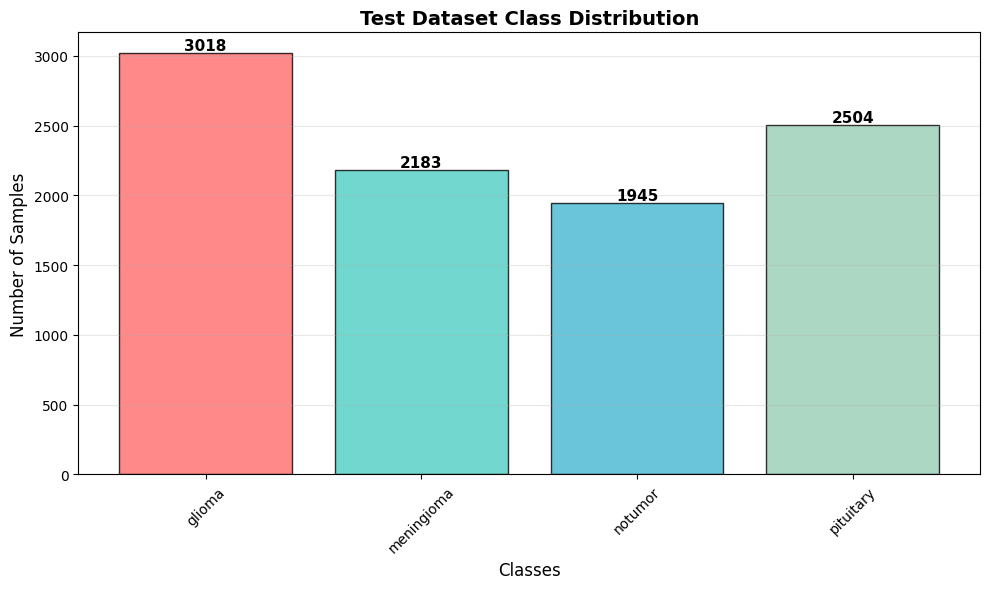

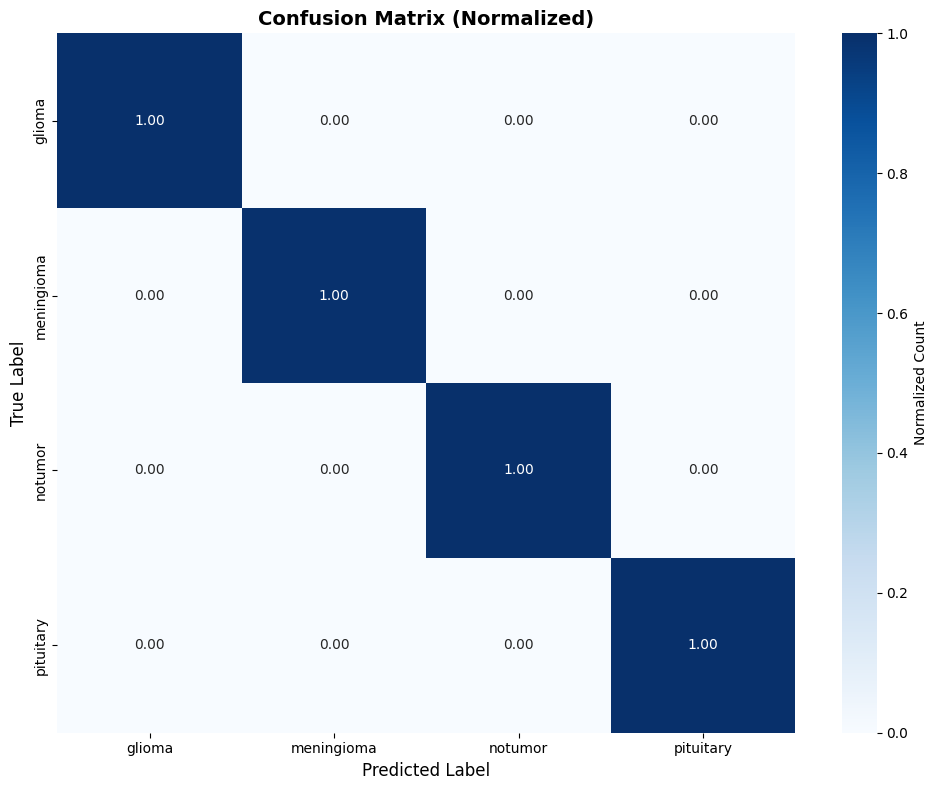

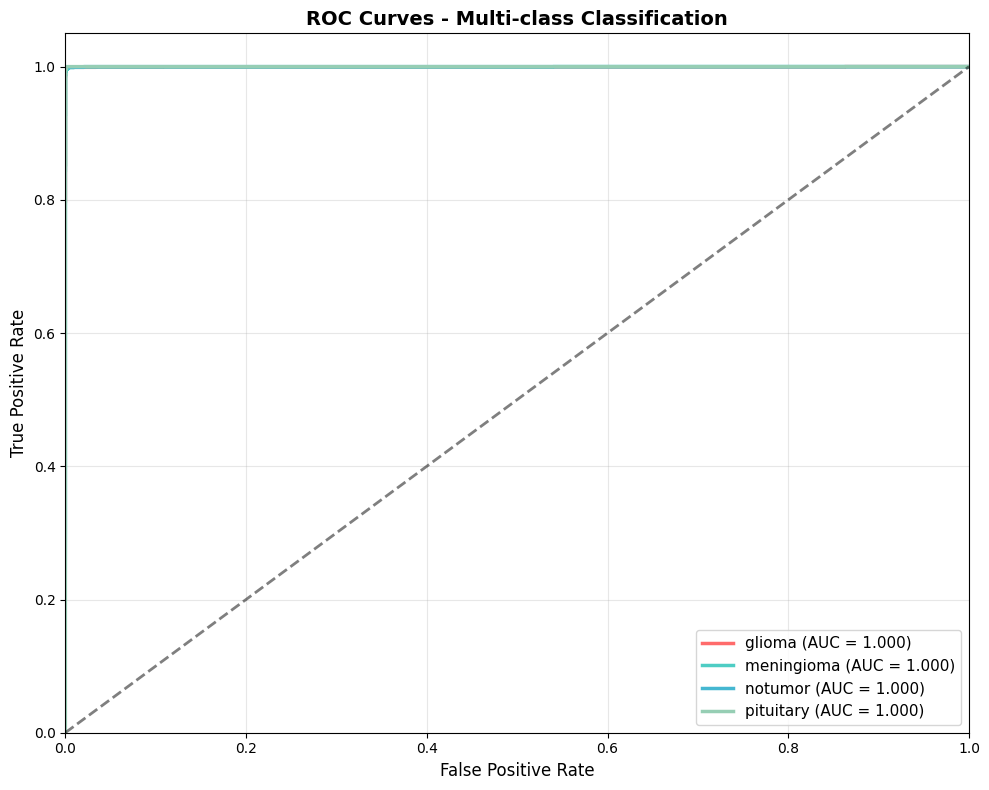

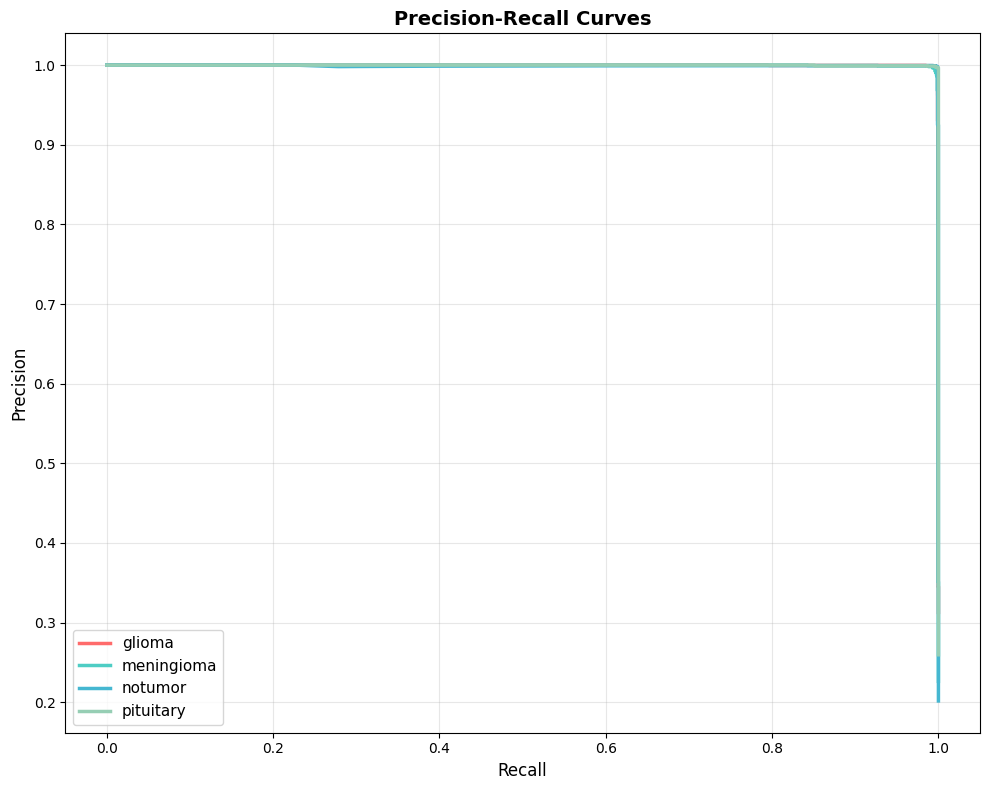

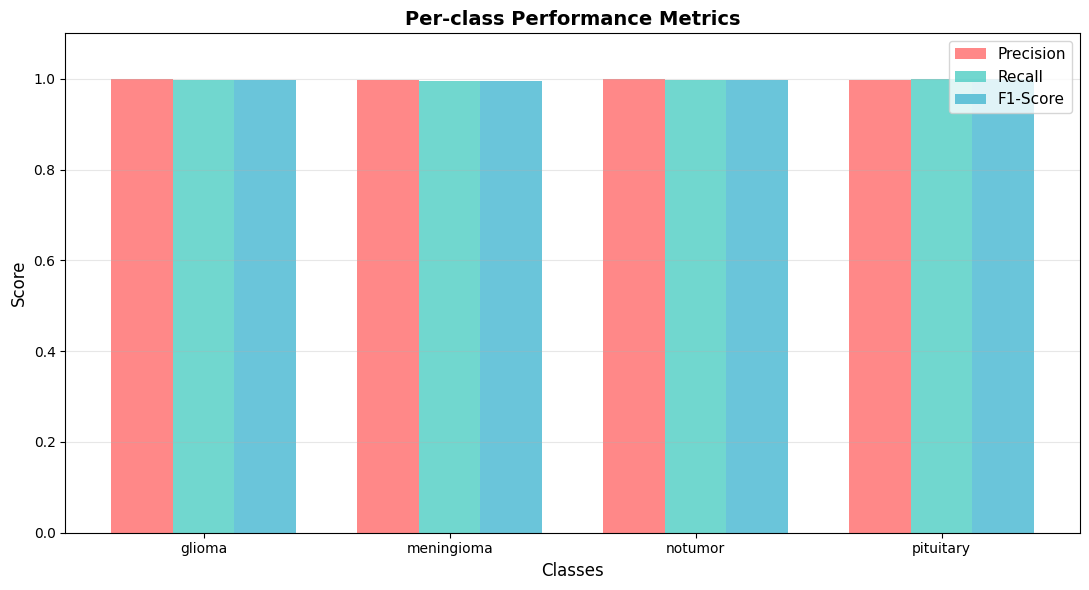

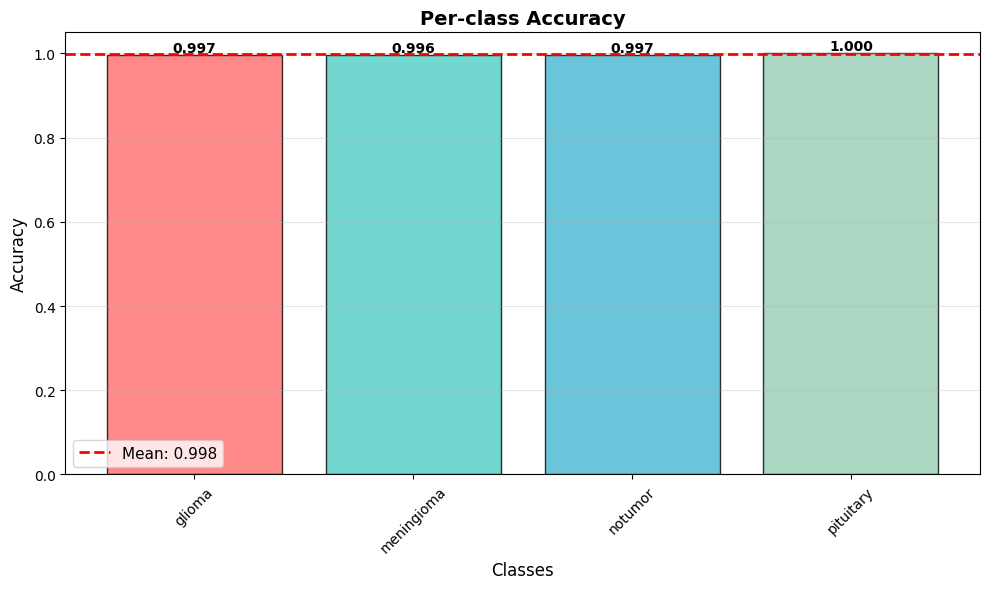


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      glioma      0.998     0.997     0.998      3018
  meningioma      0.996     0.996     0.996      2183
     notumor      0.999     0.997     0.998      1945
   pituitary      0.997     1.000     0.998      2504

    accuracy                          0.998      9650
   macro avg      0.998     0.998     0.998      9650
weighted avg      0.998     0.998     0.998      9650


✅ All visualizations saved to: D:\Master\Brain Tumor MRI\evaluation_results
🎉 Testing and visualization finished successfully!


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# إعدادات العرض
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

# مجلد حفظ الصور
SAVE_DIR = Path("evaluation_results")
SAVE_DIR.mkdir(exist_ok=True)

# إعداد الجهاز
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================
# دالة مساعدة للحفظ والعرض
# ============================
def save_and_show(filename):
    filepath = SAVE_DIR / filename
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()  # ← هذا يعرضها مباشرة في output (Jupyter/Colab)
    plt.close()

# ============================
# فئة مجموعة البيانات
# ============================
class BrainTumorMRIDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = Path(data_dir)
        self.transform = transform
        
        self.class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
        self.class_to_idx = {name: idx for idx, name in enumerate(self.class_names)}
        
        self.samples = []
        self._scan_directory()
        
        print(f"📁 Found {len(self.samples)} images")
        self._print_class_distribution()
    
    def _scan_directory(self):
        training_folder = self.data_dir / "Training"
        if training_folder.exists():
            for class_name in self.class_names:
                class_folder = training_folder / class_name
                if class_folder.exists():
                    label = self.class_to_idx[class_name]
                    for img_path in class_folder.glob('*'):
                        if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                            self.samples.append((str(img_path), label))
    
    def _print_class_distribution(self):
        class_counts = [0] * len(self.class_names)
        for _, label in self.samples:
            class_counts[label] += 1
        
        print("📊 Class Distribution:")
        for class_name, count in zip(self.class_names, class_counts):
            print(f"  {class_name}: {count} images")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label
        except:
            black_img = Image.new('RGB', (128, 128), (0, 0, 0))
            if self.transform:
                return self.transform(black_img), label
            return torch.zeros(3, 128, 128), label

# ============================
# مكونات براءة الاختراع
# ============================
class MicroAdaptiveFeatureExtractor(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        reduced_ch = max(1, channels // reduction)
        
        self.spatial_conv = nn.Conv2d(channels, 1, 1)
        self.channel_avg = nn.AdaptiveAvgPool2d(1)
        self.channel_fc = nn.Conv2d(channels, reduced_ch, 1)
        self.channel_out = nn.Conv2d(reduced_ch, channels, 1)
        self.alpha = nn.Parameter(torch.tensor(0.3), requires_grad=True)
    
    def forward(self, x):
        spatial_weights = torch.sigmoid(self.spatial_conv(x))
        x_spatial = x * spatial_weights
        channel_pool = self.channel_avg(x_spatial)
        channel_weights = torch.sigmoid(self.channel_out(F.relu(self.channel_fc(channel_pool))))
        x_enhanced = x_spatial * channel_weights
        return x + self.alpha * x_enhanced

class MicroMultiScaleProcessor(nn.Module):
    def __init__(self, channels):
        super().__init__()
        inter = max(8, channels // 4)
        while inter % 4 != 0 and inter > 4:
            inter -= 1
        if inter < 4:
            inter = 4
        
        self.scale1 = nn.Conv2d(channels, inter, 1, bias=False)
        self.scale3 = nn.Conv2d(channels, inter, 3, padding=1, bias=False)
        
        if channels >= 8 and inter >= 4:
            groups = 1
            for g in [8, 4, 2]:
                if channels % g == 0:
                    groups = g
                    break
            self.scale3dw = nn.Conv2d(channels, inter, 3, padding=1, groups=groups, bias=False)
        else:
            self.scale3dw = nn.Conv2d(channels, inter, 3, padding=1, bias=False)
        
        self.fusion = nn.Conv2d(inter * 3, channels, 1, bias=False)
        self.beta = nn.Parameter(torch.tensor(0.3), requires_grad=True)
    
    def forward(self, x):
        s1 = F.relu(self.scale1(x))
        s3 = F.relu(self.scale3(x))
        s3dw = F.relu(self.scale3dw(x))
        combined = torch.cat([s1, s3, s3dw], dim=1)
        fused = self.fusion(combined)
        return F.relu(x + self.beta * fused)

class MicroIntelligentPooling(nn.Module):
    def __init__(self, channels):
        super().__init__()
        decision_ch = max(2, channels // 8)
        
        self.decision = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, decision_ch, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(decision_ch, 2, 1),
            nn.Softmax(dim=1)
        )
    
    def forward(self, x):
        B, C, H, W = x.shape
        decision_weights = self.decision(x)
        
        max_pool = F.max_pool2d(x, kernel_size=2, stride=2)
        avg_pool = F.avg_pool2d(x, kernel_size=2, stride=2)
        
        w1 = decision_weights[:, 0:1, :, :].view(B, 1, 1, 1)
        w2 = decision_weights[:, 1:2, :, :].view(B, 1, 1, 1)
        
        return w1 * max_pool + w2 * avg_pool

# ============================
# النموذج الرئيسي
# ============================
class UltraLightPatentBrainTumorCNN(nn.Module):
    def __init__(self, num_classes=4, base_channels=[32, 64, 128, 256]):
        super().__init__()
        c1, c2, c3, c4 = base_channels
        
        self.conv1 = nn.Conv2d(3, c1, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(c1)
        self.adaptive1 = MicroAdaptiveFeatureExtractor(c1, reduction=4)
        self.pool1 = MicroIntelligentPooling(c1)
        
        self.conv2 = nn.Conv2d(c1, c2, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(c2)
        self.multiscale2 = MicroMultiScaleProcessor(c2)
        self.pool2 = MicroIntelligentPooling(c2)
        
        self.conv3 = nn.Conv2d(c2, c3, 3, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(c3)
        self.adaptive3 = MicroAdaptiveFeatureExtractor(c3, reduction=8)
        self.pool3 = MicroIntelligentPooling(c3)
        
        self.conv4 = nn.Conv2d(c3, c4, 3, padding=1, bias=False)
        self.bn4 = nn.BatchNorm2d(c4)
        self.multiscale4 = MicroMultiScaleProcessor(c4)
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(c4, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.)
    
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.adaptive1(x)
        x = self.pool1(x)
        
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.multiscale2(x)
        x = self.pool2(x)
        
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.adaptive3(x)
        x = self.pool3(x)
        
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.multiscale4(x)
        
        return self.classifier(x)

# ============================
# دوال التقييم
# ============================
def load_model(model_path, device):
    model = UltraLightPatentBrainTumorCNN(num_classes=4).to(device)
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print(f"✅ Model loaded successfully from {model_path}")
    return model, checkpoint

def evaluate_model(model, dataloader, device, class_names):
    all_preds = []
    all_targets = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            
            all_probs.extend(probs.cpu().numpy())
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())
    
    return np.array(all_targets), np.array(all_preds), np.array(all_probs)

def create_test_transforms(image_size=128):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

# ============================
# دوال التصور والمخططات
# ============================
def plot_confusion_matrix(targets, preds, class_names):
    cm = confusion_matrix(targets, preds)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Normalized Count'})
    plt.title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    save_and_show("01_confusion_matrix.png")  # ← حفظ وعرض

def plot_roc_curves(targets, probs, class_names):
    plt.figure(figsize=(10, 8))
    
    targets_bin = label_binarize(targets, classes=range(len(class_names)))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    
    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(targets_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], lw=2.5,
                 label=f'{class_names[i]} (AUC = {roc_auc:.3f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves - Multi-class Classification', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_and_show("02_roc_curves.png")  # ← حفظ وعرض

def plot_precision_recall_curves(targets, probs, class_names):
    plt.figure(figsize=(10, 8))
    
    targets_bin = label_binarize(targets, classes=range(len(class_names)))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    
    for i in range(len(class_names)):
        precision, recall, _ = precision_recall_curve(targets_bin[:, i], probs[:, i])
        plt.plot(recall, precision, color=colors[i], lw=2.5, label=f'{class_names[i]}')
    
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Precision-Recall Curves', fontsize=14, fontweight='bold')
    plt.legend(loc="lower left", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_and_show("03_precision_recall_curves.png")  # ← حفظ وعرض

def plot_per_class_metrics(targets, preds, class_names):
    precision = precision_score(targets, preds, average=None)
    recall = recall_score(targets, preds, average=None)
    f1 = f1_score(targets, preds, average=None)
    
    x = np.arange(len(class_names))
    width = 0.25
    
    plt.figure(figsize=(11, 6))
    plt.bar(x - width, precision, width, label='Precision', color='#FF6B6B', alpha=0.8)
    plt.bar(x, recall, width, label='Recall', color='#4ECDC4', alpha=0.8)
    plt.bar(x + width, f1, width, label='F1-Score', color='#45B7D1', alpha=0.8)
    
    plt.ylabel('Score', fontsize=12)
    plt.xlabel('Classes', fontsize=12)
    plt.title('Per-class Performance Metrics', fontsize=14, fontweight='bold')
    plt.xticks(x, class_names)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3, axis='y')
    plt.ylim([0, 1.1])
    plt.tight_layout()
    save_and_show("04_per_class_metrics.png")  # ← حفظ وعرض

def plot_class_distribution(targets, class_names):
    class_counts = [np.sum(targets == i) for i in range(len(class_names))]
    
    plt.figure(figsize=(10, 6))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    bars = plt.bar(class_names, class_counts, color=colors, alpha=0.8, edgecolor='black')
    
    plt.title('Test Dataset Class Distribution', fontsize=14, fontweight='bold')
    plt.ylabel('Number of Samples', fontsize=12)
    plt.xlabel('Classes', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, axis='y')
    
    for bar, count in zip(bars, class_counts):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{count}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    save_and_show("05_class_distribution.png")  # ← حفظ وعرض

def plot_accuracy_breakdown(targets, preds, class_names):
    accuracies = []
    
    for i in range(len(class_names)):
        class_mask = targets == i
        if class_mask.sum() > 0:
            class_acc = accuracy_score(targets[class_mask], preds[class_mask])
        else:
            class_acc = 0
        accuracies.append(class_acc)
    
    plt.figure(figsize=(10, 6))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    bars = plt.bar(class_names, accuracies, color=colors, alpha=0.8, edgecolor='black')
    
    plt.title('Per-class Accuracy', fontsize=14, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=12)
    plt.xlabel('Classes', fontsize=12)
    plt.ylim([0, 1.05])
    plt.axhline(y=np.mean(accuracies), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {np.mean(accuracies):.3f}')
    plt.grid(True, alpha=0.3, axis='y')
    plt.xticks(rotation=45)
    plt.legend(fontsize=11)
    
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{acc:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    save_and_show("06_accuracy_breakdown.png")  # ← حفظ وعرض

def plot_classification_report(targets, preds, class_names):
    print("\n" + "="*60)
    print("CLASSIFICATION REPORT")
    print("="*60)
    print(classification_report(targets, preds, target_names=class_names, digits=3))
    print("="*60)

# ============================
# البرنامج الرئيسي
# ============================
def main():
    print("="*60)
    print("BRAIN TUMOR MODEL TESTING & VISUALIZATION")
    print("="*60)
    print(f"📁 Results will be saved to: {SAVE_DIR.resolve()}")
    
    MODEL_PATH = "best_brain_tumor_model_patent.pth"
    DATA_DIR = "Brain Tumor MRI Dataset Big"
    
    if not Path(MODEL_PATH).exists():
        print(f"❌ Model file not found: {MODEL_PATH}")
        return
    
    print(f"\n📥 Loading model from: {MODEL_PATH}")
    model, checkpoint = load_model(MODEL_PATH, device)
    
    class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
    print(f"📋 Classes: {class_names}")
    
    print(f"\n📂 Loading test data from: {DATA_DIR}")
    test_transform = create_test_transforms(128)
    test_dataset = BrainTumorMRIDataset(DATA_DIR, transform=test_transform)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)
    
    print(f"\n🔄 Evaluating model...")
    targets, preds, probs = evaluate_model(model, test_loader, device, class_names)
    
    accuracy = accuracy_score(targets, preds)
    
    print(f"\n" + "="*60)
    print(f"✅ EVALUATION RESULTS")
    print(f"="*60)
    print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Total Samples: {len(targets)}")
    print(f"="*60)
    
    print(f"\n📊 Generating and saving visualizations...\n")
    
    plot_class_distribution(targets, class_names)
    plot_confusion_matrix(targets, preds, class_names)
    plot_roc_curves(targets, probs, class_names)
    plot_precision_recall_curves(targets, probs, class_names)
    plot_per_class_metrics(targets, preds, class_names)
    plot_accuracy_breakdown(targets, preds, class_names)
    plot_classification_report(targets, preds, class_names)
    
    print(f"\n✅ All visualizations saved to: {SAVE_DIR.resolve()}")
    print(f"🎉 Testing and visualization finished successfully!")

if __name__ == "__main__":
    main()

In [ ]:
# كود الاختبار على بيانات الاختبار

Using device: cpu
BRAIN TUMOR MODEL TESTING & VISUALIZATION
📁 Results will be saved to: D:\Master\Brain Tumor MRI\evaluation_results

📥 Loading model from: best_brain_tumor_model_patent.pth
✅ Model loaded successfully from best_brain_tumor_model_patent.pth
📋 Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

📂 Loading test data from: Brain Tumor MRI Dataset Big
📁 Found 2414 images
📊 Class Distribution:
  glioma: 755 images
  meningioma: 546 images
  notumor: 487 images
  pituitary: 626 images

🔄 Evaluating model...

✅ EVALUATION RESULTS
Overall Accuracy: 0.9735 (97.35%)
Total Samples: 2414

📊 Generating and saving visualizations...



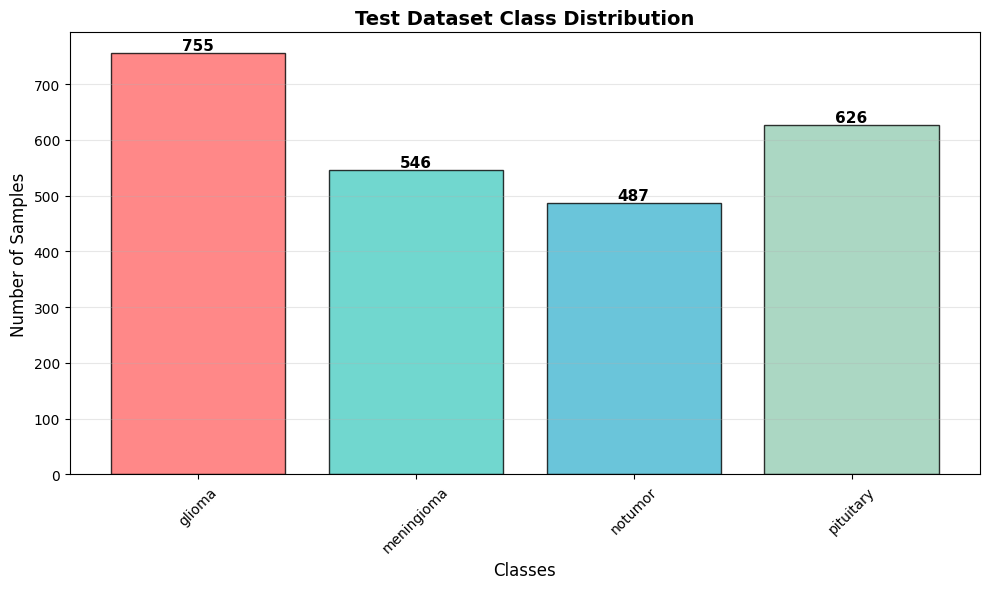

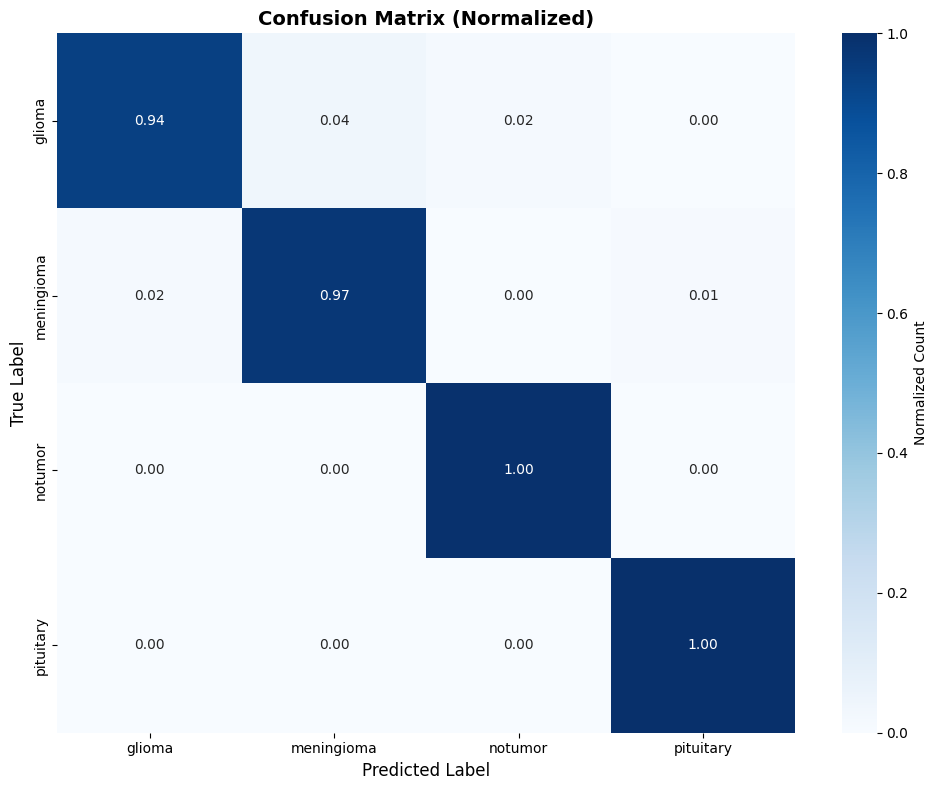

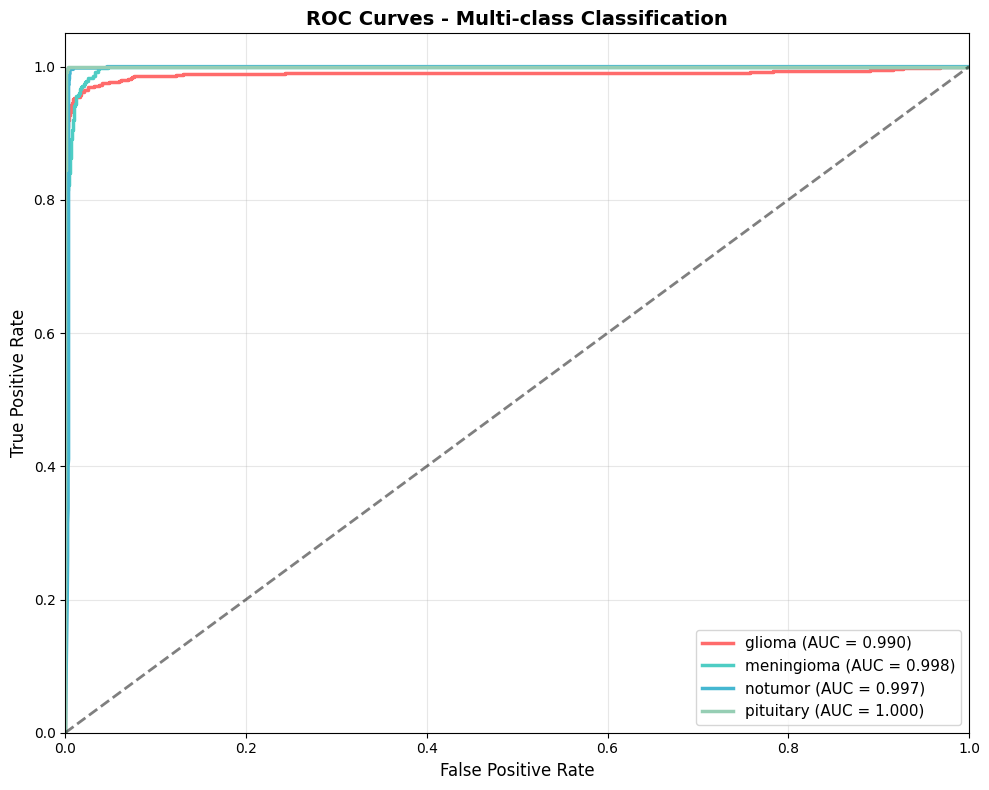

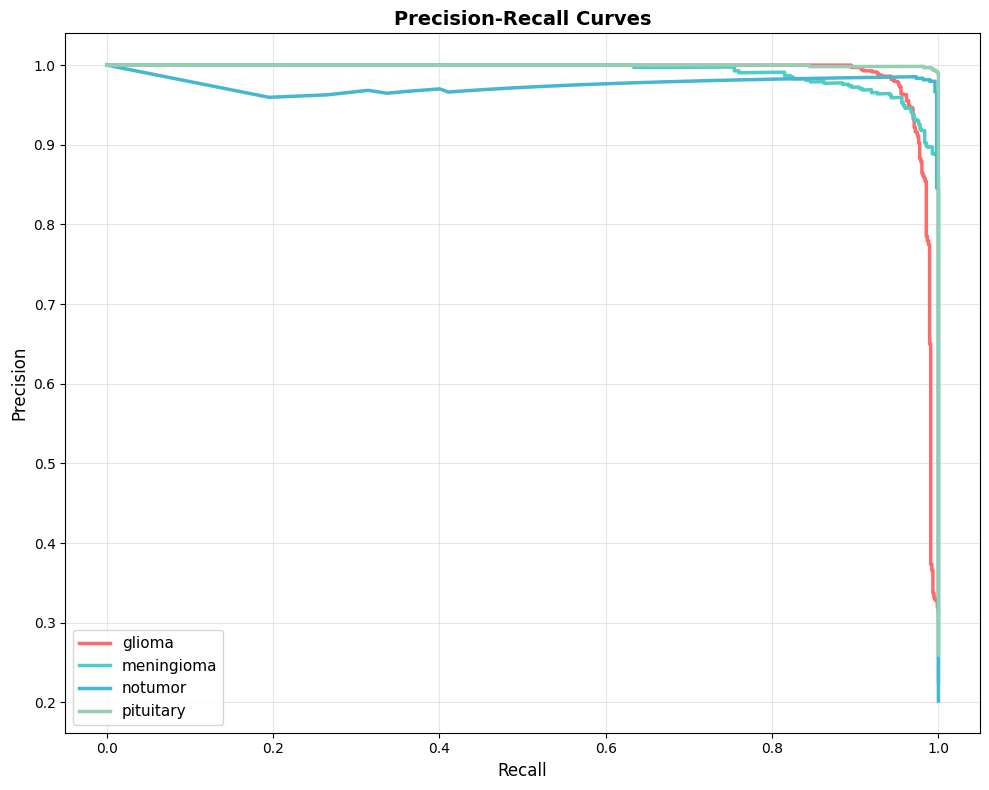

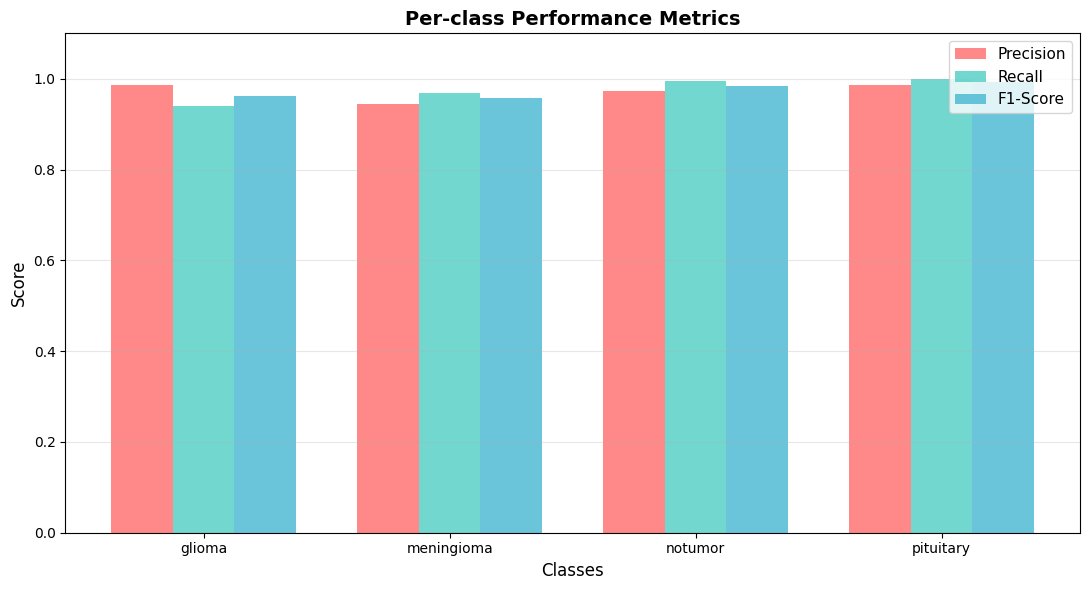

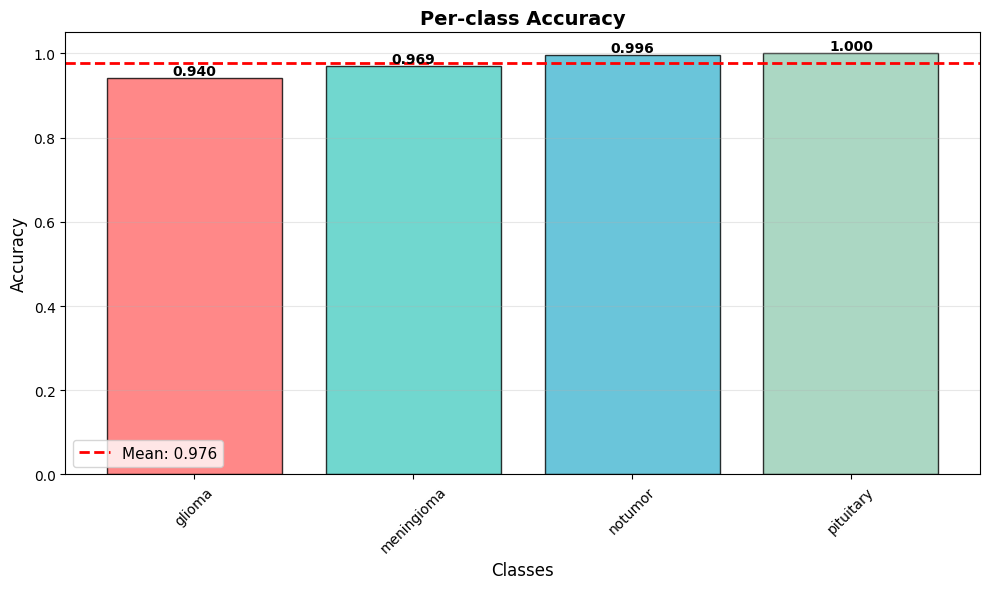


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      glioma      0.986     0.940     0.963       755
  meningioma      0.945     0.969     0.957       546
     notumor      0.972     0.996     0.984       487
   pituitary      0.986     1.000     0.993       626

    accuracy                          0.973      2414
   macro avg      0.972     0.976     0.974      2414
weighted avg      0.974     0.973     0.973      2414


✅ All visualizations saved to: D:\Master\Brain Tumor MRI\evaluation_results
🎉 Testing and visualization finished successfully!


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# إعدادات العرض
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

# مجلد حفظ الصور
SAVE_DIR = Path("evaluation_results")
SAVE_DIR.mkdir(exist_ok=True)

# إعداد الجهاز
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================
# دالة مساعدة للحفظ والعرض
# ============================
def save_and_show(filename):
    filepath = SAVE_DIR / filename
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()  # ← هذا يعرضها مباشرة في output (Jupyter/Colab)
    plt.close()

# ============================
# فئة مجموعة البيانات
# ============================
class BrainTumorMRIDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = Path(data_dir)
        self.transform = transform
        
        self.class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
        self.class_to_idx = {name: idx for idx, name in enumerate(self.class_names)}
        
        self.samples = []
        self._scan_directory()
        
        print(f"📁 Found {len(self.samples)} images")
        self._print_class_distribution()
    
    def _scan_directory(self):
        training_folder = self.data_dir / "Testing"
        if training_folder.exists():
            for class_name in self.class_names:
                class_folder = training_folder / class_name
                if class_folder.exists():
                    label = self.class_to_idx[class_name]
                    for img_path in class_folder.glob('*'):
                        if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                            self.samples.append((str(img_path), label))
    
    def _print_class_distribution(self):
        class_counts = [0] * len(self.class_names)
        for _, label in self.samples:
            class_counts[label] += 1
        
        print("📊 Class Distribution:")
        for class_name, count in zip(self.class_names, class_counts):
            print(f"  {class_name}: {count} images")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label
        except:
            black_img = Image.new('RGB', (128, 128), (0, 0, 0))
            if self.transform:
                return self.transform(black_img), label
            return torch.zeros(3, 128, 128), label

# ============================
# مكونات براءة الاختراع
# ============================
class MicroAdaptiveFeatureExtractor(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        reduced_ch = max(1, channels // reduction)
        
        self.spatial_conv = nn.Conv2d(channels, 1, 1)
        self.channel_avg = nn.AdaptiveAvgPool2d(1)
        self.channel_fc = nn.Conv2d(channels, reduced_ch, 1)
        self.channel_out = nn.Conv2d(reduced_ch, channels, 1)
        self.alpha = nn.Parameter(torch.tensor(0.3), requires_grad=True)
    
    def forward(self, x):
        spatial_weights = torch.sigmoid(self.spatial_conv(x))
        x_spatial = x * spatial_weights
        channel_pool = self.channel_avg(x_spatial)
        channel_weights = torch.sigmoid(self.channel_out(F.relu(self.channel_fc(channel_pool))))
        x_enhanced = x_spatial * channel_weights
        return x + self.alpha * x_enhanced

class MicroMultiScaleProcessor(nn.Module):
    def __init__(self, channels):
        super().__init__()
        inter = max(8, channels // 4)
        while inter % 4 != 0 and inter > 4:
            inter -= 1
        if inter < 4:
            inter = 4
        
        self.scale1 = nn.Conv2d(channels, inter, 1, bias=False)
        self.scale3 = nn.Conv2d(channels, inter, 3, padding=1, bias=False)
        
        if channels >= 8 and inter >= 4:
            groups = 1
            for g in [8, 4, 2]:
                if channels % g == 0:
                    groups = g
                    break
            self.scale3dw = nn.Conv2d(channels, inter, 3, padding=1, groups=groups, bias=False)
        else:
            self.scale3dw = nn.Conv2d(channels, inter, 3, padding=1, bias=False)
        
        self.fusion = nn.Conv2d(inter * 3, channels, 1, bias=False)
        self.beta = nn.Parameter(torch.tensor(0.3), requires_grad=True)
    
    def forward(self, x):
        s1 = F.relu(self.scale1(x))
        s3 = F.relu(self.scale3(x))
        s3dw = F.relu(self.scale3dw(x))
        combined = torch.cat([s1, s3, s3dw], dim=1)
        fused = self.fusion(combined)
        return F.relu(x + self.beta * fused)

class MicroIntelligentPooling(nn.Module):
    def __init__(self, channels):
        super().__init__()
        decision_ch = max(2, channels // 8)
        
        self.decision = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, decision_ch, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(decision_ch, 2, 1),
            nn.Softmax(dim=1)
        )
    
    def forward(self, x):
        B, C, H, W = x.shape
        decision_weights = self.decision(x)
        
        max_pool = F.max_pool2d(x, kernel_size=2, stride=2)
        avg_pool = F.avg_pool2d(x, kernel_size=2, stride=2)
        
        w1 = decision_weights[:, 0:1, :, :].view(B, 1, 1, 1)
        w2 = decision_weights[:, 1:2, :, :].view(B, 1, 1, 1)
        
        return w1 * max_pool + w2 * avg_pool

# ============================
# النموذج الرئيسي
# ============================
class UltraLightPatentBrainTumorCNN(nn.Module):
    def __init__(self, num_classes=4, base_channels=[32, 64, 128, 256]):
        super().__init__()
        c1, c2, c3, c4 = base_channels
        
        self.conv1 = nn.Conv2d(3, c1, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(c1)
        self.adaptive1 = MicroAdaptiveFeatureExtractor(c1, reduction=4)
        self.pool1 = MicroIntelligentPooling(c1)
        
        self.conv2 = nn.Conv2d(c1, c2, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(c2)
        self.multiscale2 = MicroMultiScaleProcessor(c2)
        self.pool2 = MicroIntelligentPooling(c2)
        
        self.conv3 = nn.Conv2d(c2, c3, 3, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(c3)
        self.adaptive3 = MicroAdaptiveFeatureExtractor(c3, reduction=8)
        self.pool3 = MicroIntelligentPooling(c3)
        
        self.conv4 = nn.Conv2d(c3, c4, 3, padding=1, bias=False)
        self.bn4 = nn.BatchNorm2d(c4)
        self.multiscale4 = MicroMultiScaleProcessor(c4)
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(c4, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.)
    
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.adaptive1(x)
        x = self.pool1(x)
        
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.multiscale2(x)
        x = self.pool2(x)
        
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.adaptive3(x)
        x = self.pool3(x)
        
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.multiscale4(x)
        
        return self.classifier(x)

# ============================
# دوال التقييم
# ============================
def load_model(model_path, device):
    model = UltraLightPatentBrainTumorCNN(num_classes=4).to(device)
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print(f"✅ Model loaded successfully from {model_path}")
    return model, checkpoint

def evaluate_model(model, dataloader, device, class_names):
    all_preds = []
    all_targets = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            
            all_probs.extend(probs.cpu().numpy())
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())
    
    return np.array(all_targets), np.array(all_preds), np.array(all_probs)

def create_test_transforms(image_size=128):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

# ============================
# دوال التصور والمخططات
# ============================
def plot_confusion_matrix(targets, preds, class_names):
    cm = confusion_matrix(targets, preds)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Normalized Count'})
    plt.title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    save_and_show("01_confusion_matrix.png")  # ← حفظ وعرض

def plot_roc_curves(targets, probs, class_names):
    plt.figure(figsize=(10, 8))
    
    targets_bin = label_binarize(targets, classes=range(len(class_names)))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    
    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(targets_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], lw=2.5,
                 label=f'{class_names[i]} (AUC = {roc_auc:.3f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves - Multi-class Classification', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_and_show("02_roc_curves.png")  # ← حفظ وعرض

def plot_precision_recall_curves(targets, probs, class_names):
    plt.figure(figsize=(10, 8))
    
    targets_bin = label_binarize(targets, classes=range(len(class_names)))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    
    for i in range(len(class_names)):
        precision, recall, _ = precision_recall_curve(targets_bin[:, i], probs[:, i])
        plt.plot(recall, precision, color=colors[i], lw=2.5, label=f'{class_names[i]}')
    
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Precision-Recall Curves', fontsize=14, fontweight='bold')
    plt.legend(loc="lower left", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_and_show("03_precision_recall_curves.png")  # ← حفظ وعرض

def plot_per_class_metrics(targets, preds, class_names):
    precision = precision_score(targets, preds, average=None)
    recall = recall_score(targets, preds, average=None)
    f1 = f1_score(targets, preds, average=None)
    
    x = np.arange(len(class_names))
    width = 0.25
    
    plt.figure(figsize=(11, 6))
    plt.bar(x - width, precision, width, label='Precision', color='#FF6B6B', alpha=0.8)
    plt.bar(x, recall, width, label='Recall', color='#4ECDC4', alpha=0.8)
    plt.bar(x + width, f1, width, label='F1-Score', color='#45B7D1', alpha=0.8)
    
    plt.ylabel('Score', fontsize=12)
    plt.xlabel('Classes', fontsize=12)
    plt.title('Per-class Performance Metrics', fontsize=14, fontweight='bold')
    plt.xticks(x, class_names)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3, axis='y')
    plt.ylim([0, 1.1])
    plt.tight_layout()
    save_and_show("04_per_class_metrics.png")  # ← حفظ وعرض

def plot_class_distribution(targets, class_names):
    class_counts = [np.sum(targets == i) for i in range(len(class_names))]
    
    plt.figure(figsize=(10, 6))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    bars = plt.bar(class_names, class_counts, color=colors, alpha=0.8, edgecolor='black')
    
    plt.title('Test Dataset Class Distribution', fontsize=14, fontweight='bold')
    plt.ylabel('Number of Samples', fontsize=12)
    plt.xlabel('Classes', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, axis='y')
    
    for bar, count in zip(bars, class_counts):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{count}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    save_and_show("05_class_distribution.png")  # ← حفظ وعرض

def plot_accuracy_breakdown(targets, preds, class_names):
    accuracies = []
    
    for i in range(len(class_names)):
        class_mask = targets == i
        if class_mask.sum() > 0:
            class_acc = accuracy_score(targets[class_mask], preds[class_mask])
        else:
            class_acc = 0
        accuracies.append(class_acc)
    
    plt.figure(figsize=(10, 6))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    bars = plt.bar(class_names, accuracies, color=colors, alpha=0.8, edgecolor='black')
    
    plt.title('Per-class Accuracy', fontsize=14, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=12)
    plt.xlabel('Classes', fontsize=12)
    plt.ylim([0, 1.05])
    plt.axhline(y=np.mean(accuracies), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {np.mean(accuracies):.3f}')
    plt.grid(True, alpha=0.3, axis='y')
    plt.xticks(rotation=45)
    plt.legend(fontsize=11)
    
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{acc:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    save_and_show("06_accuracy_breakdown.png")  # ← حفظ وعرض

def plot_classification_report(targets, preds, class_names):
    print("\n" + "="*60)
    print("CLASSIFICATION REPORT")
    print("="*60)
    print(classification_report(targets, preds, target_names=class_names, digits=3))
    print("="*60)

# ============================
# البرنامج الرئيسي
# ============================
def main():
    print("="*60)
    print("BRAIN TUMOR MODEL TESTING & VISUALIZATION")
    print("="*60)
    print(f"📁 Results will be saved to: {SAVE_DIR.resolve()}")
    
    MODEL_PATH = "best_brain_tumor_model_patent.pth"
    DATA_DIR = "Brain Tumor MRI Dataset Big"
    
    if not Path(MODEL_PATH).exists():
        print(f"❌ Model file not found: {MODEL_PATH}")
        return
    
    print(f"\n📥 Loading model from: {MODEL_PATH}")
    model, checkpoint = load_model(MODEL_PATH, device)
    
    class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
    print(f"📋 Classes: {class_names}")
    
    print(f"\n📂 Loading test data from: {DATA_DIR}")
    test_transform = create_test_transforms(128)
    test_dataset = BrainTumorMRIDataset(DATA_DIR, transform=test_transform)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)
    
    print(f"\n🔄 Evaluating model...")
    targets, preds, probs = evaluate_model(model, test_loader, device, class_names)
    
    accuracy = accuracy_score(targets, preds)
    
    print(f"\n" + "="*60)
    print(f"✅ EVALUATION RESULTS")
    print(f"="*60)
    print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Total Samples: {len(targets)}")
    print(f"="*60)
    
    print(f"\n📊 Generating and saving visualizations...\n")
    
    plot_class_distribution(targets, class_names)
    plot_confusion_matrix(targets, preds, class_names)
    plot_roc_curves(targets, probs, class_names)
    plot_precision_recall_curves(targets, probs, class_names)
    plot_per_class_metrics(targets, preds, class_names)
    plot_accuracy_breakdown(targets, preds, class_names)
    plot_classification_report(targets, preds, class_names)
    
    print(f"\n✅ All visualizations saved to: {SAVE_DIR.resolve()}")
    print(f"🎉 Testing and visualization finished successfully!")

if __name__ == "__main__":
    main()

In [ ]:
# Test Vs Validation مقارنة

Using device: cuda
BRAIN TUMOR MODEL — VALIDATION vs TEST COMPARISON
📁 Results will be saved to: D:\Master\Brain Tumor MRI\evaluation_results_val_vs_test

📥 Loading model from: best_brain_tumor_model_patent.pth
✅ Model loaded successfully from best_brain_tumor_model_patent.pth
📋 Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

📂 Rebuilding Validation split from: Brain Tumor MRI Dataset Big/Training (seed=42, split=0.8)
📈 Full Training pool: 9650 images
📊 Validation subset (last 1930): 1930 images
📊 Class Distribution (Validation):
  glioma: 607 images
  meningioma: 441 images
  notumor: 387 images
  pituitary: 495 images

📂 Loading Test data from: Brain Tumor MRI Dataset Big/Testing
📊 Class Distribution (Test):
  glioma: 755 images
  meningioma: 546 images
  notumor: 487 images
  pituitary: 626 images

🔄 Evaluating on Validation set...
🔄 Evaluating on Test set...

✅ RESULTS SUMMARY
Validation — Accuracy: 0.9933 (99.33%) | Samples: 1930
Test       — Accuracy: 0.9735 (97.35%) |

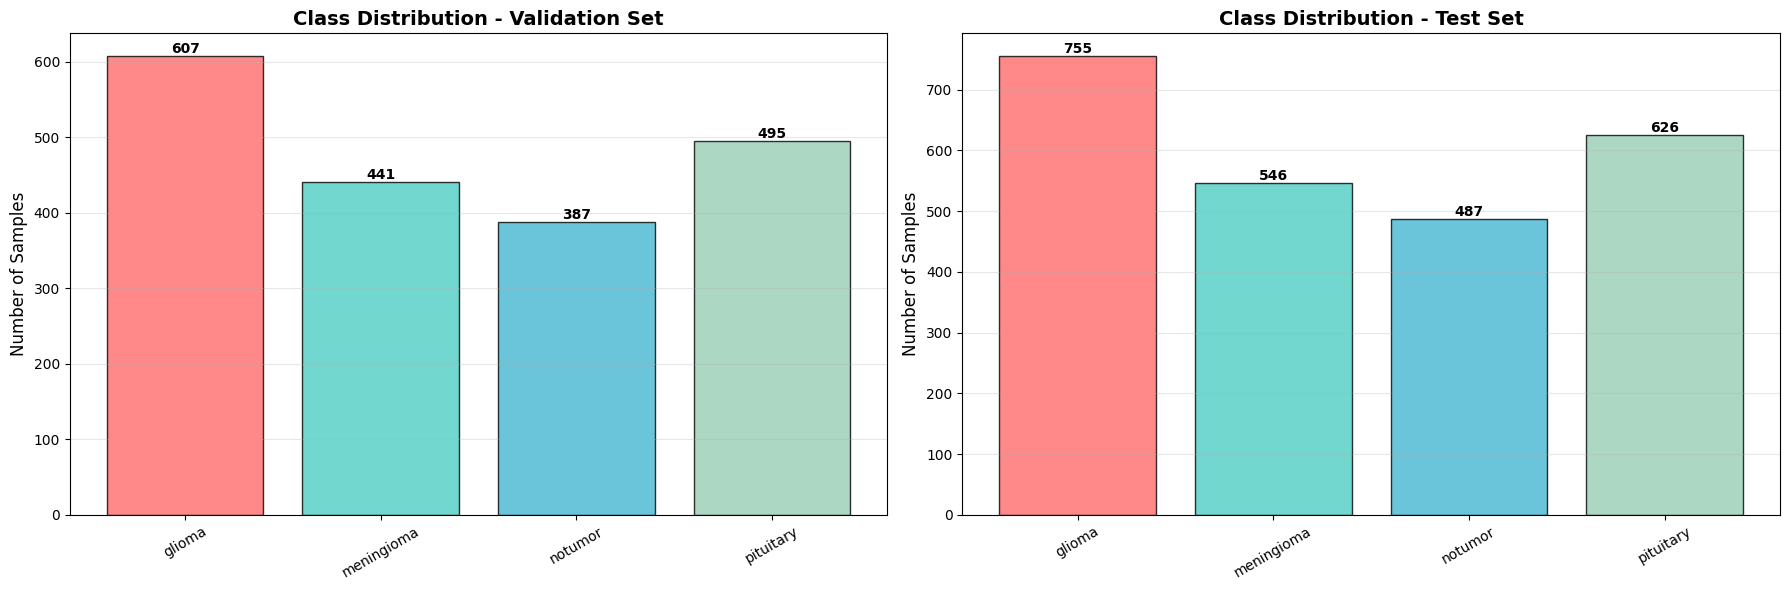

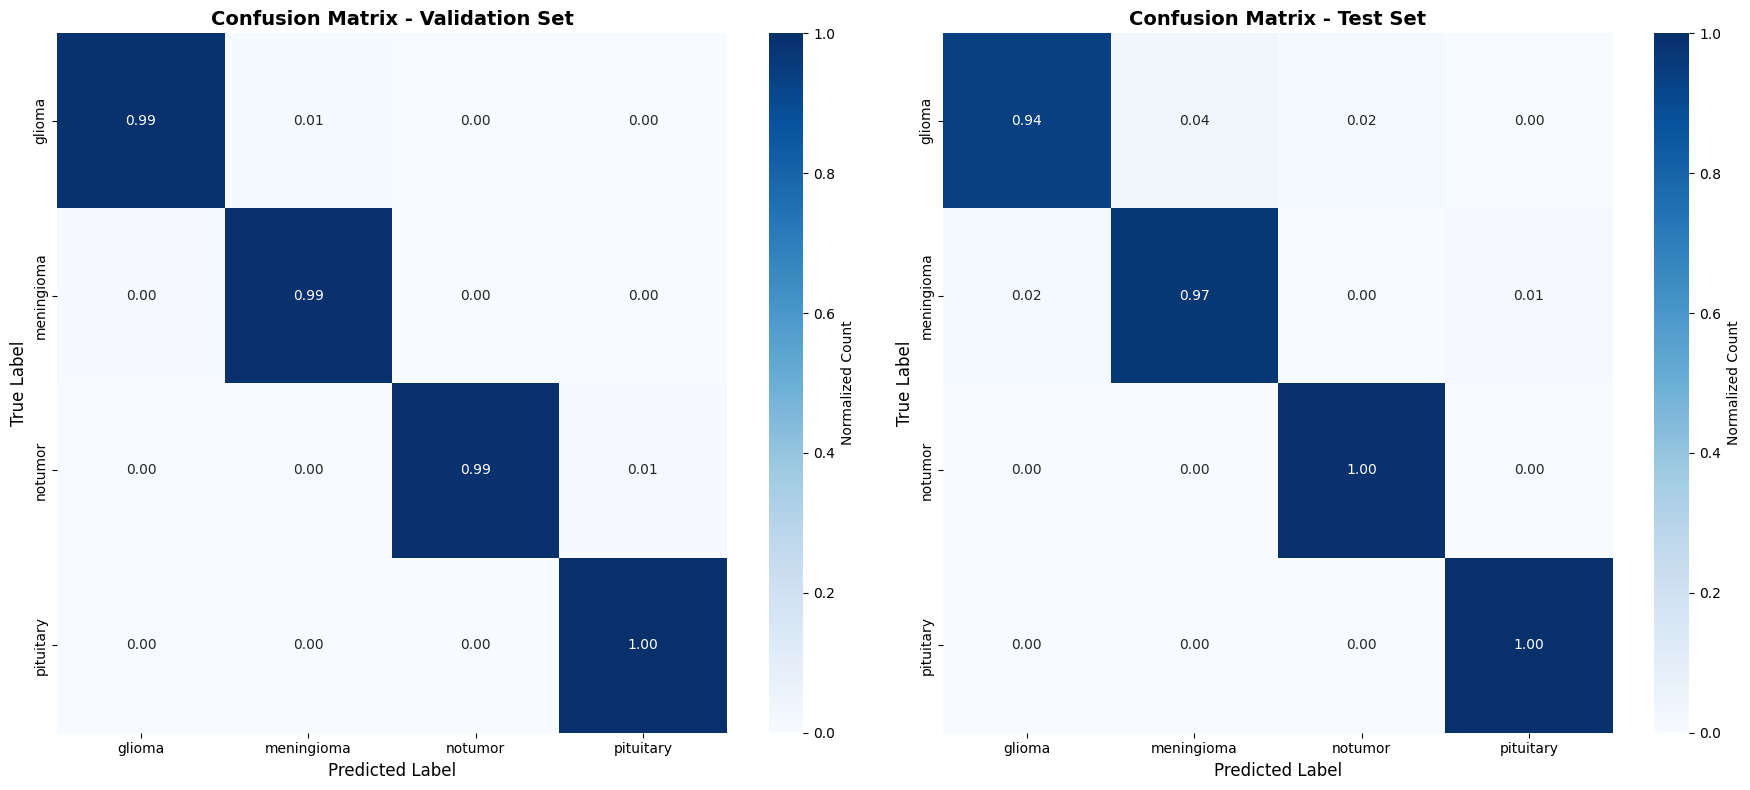

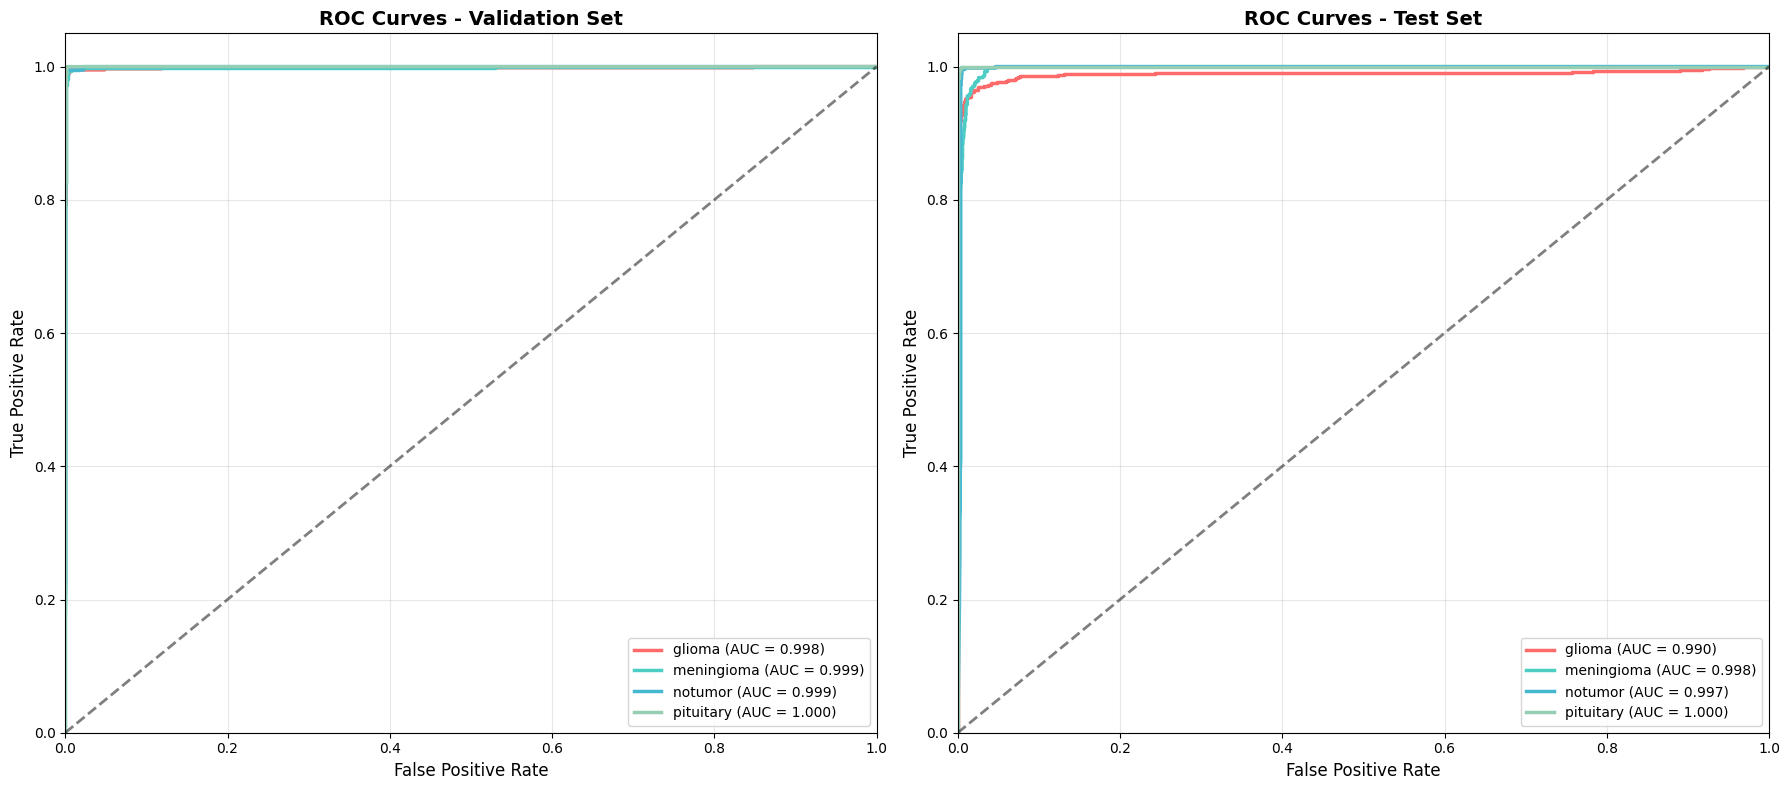

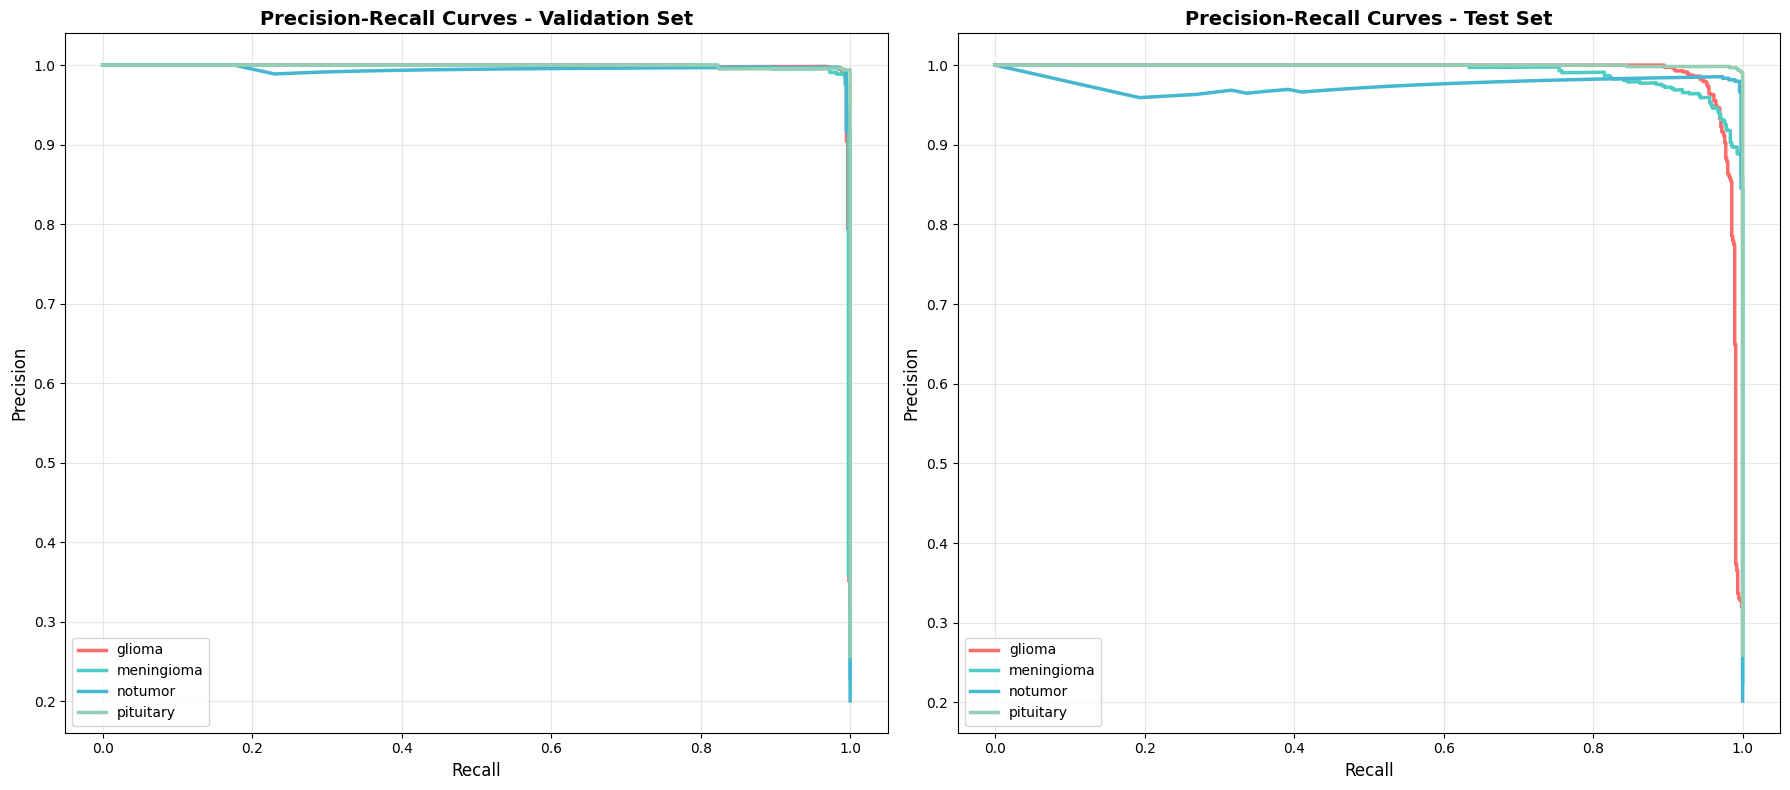

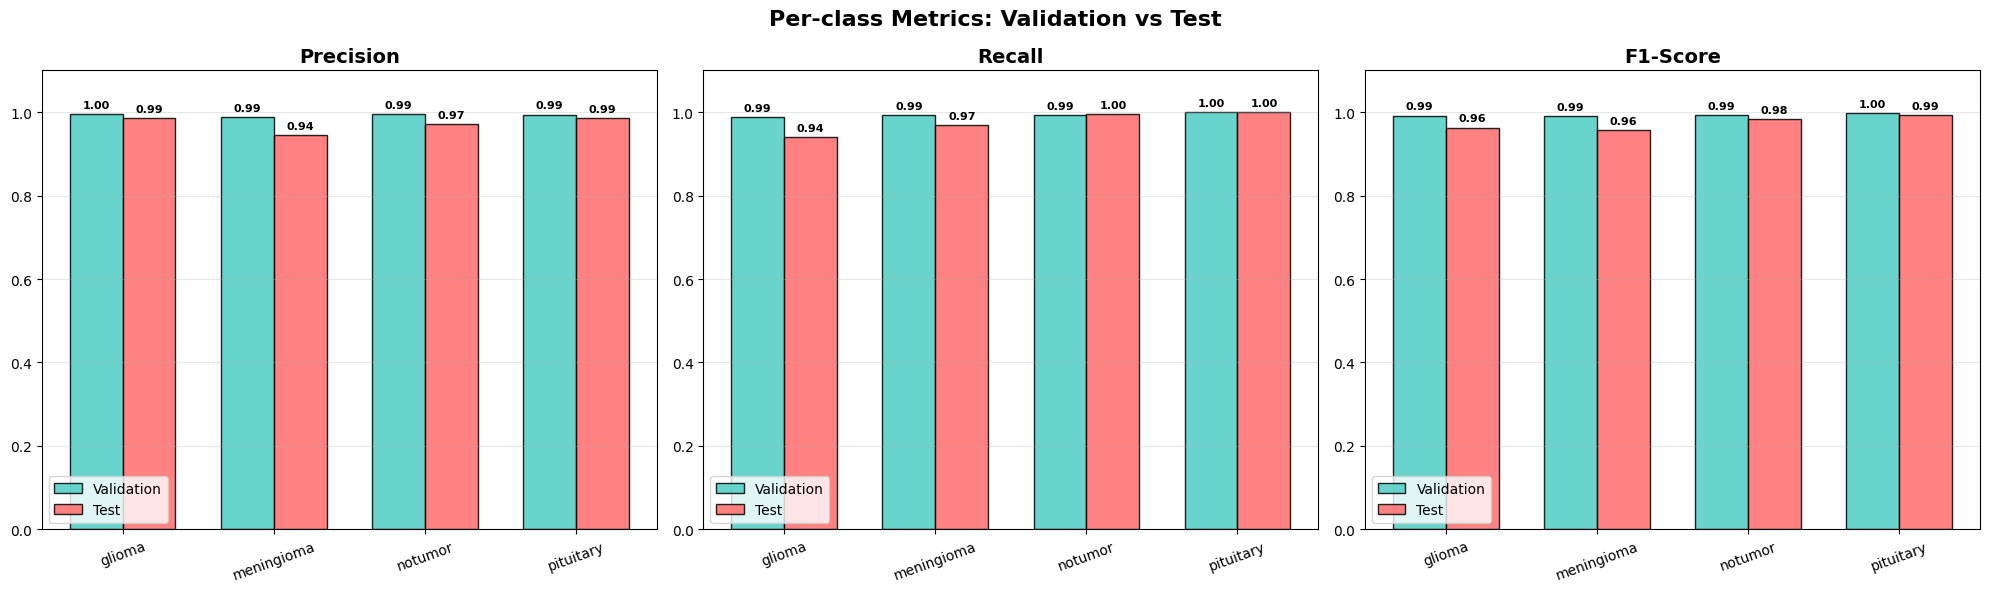

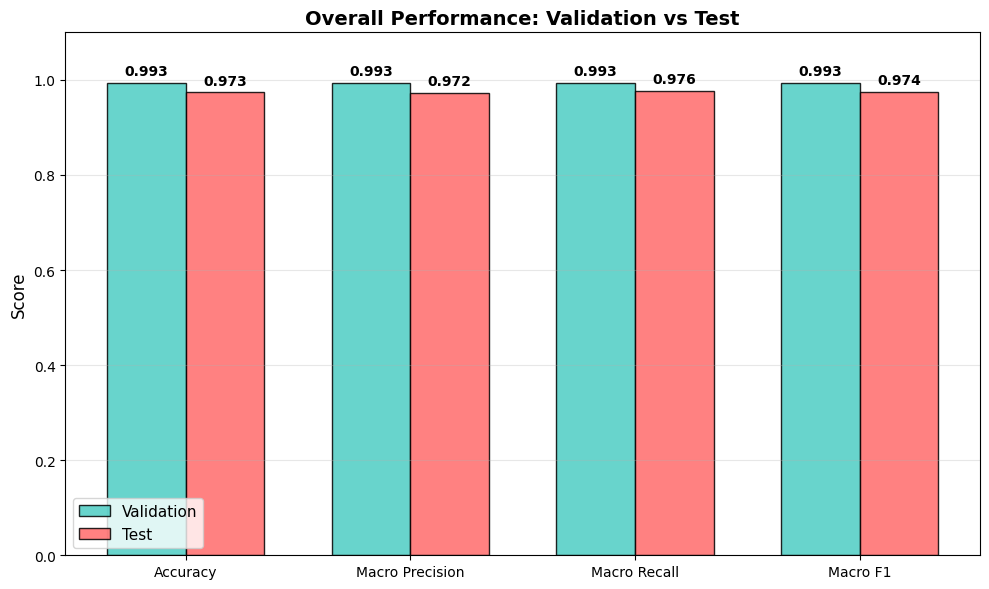


CLASSIFICATION REPORT — VALIDATION SET
              precision    recall  f1-score   support

      glioma      0.995     0.988     0.992       607
  meningioma      0.989     0.993     0.991       441
     notumor      0.995     0.992     0.994       387
   pituitary      0.994     1.000     0.997       495

    accuracy                          0.993      1930
   macro avg      0.993     0.993     0.993      1930
weighted avg      0.993     0.993     0.993      1930


CLASSIFICATION REPORT — TEST SET
              precision    recall  f1-score   support

      glioma      0.986     0.940     0.963       755
  meningioma      0.945     0.969     0.957       546
     notumor      0.972     0.996     0.984       487
   pituitary      0.986     1.000     0.993       626

    accuracy                          0.973      2414
   macro avg      0.972     0.976     0.974      2414
weighted avg      0.974     0.973     0.973      2414


✅ All visualizations saved to: D:\Master\Brain Tumor MR

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ============================
# إعدادات العرض
# ============================
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

# مجلد حفظ الصور
SAVE_DIR = Path("evaluation_results_val_vs_test")
SAVE_DIR.mkdir(exist_ok=True)

# إعداد الجهاز
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================
# دالة مساعدة للحفظ والعرض
# ============================
def save_and_show(filename):
    filepath = SAVE_DIR / filename
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

# ============================
# فئة مجموعة البيانات
# ============================
class BrainTumorMRIDataset(Dataset):
    """
    نسخة عامة تدعم القراءة من أي مجلد فرعي (Training أو Testing)
    وتدعم أيضاً إنشاء نسخ فرعية (subset) بنفس منطق سكربت التدريب،
    لضمان القدرة على إعادة إنتاج تقسيم Validation بدقة.
    """
    def __init__(self, data_dir, split_folder="Training", transform=None):
        self.data_dir = Path(data_dir)
        self.split_folder = split_folder
        self.transform = transform

        self.class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
        self.class_to_idx = {name: idx for idx, name in enumerate(self.class_names)}

        self.samples = []
        self._scan_directory()

    def _scan_directory(self):
        # يجب أن يطابق تماماً منطق المسح في سكربت التدريب:
        # نفس ترتيب class_names، نفس glob('*') بدون ترتيب إضافي،
        # مع إزالة التكرار (seen_paths) كما في سكربت التدريب.
        folder = self.data_dir / self.split_folder
        seen_paths = set()
        if folder.exists():
            for class_name in self.class_names:
                class_folder = folder / class_name
                if class_folder.exists():
                    label = self.class_to_idx[class_name]
                    for img_path in class_folder.glob('*'):
                        if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                            img_path_str = str(img_path.resolve())
                            if img_path_str not in seen_paths:
                                seen_paths.add(img_path_str)
                                self.samples.append((img_path_str, label))
        else:
            print(f"❌ Folder not found: {folder}")

    def print_class_distribution(self, title=""):
        class_counts = [0] * len(self.class_names)
        for _, label in self.samples:
            class_counts[label] += 1
        print(f"📊 Class Distribution {title}:")
        for class_name, count in zip(self.class_names, class_counts):
            print(f"  {class_name}: {count} images")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception:
            black_img = Image.new('RGB', (128, 128), (0, 0, 0))
            if self.transform:
                return self.transform(black_img), label
            return torch.zeros(3, 128, 128), label


def build_validation_split(data_dir, val_transform, train_split=0.8, seed=42):
    """
    يعيد إنتاج نفس تقسيم Validation المستخدم أثناء التدريب بالضبط:
    - نفس مسح مجلد Training بنفس الترتيب
    - نفس seed = 42
    - نفس منطق shuffle + train_size = int(0.8 * total)
    - val_indices = indices[train_size:]
    """
    full_dataset = BrainTumorMRIDataset(data_dir, split_folder="Training", transform=None)
    total_size = len(full_dataset)
    train_size = int(train_split * total_size)

    indices = list(range(total_size))
    np.random.seed(seed)
    np.random.shuffle(indices)

    val_indices = indices[train_size:]
    val_samples = [full_dataset.samples[i] for i in val_indices]

    val_dataset = BrainTumorMRIDataset.__new__(BrainTumorMRIDataset)
    val_dataset.data_dir = full_dataset.data_dir
    val_dataset.split_folder = "Training (validation subset)"
    val_dataset.transform = val_transform
    val_dataset.class_names = full_dataset.class_names
    val_dataset.class_to_idx = full_dataset.class_to_idx
    val_dataset.samples = val_samples

    print(f"📈 Full Training pool: {total_size} images")
    print(f"📊 Validation subset (last {total_size - train_size}): {len(val_dataset)} images")

    return val_dataset


# ============================
# مكونات المعمارية الجديدة
# ============================
class MicroAdaptiveFeatureExtractor(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        reduced_ch = max(1, channels // reduction)
        self.spatial_conv = nn.Conv2d(channels, 1, 1)  # الانتباه المكاني (Spatial Attention)
        self.channel_avg = nn.AdaptiveAvgPool2d(1) #انتباه القنوات (Channel Attention)
        self.channel_fc = nn.Conv2d(channels, reduced_ch, 1) #انتباه القنوات
        self.channel_out = nn.Conv2d(reduced_ch, channels, 1) #انتباه القنوات
        self.alpha = nn.Parameter(torch.tensor(0.3), requires_grad=True) #التحكم بقوة تأثير الانتباه
        #القيمة البدائية 30% ثم تتغير مع التدريب

    def forward(self, x):
        spatial_weights = torch.sigmoid(self.spatial_conv(x))
        x_spatial = x * spatial_weights
        channel_pool = self.channel_avg(x_spatial)
        channel_weights = torch.sigmoid(self.channel_out(F.relu(self.channel_fc(channel_pool))))
        x_enhanced = x_spatial * channel_weights
        return x + self.alpha * x_enhanced


class MicroMultiScaleProcessor(nn.Module):
    def __init__(self, channels):
        super().__init__()
        inter = max(8, channels // 4)
        while inter % 4 != 0 and inter > 4:
            inter -= 1
        if inter < 4:
            inter = 4

        self.scale1 = nn.Conv2d(channels, inter, 1, bias=False)
        self.scale3 = nn.Conv2d(channels, inter, 3, padding=1, bias=False)

        if channels >= 8 and inter >= 4:
            groups = 1
            for g in [8, 4, 2]:
                if channels % g == 0:
                    groups = g
                    break
            self.scale3dw = nn.Conv2d(channels, inter, 3, padding=1, groups=groups, bias=False)
        else:
            self.scale3dw = nn.Conv2d(channels, inter, 3, padding=1, bias=False)

        self.fusion = nn.Conv2d(inter * 3, channels, 1, bias=False)
        self.beta = nn.Parameter(torch.tensor(0.3), requires_grad=True)

    def forward(self, x):
        s1 = F.relu(self.scale1(x))
        s3 = F.relu(self.scale3(x))
        s3dw = F.relu(self.scale3dw(x))
        combined = torch.cat([s1, s3, s3dw], dim=1)
        fused = self.fusion(combined)
        return F.relu(x + self.beta * fused)


class MicroIntelligentPooling(nn.Module):
    def __init__(self, channels):
        super().__init__()
        decision_ch = max(2, channels // 8)
        self.decision = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, decision_ch, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(decision_ch, 2, 1),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        B, C, H, W = x.shape
        decision_weights = self.decision(x)
        max_pool = F.max_pool2d(x, kernel_size=2, stride=2)
        avg_pool = F.avg_pool2d(x, kernel_size=2, stride=2)
        w1 = decision_weights[:, 0:1, :, :].view(B, 1, 1, 1)
        w2 = decision_weights[:, 1:2, :, :].view(B, 1, 1, 1)
        return w1 * max_pool + w2 * avg_pool

#         إذا كانت خريطة الميزات تحتوي على استجابات قوية وحادة، فقد يتعلم إعطاء وزن أكبر لـ Max Pooling.
# إذا كانت خريطة الميزات تحتوي على معلومات منتشرة أو ناعمة، فقد يتعلم إعطاء وزن أكبر لـ Average Pooling.


# ============================
# النموذج الرئيسي (بدون تغيير)
# ============================
class UltraLightPatentBrainTumorCNN(nn.Module):
    def __init__(self, num_classes=4, base_channels=[32, 64, 128, 256]):
        super().__init__()
        c1, c2, c3, c4 = base_channels

        self.conv1 = nn.Conv2d(3, c1, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(c1)
        self.adaptive1 = MicroAdaptiveFeatureExtractor(c1, reduction=4)
        self.pool1 = MicroIntelligentPooling(c1)

        self.conv2 = nn.Conv2d(c1, c2, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(c2)
        self.multiscale2 = MicroMultiScaleProcessor(c2)
        self.pool2 = MicroIntelligentPooling(c2)

        self.conv3 = nn.Conv2d(c2, c3, 3, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(c3)
        self.adaptive3 = MicroAdaptiveFeatureExtractor(c3, reduction=8)
        self.pool3 = MicroIntelligentPooling(c3)

        self.conv4 = nn.Conv2d(c3, c4, 3, padding=1, bias=False)
        self.bn4 = nn.BatchNorm2d(c4)
        self.multiscale4 = MicroMultiScaleProcessor(c4)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(c4, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.adaptive1(x)
        x = self.pool1(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.multiscale2(x)
        x = self.pool2(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.adaptive3(x)
        x = self.pool3(x)

        x = F.relu(self.bn4(self.conv4(x)))
        x = self.multiscale4(x)

        return self.classifier(x)
        
# يحتوي على طبقتين Fully Connected (Linear)

# ============================
# دوال التقييم
# ============================
def load_model(model_path, device):
    model = UltraLightPatentBrainTumorCNN(num_classes=4).to(device)
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print(f"✅ Model loaded successfully from {model_path}")
    return model, checkpoint


def evaluate_model(model, dataloader, device):
    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    return np.array(all_targets), np.array(all_preds), np.array(all_probs)


def create_test_transforms(image_size=128):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])


# ============================
# دوال التصور المقارنة (Validation vs Test)
# ============================
def compute_metrics(targets, preds):
    return {
        'accuracy': accuracy_score(targets, preds),
        'precision': precision_score(targets, preds, average=None),
        'recall': recall_score(targets, preds, average=None),
        'f1': f1_score(targets, preds, average=None),
        'macro_precision': precision_score(targets, preds, average='macro'),
        'macro_recall': recall_score(targets, preds, average='macro'),
        'macro_f1': f1_score(targets, preds, average='macro'),
    }


def plot_confusion_matrices_side_by_side(val_targets, val_preds, test_targets, test_preds, class_names):
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    for ax, targets, preds, title in [
        (axes[0], val_targets, val_preds, 'Validation Set'),
        (axes[1], test_targets, test_preds, 'Test Set'),
    ]:
        cm = confusion_matrix(targets, preds)
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    cbar_kws={'label': 'Normalized Count'}, ax=ax)
        ax.set_title(f'Confusion Matrix - {title}', fontsize=14, fontweight='bold')
        ax.set_ylabel('True Label', fontsize=12)
        ax.set_xlabel('Predicted Label', fontsize=12)

    plt.tight_layout()
    save_and_show("01_confusion_matrix_val_vs_test.png")


def plot_roc_curves_side_by_side(val_targets, val_probs, test_targets, test_probs, class_names):
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

    for ax, targets, probs, title in [
        (axes[0], val_targets, val_probs, 'Validation Set'),
        (axes[1], test_targets, test_probs, 'Test Set'),
    ]:
        targets_bin = label_binarize(targets, classes=range(len(class_names)))
        for i in range(len(class_names)):
            fpr, tpr, _ = roc_curve(targets_bin[:, i], probs[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, color=colors[i], lw=2.5,
                    label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

        ax.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5)
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate', fontsize=12)
        ax.set_ylabel('True Positive Rate', fontsize=12)
        ax.set_title(f'ROC Curves - {title}', fontsize=14, fontweight='bold')
        ax.legend(loc="lower right", fontsize=10)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    save_and_show("02_roc_curves_val_vs_test.png")


def plot_pr_curves_side_by_side(val_targets, val_probs, test_targets, test_probs, class_names):
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

    for ax, targets, probs, title in [
        (axes[0], val_targets, val_probs, 'Validation Set'),
        (axes[1], test_targets, test_probs, 'Test Set'),
    ]:
        targets_bin = label_binarize(targets, classes=range(len(class_names)))
        for i in range(len(class_names)):
            precision, recall, _ = precision_recall_curve(targets_bin[:, i], probs[:, i])
            ax.plot(recall, precision, color=colors[i], lw=2.5, label=f'{class_names[i]}')

        ax.set_xlabel('Recall', fontsize=12)
        ax.set_ylabel('Precision', fontsize=12)
        ax.set_title(f'Precision-Recall Curves - {title}', fontsize=14, fontweight='bold')
        ax.legend(loc="lower left", fontsize=10)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    save_and_show("03_precision_recall_curves_val_vs_test.png")


def plot_per_class_metrics_grouped(val_metrics, test_metrics, class_names):
    """يعرض لكل مقياس (Precision/Recall/F1) مقارنة Validation vs Test لكل صنف"""
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    metric_names = ['precision', 'recall', 'f1']
    titles = ['Precision', 'Recall', 'F1-Score']

    x = np.arange(len(class_names))
    width = 0.35

    for ax, metric_key, title in zip(axes, metric_names, titles):
        val_vals = val_metrics[metric_key]
        test_vals = test_metrics[metric_key]

        bars1 = ax.bar(x - width/2, val_vals, width, label='Validation', color='#4ECDC4', alpha=0.85, edgecolor='black')
        bars2 = ax.bar(x + width/2, test_vals, width, label='Test', color='#FF6B6B', alpha=0.85, edgecolor='black')

        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(class_names, rotation=20)
        ax.set_ylim([0, 1.1])
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')

        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{height:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    plt.suptitle('Per-class Metrics: Validation vs Test', fontsize=16, fontweight='bold')
    plt.tight_layout()
    save_and_show("04_per_class_metrics_val_vs_test.png")


def plot_overall_accuracy_comparison(val_metrics, test_metrics):
    fig, ax = plt.subplots(figsize=(10, 6))

    labels = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']
    val_values = [val_metrics['accuracy'], val_metrics['macro_precision'],
                  val_metrics['macro_recall'], val_metrics['macro_f1']]
    test_values = [test_metrics['accuracy'], test_metrics['macro_precision'],
                   test_metrics['macro_recall'], test_metrics['macro_f1']]

    x = np.arange(len(labels))
    width = 0.35

    bars1 = ax.bar(x - width/2, val_values, width, label='Validation', color='#4ECDC4', alpha=0.85, edgecolor='black')
    bars2 = ax.bar(x + width/2, test_values, width, label='Test', color='#FF6B6B', alpha=0.85, edgecolor='black')

    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Overall Performance: Validation vs Test', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim([0, 1.1])
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    save_and_show("05_overall_accuracy_val_vs_test.png")


def plot_class_distribution_side_by_side(val_targets, test_targets, class_names):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

    for ax, targets, title in [
        (axes[0], val_targets, 'Validation Set'),
        (axes[1], test_targets, 'Test Set'),
    ]:
        class_counts = [np.sum(targets == i) for i in range(len(class_names))]
        bars = ax.bar(class_names, class_counts, color=colors, alpha=0.8, edgecolor='black')
        ax.set_title(f'Class Distribution - {title}', fontsize=14, fontweight='bold')
        ax.set_ylabel('Number of Samples', fontsize=12)
        ax.tick_params(axis='x', rotation=30)
        ax.grid(True, alpha=0.3, axis='y')
        for bar, count in zip(bars, class_counts):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{count}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    save_and_show("06_class_distribution_val_vs_test.png")


def print_comparison_report(val_targets, val_preds, test_targets, test_preds, class_names):
    print("\n" + "="*70)
    print("CLASSIFICATION REPORT — VALIDATION SET")
    print("="*70)
    print(classification_report(val_targets, val_preds, target_names=class_names, digits=3))

    print("\n" + "="*70)
    print("CLASSIFICATION REPORT — TEST SET")
    print("="*70)
    print(classification_report(test_targets, test_preds, target_names=class_names, digits=3))
    print("="*70)


# ============================
# البرنامج الرئيسي
# ============================
def main():
    print("="*60)
    print("BRAIN TUMOR MODEL — VALIDATION vs TEST COMPARISON")
    print("="*60)
    print(f"📁 Results will be saved to: {SAVE_DIR.resolve()}")

    MODEL_PATH = "best_brain_tumor_model_patent.pth"
    DATA_DIR = "Brain Tumor MRI Dataset Big"

    if not Path(MODEL_PATH).exists():
        print(f"❌ Model file not found: {MODEL_PATH}")
        return

    print(f"\n📥 Loading model from: {MODEL_PATH}")
    model, checkpoint = load_model(MODEL_PATH, device)

    class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
    print(f"📋 Classes: {class_names}")

    eval_transform = create_test_transforms(128)

    # ---- إعادة إنتاج مجموعة الـ Validation بنفس منطق التدريب ----
    print(f"\n📂 Rebuilding Validation split from: {DATA_DIR}/Training (seed=42, split=0.8)")
    val_dataset = build_validation_split(DATA_DIR, val_transform=eval_transform,
                                          train_split=0.8, seed=42)
    val_dataset.print_class_distribution("(Validation)")
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

    # ---- تحميل مجموعة الـ Test ----
    print(f"\n📂 Loading Test data from: {DATA_DIR}/Testing")
    test_dataset = BrainTumorMRIDataset(DATA_DIR, split_folder="Testing", transform=eval_transform)
    test_dataset.print_class_distribution("(Test)")
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

    # ---- التقييم على المجموعتين ----
    print(f"\n🔄 Evaluating on Validation set...")
    val_targets, val_preds, val_probs = evaluate_model(model, val_loader, device)

    print(f"🔄 Evaluating on Test set...")
    test_targets, test_preds, test_probs = evaluate_model(model, test_loader, device)

    val_metrics = compute_metrics(val_targets, val_preds)
    test_metrics = compute_metrics(test_targets, test_preds)

    print(f"\n" + "="*60)
    print(f"✅ RESULTS SUMMARY")
    print(f"="*60)
    print(f"Validation — Accuracy: {val_metrics['accuracy']:.4f} ({val_metrics['accuracy']*100:.2f}%) | Samples: {len(val_targets)}")
    print(f"Test       — Accuracy: {test_metrics['accuracy']:.4f} ({test_metrics['accuracy']*100:.2f}%) | Samples: {len(test_targets)}")
    gap = (val_metrics['accuracy'] - test_metrics['accuracy']) * 100
    print(f"Gap (Val - Test): {gap:+.2f} percentage points")
    print(f"="*60)

    print(f"\n📊 Generating comparison visualizations...\n")

    plot_class_distribution_side_by_side(val_targets, test_targets, class_names)
    plot_confusion_matrices_side_by_side(val_targets, val_preds, test_targets, test_preds, class_names)
    plot_roc_curves_side_by_side(val_targets, val_probs, test_targets, test_probs, class_names)
    plot_pr_curves_side_by_side(val_targets, val_probs, test_targets, test_probs, class_names)
    plot_per_class_metrics_grouped(val_metrics, test_metrics, class_names)
    plot_overall_accuracy_comparison(val_metrics, test_metrics)

    print_comparison_report(val_targets, val_preds, test_targets, test_preds, class_names)

    print(f"\n✅ All visualizations saved to: {SAVE_DIR.resolve()}")
    print(f"🎉 Validation vs Test comparison finished successfully!")


if __name__ == "__main__":
    main()

In [ ]:
# كود التدريب والاختبار والتحقق انتهى

In [ ]:
# كود التعميم

In [ ]:
# كود الاختبار على بيانات kaggle

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ============================
# Setup
# ============================
plt.style.use('default')
sns.set_palette("husl")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================
# Dataset Class
# ============================
class BrainTumorTestDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = Path(data_dir)
        self.transform = transform

        self.class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
        self.class_to_idx = {class_name: idx for idx, class_name in enumerate(self.class_names)}

        self.samples = []
        self._scan_directory()

        print(f"📁 Found {len(self.samples)} test images")
        self._print_class_distribution()

    def _scan_directory(self):
        for class_name in self.class_names:
            class_folder = self.data_dir / class_name
            if class_folder.exists():
                label = self.class_to_idx[class_name]

                for img_path in class_folder.glob('*'):
                    if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                        self.samples.append((str(img_path.resolve()), label))

    def _print_class_distribution(self):
        class_counts = [0] * len(self.class_names)
        for _, label in self.samples:
            class_counts[label] += 1

        print("📊 Test Set Distribution:")
        for class_name, count in zip(self.class_names, class_counts):
            print(f"   {class_name}: {count} images")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            return torch.zeros(3, 128, 128), label

# ============================
# Model Components
# ============================
class MicroAdaptiveFeatureExtractor(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        reduced_ch = max(1, channels // reduction)

        self.spatial_conv = nn.Conv2d(channels, 1, 1)
        self.channel_avg = nn.AdaptiveAvgPool2d(1)
        self.channel_fc = nn.Conv2d(channels, reduced_ch, 1)
        self.channel_out = nn.Conv2d(reduced_ch, channels, 1)
        self.alpha = nn.Parameter(torch.tensor(0.3), requires_grad=True)

    def forward(self, x):
        spatial_weights = torch.sigmoid(self.spatial_conv(x))
        x_spatial = x * spatial_weights

        channel_pool = self.channel_avg(x_spatial)
        channel_weights = torch.sigmoid(self.channel_out(F.relu(self.channel_fc(channel_pool))))
        x_enhanced = x_spatial * channel_weights

        return x + self.alpha * x_enhanced

class MicroMultiScaleProcessor(nn.Module):
    def __init__(self, channels):
        super().__init__()
        inter = max(8, channels // 4)
        while inter % 4 != 0 and inter > 4:
            inter -= 1
        if inter < 4:
            inter = 4

        self.scale1 = nn.Conv2d(channels, inter, 1, bias=False)
        self.scale3 = nn.Conv2d(channels, inter, 3, padding=1, bias=False)

        if channels >= 8 and inter >= 4:
            groups = 1
            for g in [8, 4, 2]:
                if channels % g == 0:
                    groups = g
                    break
            self.scale3dw = nn.Conv2d(channels, inter, 3, padding=1, groups=groups, bias=False)
        else:
            self.scale3dw = nn.Conv2d(channels, inter, 3, padding=1, bias=False)

        self.fusion = nn.Conv2d(inter * 3, channels, 1, bias=False)
        self.beta = nn.Parameter(torch.tensor(0.3), requires_grad=True)

    def forward(self, x):
        s1 = F.relu(self.scale1(x))
        s3 = F.relu(self.scale3(x))
        s3dw = F.relu(self.scale3dw(x))

        combined = torch.cat([s1, s3, s3dw], dim=1)
        fused = self.fusion(combined)

        return F.relu(x + self.beta * fused)

class MicroIntelligentPooling(nn.Module):
    def __init__(self, channels):
        super().__init__()
        decision_ch = max(2, channels // 8)

        self.decision = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, decision_ch, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(decision_ch, 2, 1),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        B, C, H, W = x.shape
        decision_weights = self.decision(x)

        max_pool = F.max_pool2d(x, kernel_size=2, stride=2)
        avg_pool = F.avg_pool2d(x, kernel_size=2, stride=2)

        w1 = decision_weights[:, 0:1, :, :].view(B, 1, 1, 1)
        w2 = decision_weights[:, 1:2, :, :].view(B, 1, 1, 1)

        return w1 * max_pool + w2 * avg_pool

# ============================
# Main Model
# ============================
class UltraLightPatentBrainTumorCNN(nn.Module):
    def __init__(self, num_classes=4, base_channels=[32, 64, 128, 256]):
        super().__init__()
        c1, c2, c3, c4 = base_channels

        self.conv1 = nn.Conv2d(3, c1, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(c1)
        self.adaptive1 = MicroAdaptiveFeatureExtractor(c1, reduction=4)
        self.pool1 = MicroIntelligentPooling(c1)

        self.conv2 = nn.Conv2d(c1, c2, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(c2)
        self.multiscale2 = MicroMultiScaleProcessor(c2)
        self.pool2 = MicroIntelligentPooling(c2)

        self.conv3 = nn.Conv2d(c2, c3, 3, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(c3)
        self.adaptive3 = MicroAdaptiveFeatureExtractor(c3, reduction=8)
        self.pool3 = MicroIntelligentPooling(c3)

        self.conv4 = nn.Conv2d(c3, c4, 3, padding=1, bias=False)
        self.bn4 = nn.BatchNorm2d(c4)
        self.multiscale4 = MicroMultiScaleProcessor(c4)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(c4, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.adaptive1(x)
        x = self.pool1(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.multiscale2(x)
        x = self.pool2(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.adaptive3(x)
        x = self.pool3(x)

        x = F.relu(self.bn4(self.conv4(x)))
        x = self.multiscale4(x)

        return self.classifier(x)

# ============================
# Testing Functions
# ============================
def test_epoch(model, dataloader, device, class_names):
    model.eval()
    all_preds = []
    all_targets = []
    all_probs = []
    all_correct = []

    print(f"\n🧪 Testing Model...")

    with torch.no_grad():
        for data, targets in dataloader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            probs = F.softmax(outputs, dim=1)

            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_correct.extend((predicted == targets).cpu().numpy())

    return np.array(all_preds), np.array(all_targets), np.array(all_probs), np.array(all_correct)

def create_test_results_summary(test_targets, test_preds, test_probs, class_names):
    """إنشاء ملخص نتائج الاختبار"""

    # الدقة الكلية
    accuracy = accuracy_score(test_targets, test_preds)
    precision = precision_score(test_targets, test_preds, average=None)
    recall = recall_score(test_targets, test_preds, average=None)
    f1 = f1_score(test_targets, test_preds, average=None)

    print("\n" + "="*70)
    print("🏆 TEST RESULTS SUMMARY")
    print("="*70)
    print(f"\n📊 OVERALL ACCURACY: {accuracy*100:.2f}%")
    print(f"\n📋 CLASSIFICATION REPORT:")
    print(classification_report(test_targets, test_preds, target_names=class_names, digits=4))
    print("="*70)

    return accuracy, precision, recall, f1

def plot_confusion_matrix(test_targets, test_preds, class_names):
    """رسم مصفوفة الالتباس"""
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(test_targets, test_preds)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_normalized, annot=cm, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Normalized'})

    plt.title('Test Set - Confusion Matrix', fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig('test_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ Saved: test_confusion_matrix.png")

def plot_roc_curves(test_targets, test_probs, class_names):
    """رسم منحنيات ROC"""
    plt.figure(figsize=(12, 8))

    y_test_bin = label_binarize(test_targets, classes=range(len(class_names)))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], lw=3,
                 label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Test Set - ROC Curves', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('test_roc_curves.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ Saved: test_roc_curves.png")

def plot_per_class_metrics(test_targets, test_preds, class_names):
    """رسم مقاييس الأداء لكل فئة"""
    plt.figure(figsize=(12, 6))

    precision = precision_score(test_targets, test_preds, average=None)
    recall = recall_score(test_targets, test_preds, average=None)
    f1 = f1_score(test_targets, test_preds, average=None)

    x = np.arange(len(class_names))
    width = 0.25

    plt.bar(x - width, precision, width, label='Precision', color='#FF6B6B', alpha=0.8)
    plt.bar(x, recall, width, label='Recall', color='#4ECDC4', alpha=0.8)
    plt.bar(x + width, f1, width, label='F1-Score', color='#45B7D1', alpha=0.8)

    plt.ylabel('Score', fontsize=12)
    plt.title('Test Set - Per-class Metrics', fontsize=16, fontweight='bold')
    plt.xticks(x, class_names)
    plt.legend()
    plt.ylim([0, 1.1])
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('test_per_class_metrics.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ Saved: test_per_class_metrics.png")

def plot_class_distribution(test_targets, class_names):
    """رسم توزيع الفئات في بيانات الاختبار"""
    plt.figure(figsize=(10, 6))

    class_counts = [np.sum(np.array(test_targets) == i) for i in range(len(class_names))]
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

    bars = plt.bar(class_names, class_counts, color=colors, alpha=0.8, edgecolor='black', linewidth=2)

    plt.title('Test Set - Class Distribution', fontsize=16, fontweight='bold')
    plt.ylabel('Number of Samples', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, axis='y')

    for bar, count in zip(bars, class_counts):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 2,
                  f'{count}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.savefig('test_class_distribution.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ Saved: test_class_distribution.png")

def plot_confidence_distribution(test_preds, test_targets, test_probs, class_names):
    """رسم توزيع درجات الثقة"""
    plt.figure(figsize=(12, 6))

    confidences = np.max(test_probs, axis=1)
    correct_mask = (test_preds == test_targets)

    plt.hist(confidences[correct_mask], bins=30, alpha=0.7, label='Correct', color='#4ECDC4', edgecolor='black')
    plt.hist(confidences[~correct_mask], bins=30, alpha=0.7, label='Incorrect', color='#FF6B6B', edgecolor='black')

    plt.xlabel('Confidence Score', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Test Set - Model Confidence Distribution', fontsize=16, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('test_confidence_distribution.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ Saved: test_confidence_distribution.png")

def plot_comparison_summary(test_targets, test_preds, accuracy, precision, recall, f1):
    """رسم ملخص مقارن للأداء"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Accuracy
    ax = axes[0, 0]
    ax.bar(['Accuracy'], [accuracy*100], color='#4ECDC4', alpha=0.8, edgecolor='black', linewidth=2, width=0.5)
    ax.set_ylim([0, 105])
    ax.text(0, accuracy*100 + 2, f'{accuracy*100:.2f}%', ha='center', fontsize=14, fontweight='bold')
    ax.set_ylabel('Percentage (%)', fontsize=11)
    ax.set_title('Overall Accuracy', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # 2. Per-class Precision
    ax = axes[0, 1]
    x = np.arange(len(precision))
    ax.bar(x, precision*100, color='#FF6B6B', alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_xticks(x)
    ax.set_xticklabels(['Glioma', 'Meningioma', 'No Tumor', 'Pituitary'], rotation=45, ha='right')
    ax.set_ylabel('Score (%)', fontsize=11)
    ax.set_title('Precision by Class', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 105])
    ax.grid(True, alpha=0.3, axis='y')

    # 3. Per-class Recall
    ax = axes[1, 0]
    ax.bar(x, recall*100, color='#45B7D1', alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_xticks(x)
    ax.set_xticklabels(['Glioma', 'Meningioma', 'No Tumor', 'Pituitary'], rotation=45, ha='right')
    ax.set_ylabel('Score (%)', fontsize=11)
    ax.set_title('Recall by Class', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 105])
    ax.grid(True, alpha=0.3, axis='y')

    # 4. Per-class F1-Score
    ax = axes[1, 1]
    ax.bar(x, f1*100, color='#96CEB4', alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_xticks(x)
    ax.set_xticklabels(['Glioma', 'Meningioma', 'No Tumor', 'Pituitary'], rotation=45, ha='right')
    ax.set_ylabel('Score (%)', fontsize=11)
    ax.set_title('F1-Score by Class', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 105])
    ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle('Test Set - Performance Summary', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('test_performance_summary.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ Saved: test_performance_summary.png")

# ============================
# Main Testing Function
# ============================
def main():
    print("="*70)
    print("🧠 BRAIN TUMOR MRI - MODEL TESTING")
    print("="*70)

    # ======= UPDATE THIS PATH =======
    TEST_DIR = "Brain Tumor MRI Dataset Kaggle/Testing"
    MODEL_PATH = "best_brain_tumor_model_patent.pth"
    # ================================

    if not Path(TEST_DIR).exists():
        print(f"❌ Test directory not found: {TEST_DIR}")
        return

    if not Path(MODEL_PATH).exists():
        print(f"❌ Model file not found: {MODEL_PATH}")
        return

    # Parameters
    batch_size = 32
    image_size = 128

    # Create test dataset
    print(f"\n📂 Loading test data from: {TEST_DIR}")
    test_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    test_dataset = BrainTumorTestDataset(TEST_DIR, transform=test_transform)
    class_names = test_dataset.class_names

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True if device.type == 'cuda' else False
    )

    # Load model
    print(f"\n🔄 Loading model from: {MODEL_PATH}")
    model = UltraLightPatentBrainTumorCNN(num_classes=4).to(device)
    try:
        # محاولة أولى مع weights_only=False لتوافقية أفضل
        checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
    except:
        # احتياطي في حالة فشل المحاولة الأولى
        print("⚠️ Trying alternative loading method...")
        checkpoint = torch.load(MODEL_PATH, map_location=device)

    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    total_params = sum(p.numel() for p in model.parameters())
    print(f"✅ Model loaded! Parameters: {total_params:,}")

    # Run testing
    print(f"\n🧪 Starting test evaluation...")
    test_preds, test_targets, test_probs, test_correct = test_epoch(model, test_loader, device, class_names)

    # Print results
    accuracy, precision, recall, f1 = create_test_results_summary(test_targets, test_preds, test_probs, class_names)

    # Create visualizations
    print(f"\n🎨 Creating visualizations...")
    plot_confusion_matrix(test_targets, test_preds, class_names)
    plot_roc_curves(test_targets, test_probs, class_names)
    plot_per_class_metrics(test_targets, test_preds, class_names)
    plot_class_distribution(test_targets, class_names)
    plot_confidence_distribution(test_preds, test_targets, test_probs, class_names)
    plot_comparison_summary(test_targets, test_preds, accuracy, precision, recall, f1)

    print(f"\n" + "="*70)
    print(f"✅ TESTING COMPLETED SUCCESSFULLY!")
    print(f"="*70)
    print(f"📊 Total Test Samples: {len(test_targets)}")
    print(f"🎯 Correct Predictions: {np.sum(test_correct)} / {len(test_targets)}")
    print(f"📈 Accuracy: {accuracy*100:.2f}%")
    print(f"📋 All results saved to current directory")
    print(f"="*70)

if __name__ == "__main__":
    main()

Using device: cuda
🧠 BRAIN TUMOR MRI - MODEL TESTING

📂 Loading test data from: Brain Tumor MRI Dataset Kaggle/Testing
📁 Found 1600 test images
📊 Test Set Distribution:
   glioma: 400 images
   meningioma: 400 images
   notumor: 400 images
   pituitary: 400 images

🔄 Loading model from: best_brain_tumor_model_patent.pth
✅ Model loaded! Parameters: 659,228

🧪 Starting test evaluation...

🧪 Testing Model...

🏆 TEST RESULTS SUMMARY

📊 OVERALL ACCURACY: 98.38%

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      glioma     0.9922    0.9550    0.9732       400
  meningioma     0.9728    0.9825    0.9776       400
     notumor     0.9828    0.9975    0.9901       400
   pituitary     0.9877    1.0000    0.9938       400

    accuracy                         0.9838      1600
   macro avg     0.9838    0.9838    0.9837      1600
weighted avg     0.9838    0.9838    0.9837      1600


🎨 Creating visualizations...
✅ Saved: test_confusion_matrix.png
✅ Saved: test

In [ ]:
# Figshare كود الاستكشاف

In [9]:
import os

def explore_recursive(path, indent=0):
    if not os.path.isdir(path):
        print(" " * indent + f"📄 ملف: {os.path.basename(path)}")
        return

    print(" " * indent + f"📂 المجلد: {os.path.basename(path)}")

    try:
        items = os.listdir(path)
    except PermissionError:
        print(" " * (indent + 3) + "🚫 لا يمكن الوصول للمجلد (صلاحيات غير كافية)")
        return

    # فصل الملفات عن المجلدات
    dirs = [d for d in items if os.path.isdir(os.path.join(path, d))]
    files = [f for f in items if os.path.isfile(os.path.join(path, f))]

    # عرض أول 10 ملفات
    first_ten = files[:10]
    if first_ten:
        print(" " * (indent + 3) + "أول 10 ملفات:")
        for f in first_ten:
            print(" " * (indent + 6) + f"- {f}")
    else:
        print(" " * (indent + 3) + "(لا توجد ملفات)")

    # الدخول إلى المجلدات الداخلية
    for d in dirs:
        explore_recursive(os.path.join(path, d), indent + 3)

# مثال استخدام:
dataset_path = r"Figshare Brain Tumor Dataset"
explore_recursive(dataset_path)

📂 المجلد: Figshare Brain Tumor Dataset
   أول 10 ملفات:
      - cvind.mat
      - README.txt
   📂 المجلد: Figshare MRI Brain tumor Dataset
      (لا توجد ملفات)
      📂 المجلد: Figshare MRI Brain tumor Dataset
         أول 10 ملفات:
            - 1.mat
            - 10.mat
            - 100.mat
            - 1000.mat
            - 1001.mat
            - 1002.mat
            - 1003.mat
            - 1004.mat
            - 1005.mat
            - 1006.mat


In [ ]:
# كود تحويل بيانات الى صور

In [12]:
import h5py
import numpy as np
from PIL import Image
from pathlib import Path


def convert_mat_to_png():
    """تحويل ملفات .mat إلى صور PNG منظمة حسب الفئة"""

    MAT_DIR = "Figshare Brain Tumor Dataset/dataset/data"
    OUTPUT_DIR = "Figshare Brain Tumor Dataset PNG"

    mat_dir = Path(MAT_DIR)
    output_dir = Path(OUTPUT_DIR)

    if not mat_dir.exists():
        print(f"❌ المجلد غير موجود: {MAT_DIR}")
        return

    # إنشاء مجلدات الفئات
    class_names = ['meningioma', 'glioma', 'pituitary']
    class_to_label = {1: 'meningioma', 2: 'glioma', 3: 'pituitary'}

    for class_name in class_names:
        (output_dir / class_name).mkdir(parents=True, exist_ok=True)

    print(f"✅ تم إنشاء المجلدات في: {output_dir}\n")

    # البحث عن ملفات .mat
    mat_files = sorted(mat_dir.glob('*.mat'))
    if len(mat_files) == 0:
        mat_files = sorted(mat_dir.rglob('*.mat'))

    print(f"🔍 جاري تحويل {len(mat_files)} ملف...\n")

    count = 0
    class_counts = {'meningioma': 0, 'glioma': 0, 'pituitary': 0}

    for idx, mat_file in enumerate(mat_files):
        try:
            with h5py.File(str(mat_file), 'r') as f:
                if 'cjdata' in f:
                    cjdata = f['cjdata']
                    label = int(cjdata['label'][0, 0])
                    image = np.array(cjdata['image'])

                    if label in class_to_label:
                        class_name = class_to_label[label]

                        # تطبيع الصورة
                        image = image.astype(np.float32)
                        if image.max() > 1:
                            image = (image / image.max() * 255).astype(np.uint8)
                        else:
                            image = (image * 255).astype(np.uint8)

                        # حفظ الصورة
                        img = Image.fromarray(image, mode='L')
                        img_path = output_dir / class_name / f"{mat_file.stem}.png"
                        img.save(img_path)

                        count += 1
                        class_counts[class_name] += 1

                        if (idx + 1) % 500 == 0:
                            print(f" ✓ تم تحويل {idx + 1}/{len(mat_files)} ملف...")

        except Exception as e:
            pass

    print(f"\n✅ اكتمل التحويل!")
    print(f"📊 إجمالي الصور: {count}")
    print(f"   meningioma: {class_counts['meningioma']}")
    print(f"   glioma: {class_counts['glioma']}")
    print(f"   pituitary: {class_counts['pituitary']}")
    print(f"\n📁 تم حفظ الصور في: {OUTPUT_DIR}/")


if __name__ == "__main__":
    convert_mat_to_png()

✅ تم إنشاء المجلدات في: Figshare Brain Tumor Dataset PNG

🔍 جاري تحويل 3064 ملف...

 ✓ تم تحويل 500/3064 ملف...
 ✓ تم تحويل 1000/3064 ملف...
 ✓ تم تحويل 1500/3064 ملف...
 ✓ تم تحويل 2000/3064 ملف...
 ✓ تم تحويل 2500/3064 ملف...
 ✓ تم تحويل 3000/3064 ملف...

✅ اكتمل التحويل!
📊 إجمالي الصور: 3064
   meningioma: 708
   glioma: 1426
   pituitary: 930

📁 تم حفظ الصور في: Figshare Brain Tumor Dataset PNG/


In [ ]:
# كود الاختبار لغرض التعميم مع Figshare Brain Tumor Dataset

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ============================
# Setup
# ============================
plt.style.use('default')
sns.set_palette("husl")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================
# Test Dataset Class
# ============================
class BrainTumorTestDataset(Dataset):
    """
    Dataset used for evaluation. It looks for a 'Testing' (or 'Test') subfolder
    inside data_dir; if none exists, it treats data_dir itself as the folder
    containing the class subdirectories.
    """
    def __init__(self, data_dir, transform=None):
        self.data_dir = Path(data_dir)
        self.transform = transform

        self.class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
        self.class_to_idx = {class_name: idx for idx, class_name in enumerate(self.class_names)}

        self.samples = []
        self._scan_directory()

        if len(self.samples) == 0:
            raise ValueError(f"No images found under: {self.data_dir}")

        print(f"📁 Found {len(self.samples)} test images")
        self._print_class_distribution()

    def _resolve_root(self):
        for candidate in ["Testing", "Test", "test", "testing"]:
            candidate_path = self.data_dir / candidate
            if candidate_path.exists():
                print(f"📂 Using directory: {candidate_path}")
                return candidate_path
        print(f"📂 No 'Testing' subfolder found, using directory directly: {self.data_dir}")
        return self.data_dir

    def _scan_directory(self):
        root_folder = self._resolve_root()

        seen_paths = set()

        for class_name in self.class_names:
            class_folder = root_folder / class_name
            if class_folder.exists():
                label = self.class_to_idx[class_name]

                for img_path in class_folder.glob('*'):
                    if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                        img_path_str = str(img_path.resolve())
                        if img_path_str not in seen_paths:
                            seen_paths.add(img_path_str)
                            self.samples.append((img_path_str, label))
            else:
                print(f"⚠️ Class folder not found (skipping): {class_folder}")

        print(f"✅ تم تحميل {len(self.samples)} صورة فريدة")

    def _print_class_distribution(self):
        class_counts = [0] * len(self.class_names)
        for _, label in self.samples:
            class_counts[label] += 1

        print("📊 Class Distribution:")
        for class_name, count in zip(self.class_names, class_counts):
            print(f"   {class_name}: {count} images")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            black_img = Image.new('RGB', (128, 128), (0, 0, 0))
            if self.transform:
                return self.transform(black_img), label
            return torch.zeros(3, 128, 128), label

# ============================
# Patent Components
# ============================
class MicroAdaptiveFeatureExtractor(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        reduced_ch = max(1, channels // reduction)

        self.spatial_conv = nn.Conv2d(channels, 1, 1)
        self.channel_avg = nn.AdaptiveAvgPool2d(1)
        self.channel_fc = nn.Conv2d(channels, reduced_ch, 1)
        self.channel_out = nn.Conv2d(reduced_ch, channels, 1)
        self.alpha = nn.Parameter(torch.tensor(0.3), requires_grad=True)

    def forward(self, x):
        spatial_weights = torch.sigmoid(self.spatial_conv(x))
        x_spatial = x * spatial_weights

        channel_pool = self.channel_avg(x_spatial)
        channel_weights = torch.sigmoid(self.channel_out(F.relu(self.channel_fc(channel_pool))))
        x_enhanced = x_spatial * channel_weights

        return x + self.alpha * x_enhanced

class MicroMultiScaleProcessor(nn.Module):
    def __init__(self, channels):
        super().__init__()
        inter = max(8, channels // 4)
        while inter % 4 != 0 and inter > 4:
            inter -= 1
        if inter < 4:
            inter = 4

        self.scale1 = nn.Conv2d(channels, inter, 1, bias=False)
        self.scale3 = nn.Conv2d(channels, inter, 3, padding=1, bias=False)

        if channels >= 8 and inter >= 4:
            groups = 1
            for g in [8, 4, 2]:
                if channels % g == 0:
                    groups = g
                    break
            self.scale3dw = nn.Conv2d(channels, inter, 3, padding=1, groups=groups, bias=False)
        else:
            self.scale3dw = nn.Conv2d(channels, inter, 3, padding=1, bias=False)

        self.fusion = nn.Conv2d(inter * 3, channels, 1, bias=False)
        self.beta = nn.Parameter(torch.tensor(0.3), requires_grad=True)

    def forward(self, x):
        s1 = F.relu(self.scale1(x))
        s3 = F.relu(self.scale3(x))
        s3dw = F.relu(self.scale3dw(x))

        combined = torch.cat([s1, s3, s3dw], dim=1)
        fused = self.fusion(combined)

        return F.relu(x + self.beta * fused)

class MicroIntelligentPooling(nn.Module):
    def __init__(self, channels):
        super().__init__()
        decision_ch = max(2, channels // 8)

        self.decision = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, decision_ch, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(decision_ch, 2, 1),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        B, C, H, W = x.shape
        decision_weights = self.decision(x)

        max_pool = F.max_pool2d(x, kernel_size=2, stride=2)
        avg_pool = F.avg_pool2d(x, kernel_size=2, stride=2)

        w1 = decision_weights[:, 0:1, :, :].view(B, 1, 1, 1)
        w2 = decision_weights[:, 1:2, :, :].view(B, 1, 1, 1)

        return w1 * max_pool + w2 * avg_pool

# ============================
# Main Model
# ============================
class UltraLightPatentBrainTumorCNN(nn.Module):
    def __init__(self, num_classes=4, base_channels=[32, 64, 128, 256]):
        super().__init__()
        c1, c2, c3, c4 = base_channels

        print(f"🏗️ Building model with channels: {base_channels}")

        self.conv1 = nn.Conv2d(3, c1, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(c1)
        self.adaptive1 = MicroAdaptiveFeatureExtractor(c1, reduction=4)
        self.pool1 = MicroIntelligentPooling(c1)

        self.conv2 = nn.Conv2d(c1, c2, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(c2)
        self.multiscale2 = MicroMultiScaleProcessor(c2)
        self.pool2 = MicroIntelligentPooling(c2)

        self.conv3 = nn.Conv2d(c2, c3, 3, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(c3)
        self.adaptive3 = MicroAdaptiveFeatureExtractor(c3, reduction=8)
        self.pool3 = MicroIntelligentPooling(c3)

        self.conv4 = nn.Conv2d(c3, c4, 3, padding=1, bias=False)
        self.bn4 = nn.BatchNorm2d(c4)
        self.multiscale4 = MicroMultiScaleProcessor(c4)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(c4, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

        self._init_weights()
        print(f"✅ Model built successfully!")

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.)

    def forward(self, x):
        # Stage 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.adaptive1(x)
        x = self.pool1(x)

        # Stage 2
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.multiscale2(x)
        x = self.pool2(x)

        # Stage 3
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.adaptive3(x)
        x = self.pool3(x)

        # Stage 4
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.multiscale4(x)

        return self.classifier(x)


# ============================
# Testing Functions
# ============================
def test_epoch(model, dataloader, device, class_names):
    model.eval()
    all_preds = []
    all_targets = []
    all_probs = []

    print(f"\n🧪 Testing Model...")

    with torch.no_grad():
        for data, targets in dataloader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            probs = F.softmax(outputs, dim=1)

            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_preds), np.array(all_targets), np.array(all_probs)

def reclassify_missing_class(test_preds, test_probs, test_targets, missing_class_idx=2):
    """
    إعادة توجيه التصنيفات من الفئة الغير موجودة إلى أقرب فئة متاحة،
    ثم إزالة عينات تلك الفئة وإعادة ترقيم (remap) كل من:
      - القيم المتبقية في test_preds / test_targets
      - أعمدة test_probs (بحذف عمود الفئة المفقودة)
    بحيث تصبح القيم الجديدة متسقة مع class_names_filtered (0..N-2).
    """
    test_preds_adj = test_preds.copy()

    num_classes = test_probs.shape[1]
    available_classes = [i for i in range(num_classes) if i != missing_class_idx]

    # الصور المصنفة (predicted) في الفئة الغير موجودة تُعاد توجيهها لأقرب فئة متاحة
    misclassified = np.where(test_preds == missing_class_idx)[0]
    print(f"\n🔄 إعادة تصنيف {len(misclassified)} صورة من الفئة الغير موجودة...")

    for idx in misclassified:
        probs_available = test_probs[idx][available_classes]
        best_class = available_classes[np.argmax(probs_available)]
        test_preds_adj[idx] = best_class

    # إزالة العينات التي فئتها الحقيقية (target) هي الفئة المفقودة
    mask = test_targets != missing_class_idx
    preds_filtered = test_preds_adj[mask]
    targets_filtered = test_targets[mask]
    probs_filtered = test_probs[mask][:, available_classes]  # حذف عمود الاحتمالية للفئة المفقودة أيضاً

    # إعادة ترقيم القيم القديمة (مثلاً 0,1,3) إلى قيم متتالية جديدة (0,1,2)
    remap = {old_idx: new_idx for new_idx, old_idx in enumerate(available_classes)}
    preds_remapped = np.array([remap[p] for p in preds_filtered])
    targets_remapped = np.array([remap[t] for t in targets_filtered])

    return preds_remapped, targets_remapped, probs_filtered

def create_test_results_summary(test_targets, test_preds, test_probs, class_names):
    """إنشاء ملخص نتائج الاختبار"""

    accuracy = accuracy_score(test_targets, test_preds)
    precision = precision_score(test_targets, test_preds, average=None, zero_division=0)
    recall = recall_score(test_targets, test_preds, average=None, zero_division=0)
    f1 = f1_score(test_targets, test_preds, average=None, zero_division=0)

    print("\n" + "="*70)
    print("🏆 TEST RESULTS SUMMARY")
    print("="*70)
    print(f"\n📊 OVERALL ACCURACY: {accuracy*100:.2f}%")
    print(f"\n📋 CLASSIFICATION REPORT:")
    print(classification_report(test_targets, test_preds, target_names=class_names, digits=4, zero_division=0))
    print("="*70)

    return accuracy, precision, recall, f1

def plot_confusion_matrix(test_targets, test_preds, class_names, filename='test_confusion_matrix.png'):
    """رسم مصفوفة الالتباس"""
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(test_targets, test_preds, labels=range(len(class_names)))
    row_sums = cm.sum(axis=1)[:, np.newaxis]
    row_sums[row_sums == 0] = 1  # تجنب القسمة على صفر
    cm_normalized = cm.astype('float') / row_sums

    sns.heatmap(cm_normalized, annot=cm, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Normalized'})

    plt.title('Test Set - Confusion Matrix', fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Saved: {filename}")

def plot_roc_curves(test_targets, test_probs, class_names, filename='test_roc_curves.png'):
    """رسم منحنيات ROC"""
    plt.figure(figsize=(12, 8))

    n_classes = len(class_names)

    if n_classes == 2:
        # label_binarize يرجع عمود واحد فقط عندما يكون هناك فئتان
        y_test_bin = label_binarize(test_targets, classes=range(n_classes))
        y_test_bin = np.hstack([1 - y_test_bin, y_test_bin])
    else:
        y_test_bin = label_binarize(test_targets, classes=range(n_classes))

    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'][:n_classes]

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], lw=3,
                 label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Test Set - ROC Curves', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Saved: {filename}")

def plot_per_class_metrics(test_targets, test_preds, class_names, filename='test_per_class_metrics.png'):
    """رسم مقاييس الأداء لكل فئة"""
    plt.figure(figsize=(12, 6))

    precision = precision_score(test_targets, test_preds, average=None, zero_division=0,
                                 labels=range(len(class_names)))
    recall = recall_score(test_targets, test_preds, average=None, zero_division=0,
                           labels=range(len(class_names)))
    f1 = f1_score(test_targets, test_preds, average=None, zero_division=0,
                  labels=range(len(class_names)))

    x = np.arange(len(class_names))
    width = 0.25

    plt.bar(x - width, precision, width, label='Precision', color='#FF6B6B', alpha=0.8)
    plt.bar(x, recall, width, label='Recall', color='#4ECDC4', alpha=0.8)
    plt.bar(x + width, f1, width, label='F1-Score', color='#45B7D1', alpha=0.8)

    plt.ylabel('Score', fontsize=12)
    plt.title('Test Set - Per-class Metrics', fontsize=16, fontweight='bold')
    plt.xticks(x, class_names)
    plt.legend()
    plt.ylim([0, 1.1])
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Saved: {filename}")

def plot_class_distribution(test_targets, class_names, filename='test_class_distribution.png'):
    """رسم توزيع الفئات"""
    plt.figure(figsize=(10, 6))

    test_targets = np.array(test_targets)
    class_counts = [int(np.sum(test_targets == i)) for i in range(len(class_names))]
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'][:len(class_names)]

    bars = plt.bar(class_names, class_counts, color=colors, alpha=0.8, edgecolor='black', linewidth=2)

    plt.title('Test Set - Class Distribution', fontsize=16, fontweight='bold')
    plt.ylabel('Number of Samples', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, axis='y')

    for bar, count in zip(bars, class_counts):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 2,
                  f'{count}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Saved: {filename}")

def plot_confidence_distribution(test_preds, test_targets, test_probs, class_names,
                                  filename='test_confidence_distribution.png'):
    """رسم توزيع درجات الثقة"""
    plt.figure(figsize=(12, 6))

    confidences = np.max(test_probs, axis=1)
    correct_mask = (test_preds == test_targets)

    plt.hist(confidences[correct_mask], bins=30, alpha=0.7, label='Correct', color='#4ECDC4', edgecolor='black')
    plt.hist(confidences[~correct_mask], bins=30, alpha=0.7, label='Incorrect', color='#FF6B6B', edgecolor='black')

    plt.xlabel('Confidence Score', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Test Set - Model Confidence Distribution', fontsize=16, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Saved: {filename}")

def plot_comparison_summary(test_targets, test_preds, accuracy, precision, recall, f1, class_names,
                             filename='test_performance_summary.png'):
    """رسم ملخص الأداء"""
    num_classes = len(class_names)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Accuracy
    ax = axes[0, 0]
    ax.bar(['Accuracy'], [accuracy*100], color='#4ECDC4', alpha=0.8, edgecolor='black', linewidth=2, width=0.5)
    ax.set_ylim([0, 105])
    ax.text(0, accuracy*100 + 2, f'{accuracy*100:.2f}%', ha='center', fontsize=14, fontweight='bold')
    ax.set_ylabel('Percentage (%)', fontsize=11)
    ax.set_title('Overall Accuracy', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Precision
    ax = axes[0, 1]
    x = np.arange(num_classes)
    ax.bar(x, precision*100, color='#FF6B6B', alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_ylabel('Score (%)', fontsize=11)
    ax.set_title('Precision by Class', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 105])
    ax.grid(True, alpha=0.3, axis='y')

    # Recall
    ax = axes[1, 0]
    ax.bar(x, recall*100, color='#45B7D1', alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_ylabel('Score (%)', fontsize=11)
    ax.set_title('Recall by Class', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 105])
    ax.grid(True, alpha=0.3, axis='y')

    # F1
    ax = axes[1, 1]
    ax.bar(x, f1*100, color='#96CEB4', alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_ylabel('Score (%)', fontsize=11)
    ax.set_title('F1-Score by Class', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 105])
    ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle('Test Set - Performance Summary', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Saved: {filename}")

# ============================
# Main
# ============================
def main():
    print("="*70)
    print("🧠 BRAIN TUMOR MRI - MODEL TESTING")
    print("="*70)

    TEST_DIR = "Figshare Brain Tumor Dataset PNG"
    MODEL_PATH = "best_brain_tumor_model_patent.pth"

    if not Path(TEST_DIR).exists():
        print(f"❌ Test directory not found: {TEST_DIR}")
        return

    if not Path(MODEL_PATH).exists():
        print(f"❌ Model file not found: {MODEL_PATH}")
        return

    batch_size = 32
    image_size = 128

    # Load dataset
    print(f"\n📂 Loading test data from: {TEST_DIR}")
    test_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    try:
        test_dataset = BrainTumorTestDataset(TEST_DIR, transform=test_transform)
    except ValueError as e:
        print(f"❌ Error loading dataset: {e}")
        return

    class_names = test_dataset.class_names
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0,
                              pin_memory=True if device.type == 'cuda' else False)

    # Load model
    print(f"\n🔄 Loading model from: {MODEL_PATH}")
    model = UltraLightPatentBrainTumorCNN(num_classes=4).to(device)
    try:
        checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
        else:
            # يدعم أيضاً حالة حفظ state_dict مباشرة بدون تغليف في dict
            model.load_state_dict(checkpoint)
        print(f"✅ Model loaded successfully!")
    except Exception as e:
        print(f"❌ Error loading model: {e}")
        return

    total_params = sum(p.numel() for p in model.parameters())
    print(f"✅ Parameters: {total_params:,}")

    # Test
    print(f"\n🧪 Starting test evaluation...")
    test_preds, test_targets, test_probs = test_epoch(model, test_loader, device, class_names)

    # النتائج الأصلية
    print("\n" + "="*70)
    print("📊 النتائج الأصلية (مع جميع الفئات)")
    print("="*70)
    accuracy_old, precision_old, recall_old, f1_old = create_test_results_summary(
        test_targets, test_preds, test_probs, class_names)

    # إعادة التصنيف (حذف notumor وإعادة الترقيم بشكل متّسق)
    test_preds_new, test_targets_new, test_probs_new = reclassify_missing_class(
        test_preds, test_probs, test_targets, missing_class_idx=2)

    # النتائج بعد إعادة التصنيف
    class_names_filtered = ['glioma', 'meningioma', 'pituitary']
    print("\n" + "="*70)
    print("📊 النتائج بعد إعادة التصنيف (بدون notumor)")
    print("="*70)
    accuracy_new, precision_new, recall_new, f1_new = create_test_results_summary(
        test_targets_new, test_preds_new, test_probs_new, class_names_filtered)

    # الرسوم البيانية
    print(f"\n🎨 Creating visualizations...")
    plot_confusion_matrix(test_targets_new, test_preds_new, class_names_filtered)
    plot_roc_curves(test_targets_new, test_probs_new, class_names_filtered)
    plot_per_class_metrics(test_targets_new, test_preds_new, class_names_filtered)
    plot_class_distribution(test_targets_new, class_names_filtered)
    plot_confidence_distribution(test_preds_new, test_targets_new, test_probs_new, class_names_filtered)
    plot_comparison_summary(test_targets_new, test_preds_new, accuracy_new, precision_new, recall_new, f1_new,
                             class_names_filtered)

    # ملخص
    print(f"\n" + "="*70)
    print(f"✅ TESTING COMPLETED!")
    print(f"="*70)
    print(f"📊 Total Test Samples: {len(test_targets_new)}")
    print(f"📈 Accuracy (بعد): {accuracy_new*100:.2f}% | Accuracy (قبل): {accuracy_old*100:.2f}%")
    print(f"✨ التحسن: {(accuracy_new - accuracy_old)*100:.2f}%")
    print(f"="*70)

if __name__ == "__main__":
    main()

Using device: cuda
🧠 BRAIN TUMOR MRI - MODEL TESTING

📂 Loading test data from: Figshare Brain Tumor Dataset PNG
📂 No 'Testing' subfolder found, using directory directly: Figshare Brain Tumor Dataset PNG
⚠️ Class folder not found (skipping): Figshare Brain Tumor Dataset PNG\notumor
✅ تم تحميل 3064 صورة فريدة
📁 Found 3064 test images
📊 Class Distribution:
   glioma: 1426 images
   meningioma: 708 images
   notumor: 0 images
   pituitary: 930 images

🔄 Loading model from: best_brain_tumor_model_patent.pth
🏗️ Building model with channels: [32, 64, 128, 256]
✅ Model built successfully!
✅ Model loaded successfully!
✅ Parameters: 659,228

🧪 Starting test evaluation...

🧪 Testing Model...

📊 النتائج الأصلية (مع جميع الفئات)

🏆 TEST RESULTS SUMMARY

📊 OVERALL ACCURACY: 88.61%

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      glioma     0.9090    0.9390    0.9238      1426
  meningioma     0.8223    0.8757    0.8482       708
     notumor     0.0000    0.000

In [ ]:
# تدوير

In [1]:
"""
تدوير جميع صور مجلد "Figshare Brain Tumor Dataset PNG" 90 درجة نحو اليمين (clockwise)
وحفظ النتائج في مجلد جديد "Figshare Brain Tumor Dataset PNG2"
مع الحفاظ على نفس هيكلية الفئات الثلاث: pituitary, meningioma, glioma

طريقة الاستخدام داخل Notebook (Jupyter / Colab):
1. عدّل قيمة SOURCE_DIR لتشير إلى مسار المجلد الأصلي لديك.
2. عدّل قيمة DEST_DIR إذا أردت مسارًا مختلفًا (اختياري).
3. شغّل الخلية.
"""

import os
from pathlib import Path
from PIL import Image

# ==================== إعدادات المسارات ====================
# غيّر هذا المسار ليطابق مكان المجلد الأصلي لديك
SOURCE_DIR = "Figshare Brain Tumor Dataset PNG"

# مسار المجلد الجديد الذي سيحتوي الصور بعد التدوير
DEST_DIR = "Figshare Brain Tumor Dataset PNG2"

# الفئات الثلاث المطلوبة
CATEGORIES = ["pituitary", "meningioma", "glioma"]

# امتدادات الصور المدعومة
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

# ============================================================


def rotate_and_save(src_path: Path, dst_path: Path):
    """يفتح صورة، يدورها 90 درجة نحو اليمين (باتجاه عقارب الساعة)، ثم يحفظها."""
    with Image.open(src_path) as img:
        # Pillow: expand=True لضمان عدم قص أي جزء من الصورة عند تغيّر الأبعاد
        # ملاحظة: Image.ROTATE_270 تعادل تدوير 90 درجة باتجاه عقارب الساعة (نحو اليمين)
        rotated = img.rotate(-90, expand=True)  # الزاوية السالبة = تدوير مع عقارب الساعة
        rotated.save(dst_path)


def main():
    source_root = Path(SOURCE_DIR)
    dest_root = Path(DEST_DIR)

    if not source_root.exists():
        raise FileNotFoundError(f"لم يتم العثور على المجلد المصدر: {source_root.resolve()}")

    total_images = 0
    total_errors = 0

    for category in CATEGORIES:
        src_category_dir = source_root / category
        dst_category_dir = dest_root / category

        if not src_category_dir.exists():
            print(f"⚠️  تحذير: مجلد الفئة غير موجود وسيتم تجاهله: {src_category_dir}")
            continue

        dst_category_dir.mkdir(parents=True, exist_ok=True)

        image_files = [
            f for f in src_category_dir.iterdir()
            if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS
        ]

        print(f"📁 الفئة '{category}': تم العثور على {len(image_files)} صورة")

        for img_file in image_files:
            dst_file = dst_category_dir / img_file.name
            try:
                rotate_and_save(img_file, dst_file)
                total_images += 1
            except Exception as e:
                total_errors += 1
                print(f"   ❌ خطأ في تدوير الملف {img_file.name}: {e}")

    print("\n================ ملخص النتائج ================")
    print(f"✅ تم تدوير وحفظ {total_images} صورة بنجاح")
    if total_errors:
        print(f"❌ عدد الصور التي فشلت: {total_errors}")
    print(f"📂 المسار الجديد: {dest_root.resolve()}")


if __name__ == "__main__":
    main()

📁 الفئة 'pituitary': تم العثور على 930 صورة
📁 الفئة 'meningioma': تم العثور على 708 صورة
📁 الفئة 'glioma': تم العثور على 1426 صورة

================ ملخص النتائج ================
✅ تم تدوير وحفظ 3064 صورة بنجاح
📂 المسار الجديد: D:\Master\Brain Tumor MRI\Figshare Brain Tumor Dataset PNG2


In [ ]:
# أختبار جديد لل Figshare Brain Tumor Dataset

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ============================
# Setup
# ============================
plt.style.use('default')
sns.set_palette("husl")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================
# Test Dataset Class
# ============================
class BrainTumorTestDataset(Dataset):
    """
    Dataset used for evaluation. It looks for a 'Testing' (or 'Test') subfolder
    inside data_dir; if none exists, it treats data_dir itself as the folder
    containing the class subdirectories.
    """
    def __init__(self, data_dir, transform=None):
        self.data_dir = Path(data_dir)
        self.transform = transform

        self.class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
        self.class_to_idx = {class_name: idx for idx, class_name in enumerate(self.class_names)}

        self.samples = []
        self._scan_directory()

        if len(self.samples) == 0:
            raise ValueError(f"No images found under: {self.data_dir}")

        print(f"📁 Found {len(self.samples)} test images")
        self._print_class_distribution()

    def _resolve_root(self):
        for candidate in ["Testing", "Test", "test", "testing"]:
            candidate_path = self.data_dir / candidate
            if candidate_path.exists():
                print(f"📂 Using directory: {candidate_path}")
                return candidate_path
        print(f"📂 No 'Testing' subfolder found, using directory directly: {self.data_dir}")
        return self.data_dir

    def _scan_directory(self):
        root_folder = self._resolve_root()

        seen_paths = set()

        for class_name in self.class_names:
            class_folder = root_folder / class_name
            if class_folder.exists():
                label = self.class_to_idx[class_name]

                for img_path in class_folder.glob('*'):
                    if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                        img_path_str = str(img_path.resolve())
                        if img_path_str not in seen_paths:
                            seen_paths.add(img_path_str)
                            self.samples.append((img_path_str, label))
            else:
                print(f"⚠️ Class folder not found (skipping): {class_folder}")

        print(f"✅ تم تحميل {len(self.samples)} صورة فريدة")

    def _print_class_distribution(self):
        class_counts = [0] * len(self.class_names)
        for _, label in self.samples:
            class_counts[label] += 1

        print("📊 Class Distribution:")
        for class_name, count in zip(self.class_names, class_counts):
            print(f"   {class_name}: {count} images")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            black_img = Image.new('RGB', (128, 128), (0, 0, 0))
            if self.transform:
                return self.transform(black_img), label
            return torch.zeros(3, 128, 128), label

# ============================
# Patent Components
# ============================
class MicroAdaptiveFeatureExtractor(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        reduced_ch = max(1, channels // reduction)

        self.spatial_conv = nn.Conv2d(channels, 1, 1)
        self.channel_avg = nn.AdaptiveAvgPool2d(1)
        self.channel_fc = nn.Conv2d(channels, reduced_ch, 1)
        self.channel_out = nn.Conv2d(reduced_ch, channels, 1)
        self.alpha = nn.Parameter(torch.tensor(0.3), requires_grad=True)

    def forward(self, x):
        spatial_weights = torch.sigmoid(self.spatial_conv(x))
        x_spatial = x * spatial_weights

        channel_pool = self.channel_avg(x_spatial)
        channel_weights = torch.sigmoid(self.channel_out(F.relu(self.channel_fc(channel_pool))))
        x_enhanced = x_spatial * channel_weights

        return x + self.alpha * x_enhanced

class MicroMultiScaleProcessor(nn.Module):
    def __init__(self, channels):
        super().__init__()
        inter = max(8, channels // 4)
        while inter % 4 != 0 and inter > 4:
            inter -= 1
        if inter < 4:
            inter = 4

        self.scale1 = nn.Conv2d(channels, inter, 1, bias=False)
        self.scale3 = nn.Conv2d(channels, inter, 3, padding=1, bias=False)

        if channels >= 8 and inter >= 4:
            groups = 1
            for g in [8, 4, 2]:
                if channels % g == 0:
                    groups = g
                    break
            self.scale3dw = nn.Conv2d(channels, inter, 3, padding=1, groups=groups, bias=False)
        else:
            self.scale3dw = nn.Conv2d(channels, inter, 3, padding=1, bias=False)

        self.fusion = nn.Conv2d(inter * 3, channels, 1, bias=False)
        self.beta = nn.Parameter(torch.tensor(0.3), requires_grad=True)

    def forward(self, x):
        s1 = F.relu(self.scale1(x))
        s3 = F.relu(self.scale3(x))
        s3dw = F.relu(self.scale3dw(x))

        combined = torch.cat([s1, s3, s3dw], dim=1)
        fused = self.fusion(combined)

        return F.relu(x + self.beta * fused)

class MicroIntelligentPooling(nn.Module):
    def __init__(self, channels):
        super().__init__()
        decision_ch = max(2, channels // 8)

        self.decision = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, decision_ch, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(decision_ch, 2, 1),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        B, C, H, W = x.shape
        decision_weights = self.decision(x)

        max_pool = F.max_pool2d(x, kernel_size=2, stride=2)
        avg_pool = F.avg_pool2d(x, kernel_size=2, stride=2)

        w1 = decision_weights[:, 0:1, :, :].view(B, 1, 1, 1)
        w2 = decision_weights[:, 1:2, :, :].view(B, 1, 1, 1)

        return w1 * max_pool + w2 * avg_pool

# ============================
# Main Model
# ============================
class UltraLightPatentBrainTumorCNN(nn.Module):
    def __init__(self, num_classes=4, base_channels=[32, 64, 128, 256]):
        super().__init__()
        c1, c2, c3, c4 = base_channels

        print(f"🏗️ Building model with channels: {base_channels}")

        self.conv1 = nn.Conv2d(3, c1, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(c1)
        self.adaptive1 = MicroAdaptiveFeatureExtractor(c1, reduction=4)
        self.pool1 = MicroIntelligentPooling(c1)

        self.conv2 = nn.Conv2d(c1, c2, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(c2)
        self.multiscale2 = MicroMultiScaleProcessor(c2)
        self.pool2 = MicroIntelligentPooling(c2)

        self.conv3 = nn.Conv2d(c2, c3, 3, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(c3)
        self.adaptive3 = MicroAdaptiveFeatureExtractor(c3, reduction=8)
        self.pool3 = MicroIntelligentPooling(c3)

        self.conv4 = nn.Conv2d(c3, c4, 3, padding=1, bias=False)
        self.bn4 = nn.BatchNorm2d(c4)
        self.multiscale4 = MicroMultiScaleProcessor(c4)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(c4, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

        self._init_weights()
        print(f"✅ Model built successfully!")

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.)

    def forward(self, x):
        # Stage 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.adaptive1(x)
        x = self.pool1(x)

        # Stage 2
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.multiscale2(x)
        x = self.pool2(x)

        # Stage 3
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.adaptive3(x)
        x = self.pool3(x)

        # Stage 4
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.multiscale4(x)

        return self.classifier(x)


# ============================
# Testing Functions
# ============================
def test_epoch(model, dataloader, device, class_names):
    model.eval()
    all_preds = []
    all_targets = []
    all_probs = []

    print(f"\n🧪 Testing Model...")

    with torch.no_grad():
        for data, targets in dataloader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            probs = F.softmax(outputs, dim=1)

            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_preds), np.array(all_targets), np.array(all_probs)

def reclassify_missing_class(test_preds, test_probs, test_targets, missing_class_idx=2):
    """
    إعادة توجيه التصنيفات من الفئة الغير موجودة إلى أقرب فئة متاحة،
    ثم إزالة عينات تلك الفئة وإعادة ترقيم (remap) كل من:
      - القيم المتبقية في test_preds / test_targets
      - أعمدة test_probs (بحذف عمود الفئة المفقودة)
    بحيث تصبح القيم الجديدة متسقة مع class_names_filtered (0..N-2).
    """
    test_preds_adj = test_preds.copy()

    num_classes = test_probs.shape[1]
    available_classes = [i for i in range(num_classes) if i != missing_class_idx]

    # الصور المصنفة (predicted) في الفئة الغير موجودة تُعاد توجيهها لأقرب فئة متاحة
    misclassified = np.where(test_preds == missing_class_idx)[0]
    print(f"\n🔄 إعادة تصنيف {len(misclassified)} صورة من الفئة الغير موجودة...")

    for idx in misclassified:
        probs_available = test_probs[idx][available_classes]
        best_class = available_classes[np.argmax(probs_available)]
        test_preds_adj[idx] = best_class

    # إزالة العينات التي فئتها الحقيقية (target) هي الفئة المفقودة
    mask = test_targets != missing_class_idx
    preds_filtered = test_preds_adj[mask]
    targets_filtered = test_targets[mask]
    probs_filtered = test_probs[mask][:, available_classes]  # حذف عمود الاحتمالية للفئة المفقودة أيضاً

    # إعادة ترقيم القيم القديمة (مثلاً 0,1,3) إلى قيم متتالية جديدة (0,1,2)
    remap = {old_idx: new_idx for new_idx, old_idx in enumerate(available_classes)}
    preds_remapped = np.array([remap[p] for p in preds_filtered])
    targets_remapped = np.array([remap[t] for t in targets_filtered])

    return preds_remapped, targets_remapped, probs_filtered

def create_test_results_summary(test_targets, test_preds, test_probs, class_names):
    """إنشاء ملخص نتائج الاختبار"""

    accuracy = accuracy_score(test_targets, test_preds)
    precision = precision_score(test_targets, test_preds, average=None, zero_division=0)
    recall = recall_score(test_targets, test_preds, average=None, zero_division=0)
    f1 = f1_score(test_targets, test_preds, average=None, zero_division=0)

    print("\n" + "="*70)
    print("🏆 TEST RESULTS SUMMARY")
    print("="*70)
    print(f"\n📊 OVERALL ACCURACY: {accuracy*100:.2f}%")
    print(f"\n📋 CLASSIFICATION REPORT:")
    print(classification_report(test_targets, test_preds, target_names=class_names, digits=4, zero_division=0))
    print("="*70)

    return accuracy, precision, recall, f1

def plot_confusion_matrix(test_targets, test_preds, class_names, filename='test_confusion_matrix.png'):
    """رسم مصفوفة الالتباس"""
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(test_targets, test_preds, labels=range(len(class_names)))
    row_sums = cm.sum(axis=1)[:, np.newaxis]
    row_sums[row_sums == 0] = 1  # تجنب القسمة على صفر
    cm_normalized = cm.astype('float') / row_sums

    sns.heatmap(cm_normalized, annot=cm, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Normalized'})

    plt.title('Test Set - Confusion Matrix', fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Saved: {filename}")

def plot_roc_curves(test_targets, test_probs, class_names, filename='test_roc_curves.png'):
    """رسم منحنيات ROC"""
    plt.figure(figsize=(12, 8))

    n_classes = len(class_names)

    if n_classes == 2:
        # label_binarize يرجع عمود واحد فقط عندما يكون هناك فئتان
        y_test_bin = label_binarize(test_targets, classes=range(n_classes))
        y_test_bin = np.hstack([1 - y_test_bin, y_test_bin])
    else:
        y_test_bin = label_binarize(test_targets, classes=range(n_classes))

    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'][:n_classes]

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], lw=3,
                 label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Test Set - ROC Curves', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Saved: {filename}")

def plot_per_class_metrics(test_targets, test_preds, class_names, filename='test_per_class_metrics.png'):
    """رسم مقاييس الأداء لكل فئة"""
    plt.figure(figsize=(12, 6))

    precision = precision_score(test_targets, test_preds, average=None, zero_division=0,
                                 labels=range(len(class_names)))
    recall = recall_score(test_targets, test_preds, average=None, zero_division=0,
                           labels=range(len(class_names)))
    f1 = f1_score(test_targets, test_preds, average=None, zero_division=0,
                  labels=range(len(class_names)))

    x = np.arange(len(class_names))
    width = 0.25

    plt.bar(x - width, precision, width, label='Precision', color='#FF6B6B', alpha=0.8)
    plt.bar(x, recall, width, label='Recall', color='#4ECDC4', alpha=0.8)
    plt.bar(x + width, f1, width, label='F1-Score', color='#45B7D1', alpha=0.8)

    plt.ylabel('Score', fontsize=12)
    plt.title('Test Set - Per-class Metrics', fontsize=16, fontweight='bold')
    plt.xticks(x, class_names)
    plt.legend()
    plt.ylim([0, 1.1])
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Saved: {filename}")

def plot_class_distribution(test_targets, class_names, filename='test_class_distribution.png'):
    """رسم توزيع الفئات"""
    plt.figure(figsize=(10, 6))

    test_targets = np.array(test_targets)
    class_counts = [int(np.sum(test_targets == i)) for i in range(len(class_names))]
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'][:len(class_names)]

    bars = plt.bar(class_names, class_counts, color=colors, alpha=0.8, edgecolor='black', linewidth=2)

    plt.title('Test Set - Class Distribution', fontsize=16, fontweight='bold')
    plt.ylabel('Number of Samples', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, axis='y')

    for bar, count in zip(bars, class_counts):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 2,
                  f'{count}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Saved: {filename}")

def plot_confidence_distribution(test_preds, test_targets, test_probs, class_names,
                                  filename='test_confidence_distribution.png'):
    """رسم توزيع درجات الثقة"""
    plt.figure(figsize=(12, 6))

    confidences = np.max(test_probs, axis=1)
    correct_mask = (test_preds == test_targets)

    plt.hist(confidences[correct_mask], bins=30, alpha=0.7, label='Correct', color='#4ECDC4', edgecolor='black')
    plt.hist(confidences[~correct_mask], bins=30, alpha=0.7, label='Incorrect', color='#FF6B6B', edgecolor='black')

    plt.xlabel('Confidence Score', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Test Set - Model Confidence Distribution', fontsize=16, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Saved: {filename}")

def plot_comparison_summary(test_targets, test_preds, accuracy, precision, recall, f1, class_names,
                             filename='test_performance_summary.png'):
    """رسم ملخص الأداء"""
    num_classes = len(class_names)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Accuracy
    ax = axes[0, 0]
    ax.bar(['Accuracy'], [accuracy*100], color='#4ECDC4', alpha=0.8, edgecolor='black', linewidth=2, width=0.5)
    ax.set_ylim([0, 105])
    ax.text(0, accuracy*100 + 2, f'{accuracy*100:.2f}%', ha='center', fontsize=14, fontweight='bold')
    ax.set_ylabel('Percentage (%)', fontsize=11)
    ax.set_title('Overall Accuracy', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Precision
    ax = axes[0, 1]
    x = np.arange(num_classes)
    ax.bar(x, precision*100, color='#FF6B6B', alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_ylabel('Score (%)', fontsize=11)
    ax.set_title('Precision by Class', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 105])
    ax.grid(True, alpha=0.3, axis='y')

    # Recall
    ax = axes[1, 0]
    ax.bar(x, recall*100, color='#45B7D1', alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_ylabel('Score (%)', fontsize=11)
    ax.set_title('Recall by Class', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 105])
    ax.grid(True, alpha=0.3, axis='y')

    # F1
    ax = axes[1, 1]
    ax.bar(x, f1*100, color='#96CEB4', alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_ylabel('Score (%)', fontsize=11)
    ax.set_title('F1-Score by Class', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 105])
    ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle('Test Set - Performance Summary', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Saved: {filename}")

# ============================
# Main
# ============================
def main():
    print("="*70)
    print("🧠 BRAIN TUMOR MRI - MODEL TESTING")
    print("="*70)

    TEST_DIR = "Figshare Brain Tumor Dataset PNG2"
    MODEL_PATH = "best_brain_tumor_model_patent.pth"

    if not Path(TEST_DIR).exists():
        print(f"❌ Test directory not found: {TEST_DIR}")
        return

    if not Path(MODEL_PATH).exists():
        print(f"❌ Model file not found: {MODEL_PATH}")
        return

    batch_size = 32
    image_size = 128

    # Load dataset
    print(f"\n📂 Loading test data from: {TEST_DIR}")
    test_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    try:
        test_dataset = BrainTumorTestDataset(TEST_DIR, transform=test_transform)
    except ValueError as e:
        print(f"❌ Error loading dataset: {e}")
        return

    class_names = test_dataset.class_names
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0,
                              pin_memory=True if device.type == 'cuda' else False)

    # Load model
    print(f"\n🔄 Loading model from: {MODEL_PATH}")
    model = UltraLightPatentBrainTumorCNN(num_classes=4).to(device)
    try:
        checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
        else:
            # يدعم أيضاً حالة حفظ state_dict مباشرة بدون تغليف في dict
            model.load_state_dict(checkpoint)
        print(f"✅ Model loaded successfully!")
    except Exception as e:
        print(f"❌ Error loading model: {e}")
        return

    total_params = sum(p.numel() for p in model.parameters())
    print(f"✅ Parameters: {total_params:,}")

    # Test
    print(f"\n🧪 Starting test evaluation...")
    test_preds, test_targets, test_probs = test_epoch(model, test_loader, device, class_names)

    # النتائج الأصلية
    print("\n" + "="*70)
    print("📊 النتائج الأصلية (مع جميع الفئات)")
    print("="*70)
    accuracy_old, precision_old, recall_old, f1_old = create_test_results_summary(
        test_targets, test_preds, test_probs, class_names)

    # إعادة التصنيف (حذف notumor وإعادة الترقيم بشكل متّسق)
    test_preds_new, test_targets_new, test_probs_new = reclassify_missing_class(
        test_preds, test_probs, test_targets, missing_class_idx=2)

    # النتائج بعد إعادة التصنيف
    class_names_filtered = ['glioma', 'meningioma', 'pituitary']
    print("\n" + "="*70)
    print("📊 النتائج بعد إعادة التصنيف (بدون notumor)")
    print("="*70)
    accuracy_new, precision_new, recall_new, f1_new = create_test_results_summary(
        test_targets_new, test_preds_new, test_probs_new, class_names_filtered)

    # الرسوم البيانية
    print(f"\n🎨 Creating visualizations...")
    plot_confusion_matrix(test_targets_new, test_preds_new, class_names_filtered)
    plot_roc_curves(test_targets_new, test_probs_new, class_names_filtered)
    plot_per_class_metrics(test_targets_new, test_preds_new, class_names_filtered)
    plot_class_distribution(test_targets_new, class_names_filtered)
    plot_confidence_distribution(test_preds_new, test_targets_new, test_probs_new, class_names_filtered)
    plot_comparison_summary(test_targets_new, test_preds_new, accuracy_new, precision_new, recall_new, f1_new,
                             class_names_filtered)

    # ملخص
    print(f"\n" + "="*70)
    print(f"✅ TESTING COMPLETED!")
    print(f"="*70)
    print(f"📊 Total Test Samples: {len(test_targets_new)}")
    print(f"📈 Accuracy (بعد): {accuracy_new*100:.2f}% | Accuracy (قبل): {accuracy_old*100:.2f}%")
    print(f"✨ التحسن: {(accuracy_new - accuracy_old)*100:.2f}%")
    print(f"="*70)

if __name__ == "__main__":
    main()

Using device: cuda
🧠 BRAIN TUMOR MRI - MODEL TESTING

📂 Loading test data from: Figshare Brain Tumor Dataset PNG2
📂 No 'Testing' subfolder found, using directory directly: Figshare Brain Tumor Dataset PNG2
⚠️ Class folder not found (skipping): Figshare Brain Tumor Dataset PNG2\notumor
✅ تم تحميل 3064 صورة فريدة
📁 Found 3064 test images
📊 Class Distribution:
   glioma: 1426 images
   meningioma: 708 images
   notumor: 0 images
   pituitary: 930 images

🔄 Loading model from: best_brain_tumor_model_patent.pth
🏗️ Building model with channels: [32, 64, 128, 256]
✅ Model built successfully!
✅ Model loaded successfully!
✅ Parameters: 659,228

🧪 Starting test evaluation...

🧪 Testing Model...

📊 النتائج الأصلية (مع جميع الفئات)

🏆 TEST RESULTS SUMMARY

📊 OVERALL ACCURACY: 99.31%

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      glioma     1.0000    0.9895    0.9947      1426
  meningioma     0.9804    0.9915    0.9860       708
     notumor     0.0000    0.

In [ ]:
# كود الاستكشاف - Br35H _ Brain Tumor Detection 2020

In [17]:
import os

def explore_recursive(path, indent=0):
 if not os.path.isdir(path):
 print(" " * indent + f"📄 ملف: {os.path.basename(path)}")
 return

 print(" " * indent + f"📂 المجلد: {os.path.basename(path)}")

 try:
 items = os.listdir(path)
 except PermissionError:
 print(" " * (indent + 3) + "🚫 لا يمكن الوصول للمجلد (صلاحيات غير كافية)")
 return

 # فصل الملفات عن المجلدات
 dirs = [d for d in items if os.path.isdir(os.path.join(path, d))]
 files = [f for f in items if os.path.isfile(os.path.join(path, f))]

 # عرض أول 10 ملفات
 first_ten = files[:10]
 if first_ten:
 print(" " * (indent + 3) + "أول 10 ملفات:")
 for f in first_ten:
 print(" " * (indent + 6) + f"- {f}")
 else:
 print(" " * (indent + 3) + "(لا توجد ملفات)")

 # الدخول إلى المجلدات الداخلية
 for d in dirs:
 explore_recursive(os.path.join(path, d), indent + 3)


# مثال استخدام:
dataset_path = r"Br35H_Brain_Tumor_Detection_2020"
explore_recursive(dataset_path)


📂 المجلد: Br35H_Brain_Tumor_Detection_2020
 (لا توجد ملفات)
 📂 المجلد: Br35H-Mask-RCNN
 أول 10 ملفات:
 - annotations_all.json
 📂 المجلد: TEST
 أول 10 ملفات:
 - annotations_test.json
 - y701.jpg
 - y702.jpg
 - y703.jpg
 - y704.jpg
 - y705.jpg
 - y706.jpg
 - y707.jpg
 - y708.jpg
 - y709.jpg
 📂 المجلد: TRAIN
 أول 10 ملفات:
 - annotations_train.json
 - y0.jpg
 - y1.jpg
 - y10.jpg
 - y100.jpg
 - y101.jpg
 - y102.jpg
 - y103.jpg
 - y104.jpg
 - y105.jpg
 📂 المجلد: VAL
 أول 10 ملفات:
 - annotations_val.json
 - y500.jpg
 - y501.jpg
 - y502.jpg
 - y503.jpg
 - y504.jpg
 - y505.jpg
 - y506.jpg
 - y507.jpg
 - y508.jpg
 📂 المجلد: no
 أول 10 ملفات:
 - no0.jpg
 - no1.jpg
 - no10.jpg
 - no100.jpg
 - no1000.jpg
 - no1001.jpg
 - no1002.jpg
 - no1003.jpg
 - no1004.jpg
 - no1005.jpg
 📂 المجلد: pred
 أول 10 ملفات:
 - pred0.jpg
 - pred1.jpg
 - pred10.jpg
 - pred11.jpg
 - pred12.jpg
 - pred13.jpg
 - pred14.jpg
 - pred15.jpg
 - pred16.jpg
 - pred17.jpg
 📂 المجلد: yes
 أول 10 ملفات:
 - y0.jpg
 - y1.jpg
 - y10.j

In [ ]:
# كود الاختبار لغرض التعميم مع Br35H _ Brain Tumor Detection 2020

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score)
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# ============================
# Setup
# ============================
plt.style.use('default')
sns.set_palette("husl")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================
# Br35H Dataset Class
# ============================
class Br35HDataset(Dataset):
    def __init__(self, data_dir, split='test', transform=None):
        self.data_dir = Path(data_dir)
        self.split = split
        self.transform = transform

        self.class_names = ['no_tumor', 'tumor']
        self.class_to_idx = {name: idx for idx, name in enumerate(self.class_names)}

        self.samples = []
        self._load_data()

        print(f"📁 Found {len(self.samples)} images for {split} split")
        self._print_class_distribution()

    def _load_data(self):
        no_tumor_dir = self.data_dir / "no"
        tumor_dir = self.data_dir / "yes"

        print(f"\n📂 Looking for data in:")
        print(f"   No tumor folder: {no_tumor_dir}")
        print(f"   Tumor folder: {tumor_dir}")

        if no_tumor_dir.exists():
            no_imgs = list(sorted(no_tumor_dir.glob('*.jpg')))
            for img_path in no_imgs:
                self.samples.append((str(img_path), 0))  # 0 = no tumor
            print(f"   ✅ Found {len(no_imgs)} no_tumor images")
        else:
            print(f"   ❌ No tumor folder not found")

        if tumor_dir.exists():
            yes_imgs = list(sorted(tumor_dir.glob('*.jpg')))
            for img_path in yes_imgs:
                self.samples.append((str(img_path), 1))  # 1 = tumor
            print(f"   ✅ Found {len(yes_imgs)} tumor images")
        else:
            print(f"   ❌ Tumor folder not found")

        print(f"\n✅ تم تحميل {len(self.samples)} صورة إجمالاً")

    def _print_class_distribution(self):
        class_counts = [0, 0]
        for _, label in self.samples:
            class_counts[label] += 1

        print("📊 Dataset Class Distribution:")
        print(f"   Class 0 ({self.class_names[0]}): {class_counts[0]} images")
        print(f"   Class 1 ({self.class_names[1]}): {class_counts[1]} images")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            black_img = Image.new('RGB', (128, 128), (0, 0, 0))
            if self.transform:
                return self.transform(black_img), label
            return torch.zeros(3, 128, 128), label

# ============================
# Patent Components (Same as Original)
# ============================
class MicroAdaptiveFeatureExtractor(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        reduced_ch = max(1, channels // reduction)

        self.spatial_conv = nn.Conv2d(channels, 1, 1)
        self.channel_avg = nn.AdaptiveAvgPool2d(1)
        self.channel_fc = nn.Conv2d(channels, reduced_ch, 1)
        self.channel_out = nn.Conv2d(reduced_ch, channels, 1)
        self.alpha = nn.Parameter(torch.tensor(0.3), requires_grad=True)

    def forward(self, x):
        spatial_weights = torch.sigmoid(self.spatial_conv(x))
        x_spatial = x * spatial_weights

        channel_pool = self.channel_avg(x_spatial)
        channel_weights = torch.sigmoid(self.channel_out(F.relu(self.channel_fc(channel_pool))))
        x_enhanced = x_spatial * channel_weights

        return x + self.alpha * x_enhanced

class MicroMultiScaleProcessor(nn.Module):
    def __init__(self, channels):
        super().__init__()
        inter = max(8, channels // 4)
        while inter % 4 != 0 and inter > 4:
            inter -= 1
        if inter < 4:
            inter = 4

        self.scale1 = nn.Conv2d(channels, inter, 1, bias=False)
        self.scale3 = nn.Conv2d(channels, inter, 3, padding=1, bias=False)

        groups = 1
        for g in [8, 4, 2]:
            if channels % g == 0:
                groups = g
                break
        self.scale3dw = nn.Conv2d(channels, inter, 3, padding=1, groups=groups, bias=False)

        self.fusion = nn.Conv2d(inter * 3, channels, 1, bias=False)
        self.beta = nn.Parameter(torch.tensor(0.3), requires_grad=True)

    def forward(self, x):
        s1 = F.relu(self.scale1(x))
        s3 = F.relu(self.scale3(x))
        s3dw = F.relu(self.scale3dw(x))

        combined = torch.cat([s1, s3, s3dw], dim=1)
        fused = self.fusion(combined)

        return F.relu(x + self.beta * fused)

class MicroIntelligentPooling(nn.Module):
    def __init__(self, channels):
        super().__init__()
        decision_ch = max(2, channels // 8)

        self.decision = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, decision_ch, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(decision_ch, 2, 1),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        B, C, H, W = x.shape
        decision_weights = self.decision(x)

        max_pool = F.max_pool2d(x, kernel_size=2, stride=2)
        avg_pool = F.avg_pool2d(x, kernel_size=2, stride=2)

        w1 = decision_weights[:, 0:1, :, :].view(B, 1, 1, 1)
        w2 = decision_weights[:, 1:2, :, :].view(B, 1, 1, 1)

        return w1 * max_pool + w2 * avg_pool

# ============================
# Main Model (Adapted for Binary Classification)
# ============================
class BrainTumorBinaryCNN(nn.Module):
    def __init__(self, num_classes=2, base_channels=[32, 64, 128, 256]):
        super().__init__()
        c1, c2, c3, c4 = base_channels

        print(f"🏗️ Building model with channels: {base_channels}")

        self.conv1 = nn.Conv2d(3, c1, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(c1)
        self.adaptive1 = MicroAdaptiveFeatureExtractor(c1, reduction=4)
        self.pool1 = MicroIntelligentPooling(c1)

        self.conv2 = nn.Conv2d(c1, c2, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(c2)
        self.multiscale2 = MicroMultiScaleProcessor(c2)
        self.pool2 = MicroIntelligentPooling(c2)

        self.conv3 = nn.Conv2d(c2, c3, 3, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(c3)
        self.adaptive3 = MicroAdaptiveFeatureExtractor(c3, reduction=8)
        self.pool3 = MicroIntelligentPooling(c3)

        self.conv4 = nn.Conv2d(c3, c4, 3, padding=1, bias=False)
        self.bn4 = nn.BatchNorm2d(c4)
        self.multiscale4 = MicroMultiScaleProcessor(c4)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(c4, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

        self._init_weights()
        print(f"✅ Model built successfully!")

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.adaptive1(x)
        x = self.pool1(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.multiscale2(x)
        x = self.pool2(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.adaptive3(x)
        x = self.pool3(x)

        x = F.relu(self.bn4(self.conv4(x)))
        x = self.multiscale4(x)

        return self.classifier(x)

# ============================
# Testing Functions
# ============================
def test_epoch(model, dataloader, device, class_names):
    model.eval()
    all_preds = []
    all_targets = []
    all_probs = []

    print(f"\n🧪 Testing Model...")

    with torch.no_grad():
        for data, targets in dataloader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            probs = F.softmax(outputs, dim=1)

            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_preds), np.array(all_targets), np.array(all_probs)

def convert_multiclass_to_binary(preds, probs, targets):
    """
    تحويل تنبؤات النموذج (4 فئات) إلى تصنيف ثنائي بطريقة صحيحة إحصائيًا.

    الطريقة الصحيحة: نجمع احتمالات الفئات أولاً، ثم نأخذ القرار الثنائي
    من مجموع الاحتمالات المجمّعة (soft aggregation) — وليس من argmax
    الفئات الأربعة الجاهز (hard argmax) كما كان يحدث سابقًا.

    لماذا هذا أدق؟
    لو كانت احتمالات النموذج مثلاً:
        class0=0.24, class1=0.25, class2=0.26, class3=0.25
    فإن argmax(4) يختار class2 (no_tumor) رغم أن مجموع احتمال
    "يوجد ورم" (0.24+0.25+0.25=0.74) أكبر بكثير من احتمال "لا يوجد ورم" (0.26).
    الطريقة الجديدة تلتقط هذه الحالات بشكل صحيح.

    الفئات الأصلية (تدريب 4 فئات):
        0 = glioma    -> tumor
        1 = meningioma-> tumor
        2 = notumor   -> no_tumor
        3 = pituitary -> tumor

    الأهداف الحقيقية في Br35H:
        0 = no_tumor (مجلد no/)
        1 = tumor (مجلد yes/)
    """
    print(f"\n🔍 Debug Info:")
    print(f"   Model predictions (4-class) unique: {np.unique(preds)}")
    print(f"   Ground truth (Br35H binary) unique: {np.unique(targets)}")
    print(f"   Probs shape: {probs.shape}")

    binary_targets = targets.copy()

    # --- التجميع الصحيح للاحتمالات (Soft Aggregation) ---
    no_tumor_probs = probs[:, 2]                              # احتمال notumor فقط
    tumor_probs = probs[:, 0] + probs[:, 1] + probs[:, 3]      # مجموع احتمالات الأورام الثلاثة

    binary_probs = np.column_stack([no_tumor_probs, tumor_probs])

    # القرار الثنائي النهائي = argmax على الاحتمالات المُجمّعة (مو على argmax الأربع فئات القديم)
    binary_preds = np.argmax(binary_probs, axis=1)

    # --- طباعة معلومات للمقارنة مع الطريقة القديمة (hard argmax) ---
    old_style_preds = np.where(preds == 2, 0, 1)
    agreement = np.mean(old_style_preds == binary_preds) * 100

    print(f"\n   ✅ Conversion Results (probability-sum based, soft aggregation):")
    print(f"   Binary preds - no_tumor: {np.sum(binary_preds == 0)}")
    print(f"   Binary preds - tumor: {np.sum(binary_preds == 1)}")
    print(f"   ")
    print(f"   Ground truth - no_tumor: {np.sum(binary_targets == 0)}")
    print(f"   Ground truth - tumor: {np.sum(binary_targets == 1)}")
    print(f"   ")
    print(f"   ℹ️  Agreement with old hard-argmax method: {agreement:.2f}%")
    print(f"   (نسبة العينات التي غيّرت تصنيفها بسبب التجميع الصحيح للاحتمالات)")

    return binary_preds, binary_targets, binary_probs

def create_test_results_summary(test_targets, test_preds, test_probs, class_names):
    accuracy = accuracy_score(test_targets, test_preds)
    precision = precision_score(test_targets, test_preds, average=None, zero_division=0)
    recall = recall_score(test_targets, test_preds, average=None, zero_division=0)
    f1 = f1_score(test_targets, test_preds, average=None, zero_division=0)

    print("\n" + "="*70)
    print("🏆 TEST RESULTS SUMMARY")
    print("="*70)
    print(f"\n📊 OVERALL ACCURACY: {accuracy*100:.2f}%")
    print(f"\n📋 CLASSIFICATION REPORT:")
    print(classification_report(test_targets, test_preds, target_names=class_names, digits=4, zero_division=0))
    print("="*70)

    return accuracy, precision, recall, f1

def plot_confusion_matrix(test_targets, test_preds, class_names):
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(test_targets, test_preds)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_normalized, annot=cm, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        cbar_kws={'label': 'Normalized'})

    plt.title('Test Set - Confusion Matrix', fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.savefig('test_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ Saved: test_confusion_matrix.png")

def plot_roc_curves(test_targets, test_probs, class_names):
    plt.figure(figsize=(10, 8))

    fpr, tpr, _ = roc_curve(test_targets, test_probs[:, 1])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color='#4ECDC4', lw=3, label=f'ROC Curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5, label='Random Classifier')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Test Set - ROC Curve', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('test_roc_curve.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ Saved: test_roc_curve.png")

def plot_per_class_metrics(test_targets, test_preds, class_names):
    plt.figure(figsize=(10, 6))

    precision = precision_score(test_targets, test_preds, average=None, zero_division=0)
    recall = recall_score(test_targets, test_preds, average=None, zero_division=0)
    f1 = f1_score(test_targets, test_preds, average=None, zero_division=0)

    x = np.arange(len(class_names))
    width = 0.25

    plt.bar(x - width, precision, width, label='Precision', color='#FF6B6B', alpha=0.8)
    plt.bar(x, recall, width, label='Recall', color='#4ECDC4', alpha=0.8)
    plt.bar(x + width, f1, width, label='F1-Score', color='#45B7D1', alpha=0.8)

    plt.ylabel('Score', fontsize=12)
    plt.title('Test Set - Per-class Metrics', fontsize=16, fontweight='bold')
    plt.xticks(x, class_names)
    plt.legend()
    plt.ylim([0, 1.1])
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('test_per_class_metrics.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ Saved: test_per_class_metrics.png")

def plot_class_distribution(test_targets, class_names):
    plt.figure(figsize=(8, 6))

    class_counts = [np.sum(np.array(test_targets) == i) for i in range(len(class_names))]
    colors = ['#FF6B6B', '#4ECDC4'][:len(class_names)]

    bars = plt.bar(class_names, class_counts, color=colors, alpha=0.8, edgecolor='black', linewidth=2)

    plt.title('Test Set - Class Distribution', fontsize=16, fontweight='bold')
    plt.ylabel('Number of Samples', fontsize=12)
    plt.grid(True, alpha=0.3, axis='y')

    for bar, count in zip(bars, class_counts):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{count}', ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('test_class_distribution.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ Saved: test_class_distribution.png")

def plot_confidence_distribution(test_preds, test_targets, test_probs, class_names):
    plt.figure(figsize=(12, 6))

    confidences = np.max(test_probs, axis=1)
    correct_mask = (test_preds == test_targets)

    plt.hist(confidences[correct_mask], bins=30, alpha=0.7, label='Correct', color='#4ECDC4', edgecolor='black')
    plt.hist(confidences[~correct_mask], bins=30, alpha=0.7, label='Incorrect', color='#FF6B6B', edgecolor='black')

    plt.xlabel('Confidence Score', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Test Set - Model Confidence Distribution', fontsize=16, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('test_confidence_distribution.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ Saved: test_confidence_distribution.png")

def plot_comparison_summary(test_targets, test_preds, accuracy, precision, recall, f1, class_names):
    num_classes = len(class_names)
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    ax = axes[0, 0]
    ax.bar(['Accuracy'], [accuracy*100], color='#4ECDC4', alpha=0.8, edgecolor='black', linewidth=2, width=0.5)
    ax.set_ylim([0, 105])
    ax.text(0, accuracy*100 + 2, f'{accuracy*100:.2f}%', ha='center', fontsize=14, fontweight='bold')
    ax.set_ylabel('Percentage (%)', fontsize=11)
    ax.set_title('Overall Accuracy', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    ax = axes[0, 1]
    x = np.arange(num_classes)
    ax.bar(x, precision*100, color='#FF6B6B', alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=0)
    ax.set_ylabel('Score (%)', fontsize=11)
    ax.set_title('Precision by Class', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 105])
    ax.grid(True, alpha=0.3, axis='y')

    ax = axes[1, 0]
    ax.bar(x, recall*100, color='#45B7D1', alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=0)
    ax.set_ylabel('Score (%)', fontsize=11)
    ax.set_title('Recall by Class', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 105])
    ax.grid(True, alpha=0.3, axis='y')

    ax = axes[1, 1]
    ax.bar(x, f1*100, color='#96CEB4', alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=0)
    ax.set_ylabel('Score (%)', fontsize=11)
    ax.set_title('F1-Score by Class', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 105])
    ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle('Test Set - Performance Summary', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('test_performance_summary.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ Saved: test_performance_summary.png")

# ============================
# Main
# ============================
def main():
    print("="*70)
    print("🧠 BR35H BRAIN TUMOR - MODEL TESTING")
    print("="*70)

    DATA_DIR = "Br35H_Brain_Tumor_Detection_2020"
    MODEL_PATH = "best_brain_tumor_model_patent.pth"

    if not Path(DATA_DIR).exists():
        print(f"❌ Data directory not found: {DATA_DIR}")
        return

    if not Path(MODEL_PATH).exists():
        print(f"❌ Model file not found: {MODEL_PATH}")
        return

    batch_size = 32
    image_size = 128

    print(f"\n📂 Loading test data from: {DATA_DIR}")
    test_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    try:
        test_dataset = Br35HDataset(DATA_DIR, split='test', transform=test_transform)
    except Exception as e:
        print(f"❌ Error loading dataset: {e}")
        return

    class_names = ['no_tumor', 'tumor']

    print(f"\n📊 Dataset Info:")
    print(f"   Total images: {len(test_dataset)}")
    print(f"   - No tumor folder (no/): 1500 images")
    print(f"   - Tumor folder (yes/): 1500 images")
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0,
        pin_memory=True if device.type == 'cuda' else False)

    print(f"\n🔄 Loading model from: {MODEL_PATH}")
    # النموذج المحفوظ مدرب على 4 فئات، لذلك نحمّله بـ num_classes=4
    # ثم نحوّل تنبؤاته إلى فئتين لاحقًا عبر تجميع الاحتمالات
    model = BrainTumorBinaryCNN(num_classes=4).to(device)
    try:
        checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"✅ Model loaded successfully!")
    except Exception as e:
        print(f"❌ Error loading model: {e}")
        print(f"\n💡 Trying alternative loading method...")
        try:
            checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
            model.load_state_dict(checkpoint['model_state_dict'], strict=False)
            print(f"✅ Model loaded with partial weights!")
        except Exception as e2:
            print(f"❌ Alternative loading also failed: {e2}")
            return

    total_params = sum(p.numel() for p in model.parameters())
    print(f"✅ Parameters: {total_params:,}")

    print(f"\n🧪 Starting test evaluation...")
    test_preds, test_targets, test_probs = test_epoch(model, test_loader, device, class_names)

    print(f"\n📊 Original 4-Class Predictions Info:")
    print(f"   Unique classes predicted: {np.unique(test_preds)}")
    print(f"   Class distribution:")
    for i in range(4):
        count = np.sum(test_preds == i)
        print(f"     Class {i}: {count} samples")

    print(f"\n🔄 Converting 4-class predictions to binary classification (probability-sum method)...")
    test_preds_binary, test_targets_binary, test_probs_binary = convert_multiclass_to_binary(
        test_preds, test_probs, test_targets
    )

    print("\n" + "="*70)
    print("📊 نتائج الاختبار (Binary Classification)")
    print("="*70)
    accuracy, precision, recall, f1 = create_test_results_summary(
        test_targets_binary, test_preds_binary, test_probs_binary, class_names
    )

    print("\n" + "="*70)
    print("🔬 تحليل تفصيلي للنتائج")
    print("="*70)
    tp = np.sum((test_preds_binary == 1) & (test_targets_binary == 1))
    tn = np.sum((test_preds_binary == 0) & (test_targets_binary == 0))
    fp = np.sum((test_preds_binary == 1) & (test_targets_binary == 0))
    fn = np.sum((test_preds_binary == 0) & (test_targets_binary == 1))

    print(f"\n📊 Confusion Matrix Breakdown:")
    print(f"   True Positives (TP):  {tp} - Correctly predicted tumor")
    print(f"   True Negatives (TN):  {tn} - Correctly predicted no tumor")
    print(f"   False Positives (FP): {fp} - Wrongly predicted tumor")
    print(f"   False Negatives (FN): {fn} - Wrongly predicted no tumor")

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

    print(f"\n📈 Additional Metrics:")
    print(f"   Sensitivity (Recall): {sensitivity*100:.2f}%")
    print(f"   Specificity: {specificity*100:.2f}%")
    print(f"="*70)

    print(f"\n🎨 Creating visualizations...")
    plot_confusion_matrix(test_targets_binary, test_preds_binary, class_names)
    plot_roc_curves(test_targets_binary, test_probs_binary, class_names)
    plot_per_class_metrics(test_targets_binary, test_preds_binary, class_names)
    plot_class_distribution(test_targets_binary, class_names)
    plot_confidence_distribution(test_preds_binary, test_targets_binary, test_probs_binary, class_names)
    plot_comparison_summary(test_targets_binary, test_preds_binary, accuracy, precision, recall, f1, class_names)

    print(f"\n" + "="*70)
    print(f"✅ TESTING COMPLETED!")
    print(f"="*70)
    print(f"📊 Total Test Samples: {len(test_targets_binary)}")
    print(f"📈 Accuracy: {accuracy*100:.2f}%")
    print(f"📊 Samples - No Tumor: {np.sum(test_targets_binary == 0)} | Tumor: {np.sum(test_targets_binary == 1)}")
    print(f"="*70)

if __name__ == "__main__":
    main()

Using device: cuda
🧠 BR35H BRAIN TUMOR - MODEL TESTING

📂 Loading test data from: Br35H_Brain_Tumor_Detection_2020

📂 Looking for data in:
   No tumor folder: Br35H_Brain_Tumor_Detection_2020\no
   Tumor folder: Br35H_Brain_Tumor_Detection_2020\yes
   ✅ Found 1500 no_tumor images
   ✅ Found 1500 tumor images

✅ تم تحميل 3000 صورة إجمالاً
📁 Found 3000 images for test split
📊 Dataset Class Distribution:
   Class 0 (no_tumor): 1500 images
   Class 1 (tumor): 1500 images

📊 Dataset Info:
   Total images: 3000
   - No tumor folder (no/): 1500 images
   - Tumor folder (yes/): 1500 images

🔄 Loading model from: best_brain_tumor_model_patent.pth
🏗️ Building model with channels: [32, 64, 128, 256]
✅ Model built successfully!
✅ Model loaded successfully!
✅ Parameters: 659,228

🧪 Starting test evaluation...

🧪 Testing Model...

📊 Original 4-Class Predictions Info:
   Unique classes predicted: [0 1 2 3]
   Class distribution:
     Class 0: 508 samples
     Class 1: 671 samples
     Class 2: 1777 s

In [ ]:
# كود الاختبار لغرض التعميم مع Br35H _ Brain Tumor Detection 2020 + Fine-tuning

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================
# Dataset Class
# ============================
class Br35HDataset(Dataset):
 def __init__(self, data_dir, split='test', transform=None):
 self.data_dir = Path(data_dir)
 self.split = split
 self.transform = transform
 self.class_names = ['no_tumor', 'tumor']
 self.samples = []
 self._load_data()
 print(f"📁 Found {len(self.samples)} images for {split} split")
 self._print_class_distribution()
 
 def _load_data(self):
 no_tumor_dir = self.data_dir / "no"
 tumor_dir = self.data_dir / "yes"
 
 if no_tumor_dir.exists():
 no_imgs = list(sorted(no_tumor_dir.glob('*.jpg')))
 for img_path in no_imgs:
 self.samples.append((str(img_path), 0))
 print(f" ✅ Found {len(no_imgs)} no_tumor images")
 
 if tumor_dir.exists():
 yes_imgs = list(sorted(tumor_dir.glob('*.jpg')))
 for img_path in yes_imgs:
 self.samples.append((str(img_path), 1))
 print(f" ✅ Found {len(yes_imgs)} tumor images")
 
 def _print_class_distribution(self):
 class_counts = [0, 0]
 for _, label in self.samples:
 class_counts[label] += 1
 print("📊 Class Distribution:")
 print(f" Class 0 (no_tumor): {class_counts[0]} | Class 1 (tumor): {class_counts[1]}")
 
 def __len__(self):
 return len(self.samples)
 
 def __getitem__(self, idx):
 img_path, label = self.samples[idx]
 try:
 image = Image.open(img_path).convert('RGB')
 if self.transform:
 image = self.transform(image)
 return image, label
 except:
 if self.transform:
 return self.transform(Image.new('RGB', (128, 128), (0, 0, 0))), label
 return torch.zeros(3, 128, 128), label

# ============================
# Model Architecture
# ============================
class MicroAdaptiveFeatureExtractor(nn.Module):
 def __init__(self, channels, reduction=16):
 super().__init__()
 reduced_ch = max(1, channels // reduction)
 self.spatial_conv = nn.Conv2d(channels, 1, 1)
 self.channel_avg = nn.AdaptiveAvgPool2d(1)
 self.channel_fc = nn.Conv2d(channels, reduced_ch, 1)
 self.channel_out = nn.Conv2d(reduced_ch, channels, 1)
 self.alpha = nn.Parameter(torch.tensor(0.3), requires_grad=True)
 
 def forward(self, x):
 spatial_weights = torch.sigmoid(self.spatial_conv(x))
 x_spatial = x * spatial_weights
 channel_pool = self.channel_avg(x_spatial)
 channel_weights = torch.sigmoid(self.channel_out(F.relu(self.channel_fc(channel_pool))))
 x_enhanced = x_spatial * channel_weights
 return x + self.alpha * x_enhanced

class MicroMultiScaleProcessor(nn.Module):
 def __init__(self, channels):
 super().__init__()
 inter = max(8, channels // 4)
 while inter % 4 != 0 and inter > 4:
 inter -= 1
 if inter < 4:
 inter = 4
 
 self.scale1 = nn.Conv2d(channels, inter, 1, bias=False)
 self.scale3 = nn.Conv2d(channels, inter, 3, padding=1, bias=False)
 groups = 1
 for g in [8, 4, 2]:
 if channels % g == 0:
 groups = g
 break
 self.scale3dw = nn.Conv2d(channels, inter, 3, padding=1, groups=groups, bias=False)
 self.fusion = nn.Conv2d(inter * 3, channels, 1, bias=False)
 self.beta = nn.Parameter(torch.tensor(0.3), requires_grad=True)
 
 def forward(self, x):
 s1 = F.relu(self.scale1(x))
 s3 = F.relu(self.scale3(x))
 s3dw = F.relu(self.scale3dw(x))
 combined = torch.cat([s1, s3, s3dw], dim=1)
 fused = self.fusion(combined)
 return F.relu(x + self.beta * fused)

class MicroIntelligentPooling(nn.Module):
 def __init__(self, channels):
 super().__init__()
 decision_ch = max(2, channels // 8)
 self.decision = nn.Sequential(
 nn.AdaptiveAvgPool2d(1),
 nn.Conv2d(channels, decision_ch, 1),
 nn.ReLU(inplace=True),
 nn.Conv2d(decision_ch, 2, 1),
 nn.Softmax(dim=1)
 )
 
 def forward(self, x):
 B, C, H, W = x.shape
 decision_weights = self.decision(x)
 max_pool = F.max_pool2d(x, kernel_size=2, stride=2)
 avg_pool = F.avg_pool2d(x, kernel_size=2, stride=2)
 w1 = decision_weights[:, 0:1, :, :].view(B, 1, 1, 1)
 w2 = decision_weights[:, 1:2, :, :].view(B, 1, 1, 1)
 return w1 * max_pool + w2 * avg_pool

class BrainTumorBinaryCNN(nn.Module):
 def __init__(self, num_classes=2, base_channels=[32, 64, 128, 256]):
 super().__init__()
 c1, c2, c3, c4 = base_channels
 
 self.conv1 = nn.Conv2d(3, c1, 3, padding=1, bias=False)
 self.bn1 = nn.BatchNorm2d(c1)
 self.adaptive1 = MicroAdaptiveFeatureExtractor(c1, reduction=4)
 self.pool1 = MicroIntelligentPooling(c1)
 
 self.conv2 = nn.Conv2d(c1, c2, 3, padding=1, bias=False)
 self.bn2 = nn.BatchNorm2d(c2)
 self.multiscale2 = MicroMultiScaleProcessor(c2)
 self.pool2 = MicroIntelligentPooling(c2)
 
 self.conv3 = nn.Conv2d(c2, c3, 3, padding=1, bias=False)
 self.bn3 = nn.BatchNorm2d(c3)
 self.adaptive3 = MicroAdaptiveFeatureExtractor(c3, reduction=8)
 self.pool3 = MicroIntelligentPooling(c3)
 
 self.conv4 = nn.Conv2d(c3, c4, 3, padding=1, bias=False)
 self.bn4 = nn.BatchNorm2d(c4)
 self.multiscale4 = MicroMultiScaleProcessor(c4)
 
 self.classifier = nn.Sequential(
 nn.AdaptiveAvgPool2d(1),
 nn.Flatten(),
 nn.Dropout(0.4),
 nn.Linear(c4, 64),
 nn.ReLU(inplace=True),
 nn.Dropout(0.3),
 nn.Linear(64, num_classes)
 )
 self._init_weights()
 
 def _init_weights(self):
 for m in self.modules():
 if isinstance(m, nn.Conv2d):
 nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
 elif isinstance(m, nn.Linear):
 nn.init.xavier_normal_(m.weight)
 if m.bias is not None:
 nn.init.constant_(m.bias, 0.)
 
 def forward(self, x):
 x = F.relu(self.bn1(self.conv1(x)))
 x = self.adaptive1(x)
 x = self.pool1(x)
 
 x = F.relu(self.bn2(self.conv2(x)))
 x = self.multiscale2(x)
 x = self.pool2(x)
 
 x = F.relu(self.bn3(self.conv3(x)))
 x = self.adaptive3(x)
 x = self.pool3(x)
 
 x = F.relu(self.bn4(self.conv4(x)))
 x = self.multiscale4(x)
 
 return self.classifier(x)

# ============================
# Training Functions
# ============================
def train_epoch(model, dataloader, device, criterion, optimizer):
 model.train()
 total_loss = 0
 correct = 0
 total = 0
 
 for data, targets in dataloader:
 data, targets = data.to(device), targets.to(device)
 outputs = model(data)
 loss = criterion(outputs, targets)
 
 optimizer.zero_grad()
 loss.backward()
 torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
 optimizer.step()
 
 total_loss += loss.item()
 _, predicted = torch.max(outputs.data, 1)
 total += targets.size(0)
 correct += (predicted == targets).sum().item()
 
 return total_loss / len(dataloader), 100 * correct / total

def test_epoch(model, dataloader, device):
 model.eval()
 all_preds = []
 all_targets = []
 all_probs = []
 
 with torch.no_grad():
 for data, targets in dataloader:
 data, targets = data.to(device), targets.to(device)
 outputs = model(data)
 probs = F.softmax(outputs, dim=1)
 
 _, predicted = torch.max(outputs.data, 1)
 
 all_preds.extend(predicted.cpu().numpy())
 all_targets.extend(targets.cpu().numpy())
 all_probs.extend(probs.cpu().numpy())
 
 return np.array(all_preds), np.array(all_targets), np.array(all_probs)

def save_performance_summary(history, test_preds, test_targets, test_probs, save_dir="results"):
 """حفظ مخططات الأداء"""
 Path(save_dir).mkdir(exist_ok=True)
 
 fig, axes = plt.subplots(2, 3, figsize=(18, 10))
 fig.suptitle('Brain Tumor Detection - Performance Summary', fontsize=16, fontweight='bold')
 
 # 1. Training Loss
 axes[0, 0].plot(history['train_loss'], 'b-', linewidth=2, label='Train Loss')
 axes[0, 0].set_title('Training Loss', fontsize=12, fontweight='bold')
 axes[0, 0].set_xlabel('Epoch')
 axes[0, 0].set_ylabel('Loss')
 axes[0, 0].grid(True, alpha=0.3)
 axes[0, 0].legend()
 
 # 2. Train vs Test Accuracy
 axes[0, 1].plot(history['train_acc'], 'g-', linewidth=2, label='Train Accuracy')
 axes[0, 1].plot(history['test_acc'], 'r-', linewidth=2, label='Test Accuracy')
 axes[0, 1].set_title('Accuracy Over Epochs', fontsize=12, fontweight='bold')
 axes[0, 1].set_xlabel('Epoch')
 axes[0, 1].set_ylabel('Accuracy (%)')
 axes[0, 1].grid(True, alpha=0.3)
 axes[0, 1].legend()
 
 # 3. Learning Rate
 axes[0, 2].plot(history['lr'], 'purple', linewidth=2, marker='o')
 axes[0, 2].set_title('Learning Rate Schedule', fontsize=12, fontweight='bold')
 axes[0, 2].set_xlabel('Epoch')
 axes[0, 2].set_ylabel('Learning Rate')
 axes[0, 2].grid(True, alpha=0.3)
 axes[0, 2].set_yscale('log')
 
 # 4. Confusion Matrix
 cm = confusion_matrix(test_targets, test_preds)
 sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0], cbar=False,
 xticklabels=['No Tumor', 'Tumor'], yticklabels=['No Tumor', 'Tumor'])
 axes[1, 0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
 axes[1, 0].set_ylabel('True Label')
 axes[1, 0].set_xlabel('Predicted Label')
 
 # 5. Metrics Comparison
 accuracy = accuracy_score(test_targets, test_preds)
 precision = precision_score(test_targets, test_preds, zero_division=0)
 recall = recall_score(test_targets, test_preds, zero_division=0)
 f1 = f1_score(test_targets, test_preds, zero_division=0)
 
 metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
 values = [accuracy, precision, recall, f1]
 colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
 
 axes[1, 1].bar(metrics, values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
 axes[1, 1].set_title('Performance Metrics', fontsize=12, fontweight='bold')
 axes[1, 1].set_ylabel('Score')
 axes[1, 1].set_ylim([0, 1])
 axes[1, 1].grid(True, alpha=0.3, axis='y')
 for i, v in enumerate(values):
 axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
 
 # 6. ROC-like Probability Distribution
 prob_tumor = test_probs[:, 1]
 axes[1, 2].hist(prob_tumor[test_targets == 0], bins=30, alpha=0.6, label='No Tumor', color='blue', edgecolor='black')
 axes[1, 2].hist(prob_tumor[test_targets == 1], bins=30, alpha=0.6, label='Tumor', color='red', edgecolor='black')
 axes[1, 2].set_title('Prediction Confidence Distribution', fontsize=12, fontweight='bold')
 axes[1, 2].set_xlabel('Tumor Probability')
 axes[1, 2].set_ylabel('Frequency')
 axes[1, 2].legend()
 axes[1, 2].grid(True, alpha=0.3)
 
 plt.tight_layout()
 plt.savefig(f'{save_dir}/performance_summary.png', dpi=300, bbox_inches='tight')
 print(f"[OK] Performance summary saved: {save_dir}/performance_summary.png")
 
 # Save metrics to text file - FIX: استخدم encoding='utf-8'
 with open(f'{save_dir}/metrics.txt', 'w', encoding='utf-8') as f:
 f.write("="*50 + "\n")
 f.write("BRAIN TUMOR DETECTION - FINAL METRICS\n")
 f.write("="*50 + "\n\n")
 f.write(f"Accuracy: {accuracy:.4f}\n")
 f.write(f"Precision: {precision:.4f}\n")
 f.write(f"Recall: {recall:.4f}\n")
 f.write(f"F1-Score: {f1:.4f}\n")
 f.write(f"\nConfusion Matrix:\n{cm}\n")
 print(f"[OK] Metrics saved: {save_dir}/metrics.txt")
 
# ============================
# Main - Fine-tuning & Save
# ============================
def main():
 print("="*70)
 print("🧠 BRAIN TUMOR DETECTION - FINE-TUNING & SAVE")
 print("="*70)
 
 DATA_DIR = "Br35H_Brain_Tumor_Detection_2020"
 PRETRAINED_MODEL = "best_brain_tumor_model_patent.pth"
 SAVE_MODEL = "brain_tumor_finetuned_Br35H.pth"
 RESULTS_DIR = "results"
 
 if not Path(DATA_DIR).exists():
 print(f"❌ Data directory not found: {DATA_DIR}")
 return
 
 if not Path(PRETRAINED_MODEL).exists():
 print(f"❌ Pretrained model not found: {PRETRAINED_MODEL}")
 return
 
 batch_size = 96
 image_size = 128
 epochs = 10
 
 print(f"\n📂 Loading data...")
 train_transform = transforms.Compose([
 transforms.Resize((image_size, image_size)),
 transforms.RandomHorizontalFlip(0.5),
 transforms.RandomRotation(15),
 transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
 transforms.ColorJitter(brightness=0.3, contrast=0.3),
 transforms.ToTensor(),
 transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
 ])
 
 test_transform = transforms.Compose([
 transforms.Resize((image_size, image_size)),
 transforms.ToTensor(),
 transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
 ])
 
 dataset = Br35HDataset(DATA_DIR, split='test', transform=train_transform)
 
 train_size = int(0.8 * len(dataset))
 test_size = len(dataset) - train_size
 train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])
 test_dataset.dataset.transform = test_transform
 
 train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
 test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0,
 pin_memory=True if device.type == 'cuda' else False)
 
 print(f"\n📊 Split: Train={train_size} | Test={test_size}")
 
 print(f"\n📥 Loading pretrained model...")
 model = BrainTumorBinaryCNN(num_classes=2).to(device)
 
 try:
 checkpoint = torch.load(PRETRAINED_MODEL, map_location=device, weights_only=False)
 if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
 state_dict = checkpoint['model_state_dict']
 else:
 state_dict = checkpoint
 
 # ✅ FIX: تحميل الأوزان مع تجاهل عدم التطابق
 model.load_state_dict(state_dict, strict=False)
 print("✅ Pretrained model loaded successfully - FINE-TUNING MODE")
 
 except Exception as e:
 print(f"⚠️ Warning loading model: {str(e)[:100]}...")
 print("⚠️ Switching to TRANSFER LEARNING MODE")
 try:
 model_dict = model.state_dict()
 pretrained_dict = {k: v for k, v in state_dict.items() 
 if k in model_dict and model_dict[k].shape == v.shape}
 model_dict.update(pretrained_dict)
 model.load_state_dict(model_dict, strict=False)
 
 loaded = len(pretrained_dict)
 total = len(model_dict)
 print(f"✅ Loaded {loaded}/{total} weights ({100*loaded/total:.1f}%)")
 except:
 print("⚠️ Could not load pretrained weights, training from scratch")
 
 # ===== Training =====
 print(f"\n{'='*70}")
 print(f"🔒 FINE-TUNING ({epochs} epochs)")
 print(f"{'='*70}")
 
 criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 1.0]).to(device))
 optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)
 scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
 
 history = {'train_loss': [], 'train_acc': [], 'test_acc': [], 'lr': []}
 best_acc = 0
 
 for epoch in range(epochs):
 train_loss, train_acc = train_epoch(model, train_loader, device, criterion, optimizer)
 test_preds, test_targets, test_probs = test_epoch(model, test_loader, device)
 
 test_accuracy = accuracy_score(test_targets, test_preds)
 
 history['train_loss'].append(train_loss)
 history['train_acc'].append(train_acc)
 history['test_acc'].append(test_accuracy * 100)
 history['lr'].append(optimizer.param_groups[0]['lr'])
 
 scheduler.step(test_accuracy)
 
 print(f" Epoch {epoch+1}/{epochs} - Loss: {train_loss:.4f} | Train: {train_acc:.2f}% | Test: {test_accuracy*100:.2f}%")
 
 if test_accuracy > best_acc:
 best_acc = test_accuracy
 torch.save({'model_state_dict': model.state_dict()}, SAVE_MODEL)
 best_test_preds = test_preds
 best_test_targets = test_targets
 best_test_probs = test_probs
 print(f" 💾 Best model saved! (Accuracy: {test_accuracy*100:.2f}%)")
 
 print(f"\n✅ TRAINING COMPLETED!")
 print(f"📈 Best Accuracy: {best_acc*100:.2f}%")
 print(f"💾 Model saved: {SAVE_MODEL}")
 
 # ===== Save Performance Summary =====
 print(f"\n{'='*70}")
 print(f"📊 Generating Performance Summary...")
 print(f"{'='*70}")
 save_performance_summary(history, best_test_preds, best_test_targets, best_test_probs, RESULTS_DIR)
 
 print("="*70)

if __name__ == "__main__":
 main()

Using device: cuda
🧠 BRAIN TUMOR DETECTION - FINE-TUNING & SAVE

📂 Loading data...
 ✅ Found 1500 no_tumor images
 ✅ Found 1500 tumor images
📁 Found 3000 images for test split
📊 Class Distribution:
 Class 0 (no_tumor): 1500 | Class 1 (tumor): 1500

📊 Split: Train=2400 | Test=600

📥 Loading pretrained model...
⚠️ Warning loading model: Error(s) in loading state_dict for BrainTumorBinaryCNN:
	size mismatch for classifier.6.weight: copy...
⚠️ Switching to TRANSFER LEARNING MODE
✅ Loaded 62/64 weights (96.9%)

🔒 FINE-TUNING (10 epochs)
 Epoch 1/10 - Loss: 0.9432 | Train: 51.79% | Test: 70.17%
 💾 Best model saved! (Accuracy: 70.17%)
 Epoch 2/10 - Loss: 0.4713 | Train: 79.08% | Test: 83.50%
 💾 Best model saved! (Accuracy: 83.50%)
 Epoch 3/10 - Loss: 0.3267 | Train: 86.71% | Test: 87.50%
 💾 Best model saved! (Accuracy: 87.50%)
 Epoch 4/10 - Loss: 0.2464 | Train: 91.25% | Test: 93.33%
 💾 Best model saved! (Accuracy: 93.33%)
 Epoch 5/10 - Loss: 0.1937 | Train: 93.62% | Test: 93.33%
 Epoch 6/10 -

In [ ]:
# كود الاختبار لغرض التعميم مع Br35H _ Brain Tumor Detection 2020 + Fine-tuning (2)

Using device: cuda
🧠 BRAIN TUMOR DETECTION - FINE-TUNING & SAVE

📂 Loading data...
  ✅ [Br35H_Brain_Tumor_Detection_2020] no_tumor: 1500 صورة
  ✅ [Br35H_Brain_Tumor_Detection_2020] tumor: 1500 صورة
📁 [FULL(train_transform)] تم العثور على 3000 صورة
📊 [FULL(train_transform)] توزيع الفئات -> no_tumor: 1500 | tumor: 1500
  ✅ [Br35H_Brain_Tumor_Detection_2020] no_tumor: 1500 صورة
  ✅ [Br35H_Brain_Tumor_Detection_2020] tumor: 1500 صورة
📁 [FULL(test_transform)] تم العثور على 3000 صورة
📊 [FULL(test_transform)] توزيع الفئات -> no_tumor: 1500 | tumor: 1500

📊 إجمالي الداتا: 3000 صورة
📊 Fine-tune (30% من الداتا): 900 صورة
📊 Test (كامل الباقي، بدون أي تقليص): 2100 صورة

📥 Loading pretrained model...
⚠️ Warning loading model: Error(s) in loading state_dict for BrainTumorBinaryCNN:
	size mismatch for classifier.6.weight: copy...
⚠️ Switching to TRANSFER LEARNING MODE
✅ Loaded 62/64 weights (96.9%)

🔒 FINE-TUNING (10 epochs)
  Epoch 1/10 - Loss: 0.7192 | Train: 63.33% | Test(كامل): 89.33%
  💾 Best mo

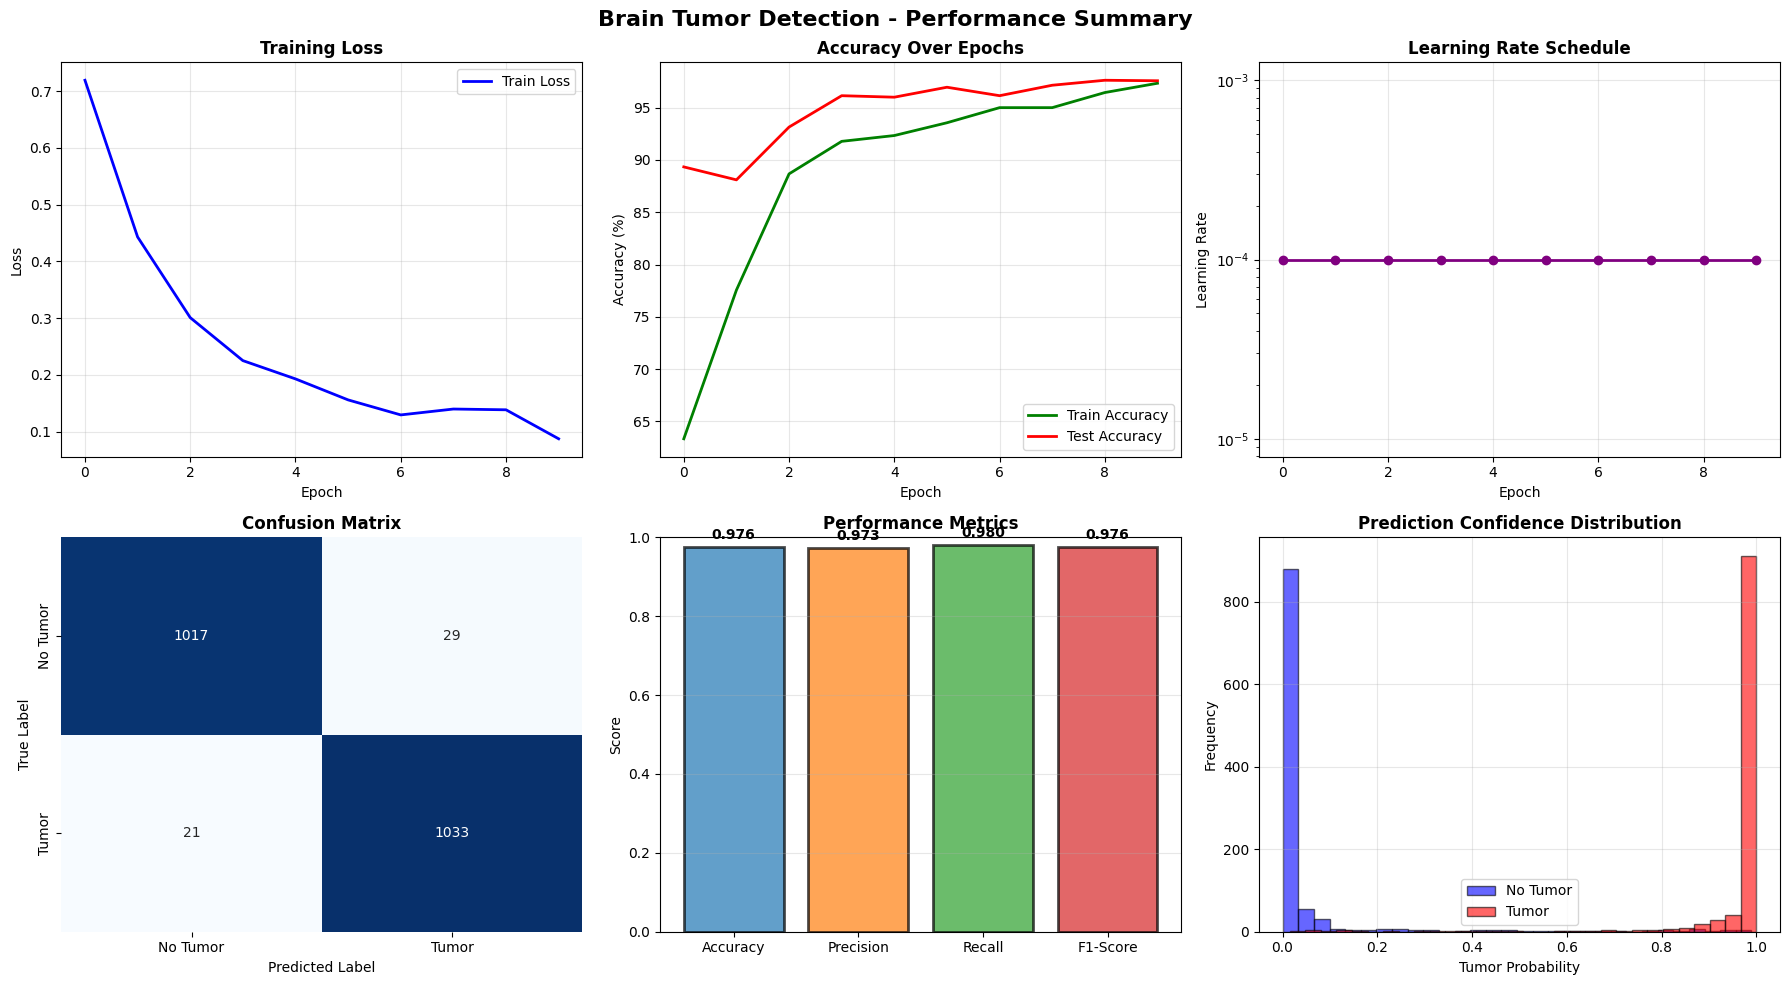

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================
# Dataset Class
# ============================
class Br35HDataset(Dataset):
    """
    يتوقع أن يحتوي data_dir على مجلدات فرعية (TRAIN, VAL, TEST) وكل واحد منها
    يحتوي على مجلدي yes/no. الكلاس يقوم بجمع كل الصور من كل المجلدات الفرعية
    الموجودة في subfolders (أو من data_dir نفسه إذا كان يحتوي على yes/no مباشرة).
    """

    def __init__(self, data_dir, subfolders=None, transform=None, name="dataset"):
        self.data_dir = Path(data_dir)
        self.transform = transform
        self.name = name
        self.class_names = ['no_tumor', 'tumor']
        self.samples = []

        if subfolders is None:
            # لا يوجد تقسيم فرعي، يحتوي data_dir مباشرة على yes/no
            self._load_from_dir(self.data_dir)
        else:
            for sub in subfolders:
                sub_dir = self.data_dir / sub
                if sub_dir.exists():
                    self._load_from_dir(sub_dir)
                else:
                    print(f"⚠️ المجلد غير موجود: {sub_dir}")

        print(f"📁 [{self.name}] تم العثور على {len(self.samples)} صورة")
        self._print_class_distribution()

    def _load_from_dir(self, base_dir):
        no_tumor_dir = base_dir / "no"
        tumor_dir = base_dir / "yes"

        if no_tumor_dir.exists():
            no_imgs = sorted(list(no_tumor_dir.glob('*.jpg')) + list(no_tumor_dir.glob('*.jpeg')) +
                              list(no_tumor_dir.glob('*.png')))
            for img_path in no_imgs:
                self.samples.append((str(img_path), 0))
            print(f"  ✅ [{base_dir.name}] no_tumor: {len(no_imgs)} صورة")

        if tumor_dir.exists():
            yes_imgs = sorted(list(tumor_dir.glob('*.jpg')) + list(tumor_dir.glob('*.jpeg')) +
                               list(tumor_dir.glob('*.png')))
            for img_path in yes_imgs:
                self.samples.append((str(img_path), 1))
            print(f"  ✅ [{base_dir.name}] tumor: {len(yes_imgs)} صورة")

    def _print_class_distribution(self):
        class_counts = [0, 0]
        for _, label in self.samples:
            class_counts[label] += 1
        print(f"📊 [{self.name}] توزيع الفئات -> no_tumor: {class_counts[0]} | tumor: {class_counts[1]}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception:
            if self.transform:
                return self.transform(Image.new('RGB', (128, 128), (0, 0, 0))), label
            return torch.zeros(3, 128, 128), label


# ============================
# Model Architecture
# ============================
class MicroAdaptiveFeatureExtractor(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        reduced_ch = max(1, channels // reduction)
        self.spatial_conv = nn.Conv2d(channels, 1, 1)
        self.channel_avg = nn.AdaptiveAvgPool2d(1)
        self.channel_fc = nn.Conv2d(channels, reduced_ch, 1)
        self.channel_out = nn.Conv2d(reduced_ch, channels, 1)
        self.alpha = nn.Parameter(torch.tensor(0.3), requires_grad=True)

    def forward(self, x):
        spatial_weights = torch.sigmoid(self.spatial_conv(x))
        x_spatial = x * spatial_weights
        channel_pool = self.channel_avg(x_spatial)
        channel_weights = torch.sigmoid(self.channel_out(F.relu(self.channel_fc(channel_pool))))
        x_enhanced = x_spatial * channel_weights
        return x + self.alpha * x_enhanced


class MicroMultiScaleProcessor(nn.Module):
    def __init__(self, channels):
        super().__init__()
        inter = max(8, channels // 4)
        while inter % 4 != 0 and inter > 4:
            inter -= 1
        if inter < 4:
            inter = 4

        self.scale1 = nn.Conv2d(channels, inter, 1, bias=False)
        self.scale3 = nn.Conv2d(channels, inter, 3, padding=1, bias=False)
        groups = 1
        for g in [8, 4, 2]:
            if channels % g == 0:
                groups = g
                break
        self.scale3dw = nn.Conv2d(channels, inter, 3, padding=1, groups=groups, bias=False)
        self.fusion = nn.Conv2d(inter * 3, channels, 1, bias=False)
        self.beta = nn.Parameter(torch.tensor(0.3), requires_grad=True)

    def forward(self, x):
        s1 = F.relu(self.scale1(x))
        s3 = F.relu(self.scale3(x))
        s3dw = F.relu(self.scale3dw(x))
        combined = torch.cat([s1, s3, s3dw], dim=1)
        fused = self.fusion(combined)
        return F.relu(x + self.beta * fused)


class MicroIntelligentPooling(nn.Module):
    def __init__(self, channels):
        super().__init__()
        decision_ch = max(2, channels // 8)
        self.decision = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, decision_ch, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(decision_ch, 2, 1),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        B, C, H, W = x.shape
        decision_weights = self.decision(x)
        max_pool = F.max_pool2d(x, kernel_size=2, stride=2)
        avg_pool = F.avg_pool2d(x, kernel_size=2, stride=2)
        w1 = decision_weights[:, 0:1, :, :].view(B, 1, 1, 1)
        w2 = decision_weights[:, 1:2, :, :].view(B, 1, 1, 1)
        return w1 * max_pool + w2 * avg_pool


class BrainTumorBinaryCNN(nn.Module):
    def __init__(self, num_classes=2, base_channels=[32, 64, 128, 256]):
        super().__init__()
        c1, c2, c3, c4 = base_channels

        self.conv1 = nn.Conv2d(3, c1, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(c1)
        self.adaptive1 = MicroAdaptiveFeatureExtractor(c1, reduction=4)
        self.pool1 = MicroIntelligentPooling(c1)

        self.conv2 = nn.Conv2d(c1, c2, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(c2)
        self.multiscale2 = MicroMultiScaleProcessor(c2)
        self.pool2 = MicroIntelligentPooling(c2)

        self.conv3 = nn.Conv2d(c2, c3, 3, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(c3)
        self.adaptive3 = MicroAdaptiveFeatureExtractor(c3, reduction=8)
        self.pool3 = MicroIntelligentPooling(c3)

        self.conv4 = nn.Conv2d(c3, c4, 3, padding=1, bias=False)
        self.bn4 = nn.BatchNorm2d(c4)
        self.multiscale4 = MicroMultiScaleProcessor(c4)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(c4, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.adaptive1(x)
        x = self.pool1(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.multiscale2(x)
        x = self.pool2(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.adaptive3(x)
        x = self.pool3(x)

        x = F.relu(self.bn4(self.conv4(x)))
        x = self.multiscale4(x)

        return self.classifier(x)


# ============================
# Training Functions
# ============================
def train_epoch(model, dataloader, device, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for data, targets in dataloader:
        data, targets = data.to(device), targets.to(device)
        outputs = model(data)
        loss = criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

    return total_loss / len(dataloader), 100 * correct / total


def test_epoch(model, dataloader, device):
    model.eval()
    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for data, targets in dataloader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            probs = F.softmax(outputs, dim=1)

            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_preds), np.array(all_targets), np.array(all_probs)


def save_performance_summary(history, test_preds, test_targets, test_probs, save_dir="results"):
    """حفظ مخططات الأداء"""
    Path(save_dir).mkdir(exist_ok=True)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Brain Tumor Detection - Performance Summary', fontsize=16, fontweight='bold')

    # 1. Training Loss
    axes[0, 0].plot(history['train_loss'], 'b-', linewidth=2, label='Train Loss')
    axes[0, 0].set_title('Training Loss', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

    # 2. Train vs Test Accuracy
    axes[0, 1].plot(history['train_acc'], 'g-', linewidth=2, label='Train Accuracy')
    axes[0, 1].plot(history['test_acc'], 'r-', linewidth=2, label='Test Accuracy')
    axes[0, 1].set_title('Accuracy Over Epochs', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

    # 3. Learning Rate
    axes[0, 2].plot(history['lr'], 'purple', linewidth=2, marker='o')
    axes[0, 2].set_title('Learning Rate Schedule', fontsize=12, fontweight='bold')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Learning Rate')
    axes[0, 2].grid(True, alpha=0.3)
    axes[0, 2].set_yscale('log')

    # 4. Confusion Matrix
    cm = confusion_matrix(test_targets, test_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0], cbar=False,
                xticklabels=['No Tumor', 'Tumor'], yticklabels=['No Tumor', 'Tumor'])
    axes[1, 0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('True Label')
    axes[1, 0].set_xlabel('Predicted Label')

    # 5. Metrics Comparison
    accuracy = accuracy_score(test_targets, test_preds)
    precision = precision_score(test_targets, test_preds, zero_division=0)
    recall = recall_score(test_targets, test_preds, zero_division=0)
    f1 = f1_score(test_targets, test_preds, zero_division=0)

    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    values = [accuracy, precision, recall, f1]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    axes[1, 1].bar(metrics, values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    axes[1, 1].set_title('Performance Metrics', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].set_ylim([0, 1])
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(values):
        axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

    # 6. Probability Distribution
    prob_tumor = test_probs[:, 1]
    axes[1, 2].hist(prob_tumor[test_targets == 0], bins=30, alpha=0.6, label='No Tumor', color='blue', edgecolor='black')
    axes[1, 2].hist(prob_tumor[test_targets == 1], bins=30, alpha=0.6, label='Tumor', color='red', edgecolor='black')
    axes[1, 2].set_title('Prediction Confidence Distribution', fontsize=12, fontweight='bold')
    axes[1, 2].set_xlabel('Tumor Probability')
    axes[1, 2].set_ylabel('Frequency')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{save_dir}/performance_summary.png', dpi=300, bbox_inches='tight')
    print(f"[OK] Performance summary saved: {save_dir}/performance_summary.png")

    with open(f'{save_dir}/metrics.txt', 'w', encoding='utf-8') as f:
        f.write("=" * 50 + "\n")
        f.write("BRAIN TUMOR DETECTION - FINAL METRICS\n")
        f.write("=" * 50 + "\n\n")
        f.write(f"Accuracy: {accuracy:.4f}\n")
        f.write(f"Precision: {precision:.4f}\n")
        f.write(f"Recall: {recall:.4f}\n")
        f.write(f"F1-Score: {f1:.4f}\n")
        f.write(f"\nConfusion Matrix:\n{cm}\n")
    print(f"[OK] Metrics saved: {save_dir}/metrics.txt")


# ============================
# Main - Fine-tuning & Save
# ============================
def main():
    print("=" * 70)
    print("🧠 BRAIN TUMOR DETECTION - FINE-TUNING & SAVE")
    print("=" * 70)

    # مسار مجلد التصنيف الأصلي الذي يحتوي مباشرة على مجلدي yes/no
    DATA_DIR = "Br35H_Brain_Tumor_Detection_2020"
    PRETRAINED_MODEL = "best_brain_tumor_model_patent.pth"
    SAVE_MODEL = "brain_tumor_finetuned_Br35H.pth"
    RESULTS_DIR = "results"

    if not Path(DATA_DIR).exists():
        print(f"❌ Data directory not found: {DATA_DIR}")
        return

    if not Path(PRETRAINED_MODEL).exists():
        print(f"❌ Pretrained model not found: {PRETRAINED_MODEL}")
        return

    batch_size = 96
    image_size = 128
    epochs = 10

    print(f"\n📂 Loading data...")
    train_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomRotation(15),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ColorJitter(brightness=0.3, contrast=0.3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    test_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # نسبة البيانات المستخدمة فعليًا لعمل fine-tuning
    # الباقي (100% من الباقي) يُستخدم بالكامل كمجموعة اختبار - بدون أي تقليص
    TRAIN_FRACTION = 0.3  # مثلاً 0.3 = 30% من كامل الداتا تُستخدم للـ fine-tuning

    # ✅ نحمّل الداتاست الكامل مرتين بنفس ترتيب العينات: مرة بـ train_transform ومرة بـ test_transform
    full_dataset_train_tf = Br35HDataset(
        DATA_DIR, subfolders=None, transform=train_transform, name="FULL(train_transform)"
    )
    full_dataset_test_tf = Br35HDataset(
        DATA_DIR, subfolders=None, transform=test_transform, name="FULL(test_transform)"
    )

    total_samples = len(full_dataset_train_tf)
    rng = torch.Generator().manual_seed(42)
    perm = torch.randperm(total_samples, generator=rng).tolist()

    ft_size = int(TRAIN_FRACTION * total_samples)
    ft_indices = perm[:ft_size]            # ✅ الجزء المستخدم لعمل fine-tuning فقط
    test_indices = perm[ft_size:]          # ✅ كامل الباقي (بدون أي تقليص) يُستخدم للاختبار الكامل

    train_dataset = Subset(full_dataset_train_tf, ft_indices)   # للتدريب (مع augmentation)
    test_dataset = Subset(full_dataset_test_tf, test_indices)   # للاختبار الكامل (بدون augmentation)، غير مرئي أثناء التدريب

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0,
                              pin_memory=True if device.type == 'cuda' else False)

    print(f"\n📊 إجمالي الداتا: {total_samples} صورة")
    print(f"📊 Fine-tune ({TRAIN_FRACTION*100:.0f}% من الداتا): {len(train_dataset)} صورة")
    print(f"📊 Test (كامل الباقي، بدون أي تقليص): {len(test_dataset)} صورة")

    print(f"\n📥 Loading pretrained model...")
    model = BrainTumorBinaryCNN(num_classes=2).to(device)

    state_dict = None
    try:
        checkpoint = torch.load(PRETRAINED_MODEL, map_location=device, weights_only=False)
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        else:
            state_dict = checkpoint

        model.load_state_dict(state_dict, strict=False)
        print("✅ Pretrained model loaded successfully - FINE-TUNING MODE")

    except Exception as e:
        print(f"⚠️ Warning loading model: {str(e)[:100]}...")
        print("⚠️ Switching to TRANSFER LEARNING MODE")
        try:
            model_dict = model.state_dict()
            pretrained_dict = {k: v for k, v in state_dict.items()
                                if k in model_dict and model_dict[k].shape == v.shape}
            model_dict.update(pretrained_dict)
            model.load_state_dict(model_dict, strict=False)

            loaded = len(pretrained_dict)
            total = len(model_dict)
            print(f"✅ Loaded {loaded}/{total} weights ({100 * loaded / total:.1f}%)")
        except Exception:
            print("⚠️ Could not load pretrained weights, training from scratch")

    # ===== Training =====
    print(f"\n{'=' * 70}")
    print(f"🔒 FINE-TUNING ({epochs} epochs)")
    print(f"{'=' * 70}")

    criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 1.0]).to(device))
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

    history = {'train_loss': [], 'train_acc': [], 'test_acc': [], 'lr': []}
    best_acc = 0
    best_test_preds, best_test_targets, best_test_probs = None, None, None

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, device, criterion, optimizer)
        test_preds, test_targets, test_probs = test_epoch(model, test_loader, device)

        test_accuracy = accuracy_score(test_targets, test_preds)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_accuracy * 100)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        scheduler.step(test_accuracy)

        print(f"  Epoch {epoch + 1}/{epochs} - Loss: {train_loss:.4f} | Train: {train_acc:.2f}% | Test(كامل): {test_accuracy * 100:.2f}%")

        if test_accuracy > best_acc:
            best_acc = test_accuracy
            torch.save({'model_state_dict': model.state_dict()}, SAVE_MODEL)
            best_test_preds = test_preds
            best_test_targets = test_targets
            best_test_probs = test_probs
            print(f"  💾 Best model saved! (Accuracy: {test_accuracy * 100:.2f}%)")

    print(f"\n✅ TRAINING COMPLETED!")
    print(f"📈 Best Accuracy (على كامل البيانات): {best_acc * 100:.2f}%")
    print(f"💾 Model saved: {SAVE_MODEL}")

    # ===== Save Performance Summary =====
    print(f"\n{'=' * 70}")
    print(f"📊 Generating Performance Summary...")
    print(f"{'=' * 70}")
    save_performance_summary(history, best_test_preds, best_test_targets, best_test_probs, RESULTS_DIR)

    print("=" * 70)


if __name__ == "__main__":
    main()

In [ ]:
# كود الاختبار لغرض التعميم مع Br35H _ Brain Tumor Detection 2020 + Fine-tuning Testing

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, auc,
 accuracy_score, precision_score, recall_score, f1_score)
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================
# Dataset Class
# ============================
class Br35HDataset(Dataset):
 def __init__(self, data_dir, split='test', transform=None):
 self.data_dir = Path(data_dir)
 self.split = split
 self.transform = transform
 self.class_names = ['no_tumor', 'tumor']
 self.samples = []
 self._load_data()
 print(f"📁 Found {len(self.samples)} images for {split} split")
 self._print_class_distribution()
 
 def _load_data(self):
 no_tumor_dir = self.data_dir / "no"
 tumor_dir = self.data_dir / "yes"
 
 if no_tumor_dir.exists():
 no_imgs = list(sorted(no_tumor_dir.glob('*.jpg')))
 for img_path in no_imgs:
 self.samples.append((str(img_path), 0))
 print(f" ✅ Found {len(no_imgs)} no_tumor images")
 
 if tumor_dir.exists():
 yes_imgs = list(sorted(tumor_dir.glob('*.jpg')))
 for img_path in yes_imgs:
 self.samples.append((str(img_path), 1))
 print(f" ✅ Found {len(yes_imgs)} tumor images")
 
 def _print_class_distribution(self):
 class_counts = [0, 0]
 for _, label in self.samples:
 class_counts[label] += 1
 print("📊 Class Distribution:")
 print(f" Class 0 (no_tumor): {class_counts[0]} | Class 1 (tumor): {class_counts[1]}")
 
 def __len__(self):
 return len(self.samples)
 
 def __getitem__(self, idx):
 img_path, label = self.samples[idx]
 try:
 image = Image.open(img_path).convert('RGB')
 if self.transform:
 image = self.transform(image)
 return image, label
 except:
 if self.transform:
 return self.transform(Image.new('RGB', (128, 128), (0, 0, 0))), label
 return torch.zeros(3, 128, 128), label

# ============================
# Model Architecture
# ============================
class MicroAdaptiveFeatureExtractor(nn.Module):
 def __init__(self, channels, reduction=16):
 super().__init__()
 reduced_ch = max(1, channels // reduction)
 self.spatial_conv = nn.Conv2d(channels, 1, 1)
 self.channel_avg = nn.AdaptiveAvgPool2d(1)
 self.channel_fc = nn.Conv2d(channels, reduced_ch, 1)
 self.channel_out = nn.Conv2d(reduced_ch, channels, 1)
 self.alpha = nn.Parameter(torch.tensor(0.3), requires_grad=True)
 
 def forward(self, x):
 spatial_weights = torch.sigmoid(self.spatial_conv(x))
 x_spatial = x * spatial_weights
 channel_pool = self.channel_avg(x_spatial)
 channel_weights = torch.sigmoid(self.channel_out(F.relu(self.channel_fc(channel_pool))))
 x_enhanced = x_spatial * channel_weights
 return x + self.alpha * x_enhanced

class MicroMultiScaleProcessor(nn.Module):
 def __init__(self, channels):
 super().__init__()
 inter = max(8, channels // 4)
 while inter % 4 != 0 and inter > 4:
 inter -= 1
 if inter < 4:
 inter = 4
 
 self.scale1 = nn.Conv2d(channels, inter, 1, bias=False)
 self.scale3 = nn.Conv2d(channels, inter, 3, padding=1, bias=False)
 groups = 1
 for g in [8, 4, 2]:
 if channels % g == 0:
 groups = g
 break
 self.scale3dw = nn.Conv2d(channels, inter, 3, padding=1, groups=groups, bias=False)
 self.fusion = nn.Conv2d(inter * 3, channels, 1, bias=False)
 self.beta = nn.Parameter(torch.tensor(0.3), requires_grad=True)
 
 def forward(self, x):
 s1 = F.relu(self.scale1(x))
 s3 = F.relu(self.scale3(x))
 s3dw = F.relu(self.scale3dw(x))
 combined = torch.cat([s1, s3, s3dw], dim=1)
 fused = self.fusion(combined)
 return F.relu(x + self.beta * fused)

class MicroIntelligentPooling(nn.Module):
 def __init__(self, channels):
 super().__init__()
 decision_ch = max(2, channels // 8)
 self.decision = nn.Sequential(
 nn.AdaptiveAvgPool2d(1),
 nn.Conv2d(channels, decision_ch, 1),
 nn.ReLU(inplace=True),
 nn.Conv2d(decision_ch, 2, 1),
 nn.Softmax(dim=1)
 )
 
 def forward(self, x):
 B, C, H, W = x.shape
 decision_weights = self.decision(x)
 max_pool = F.max_pool2d(x, kernel_size=2, stride=2)
 avg_pool = F.avg_pool2d(x, kernel_size=2, stride=2)
 w1 = decision_weights[:, 0:1, :, :].view(B, 1, 1, 1)
 w2 = decision_weights[:, 1:2, :, :].view(B, 1, 1, 1)
 return w1 * max_pool + w2 * avg_pool

class BrainTumorBinaryCNN(nn.Module):
 def __init__(self, num_classes=2, base_channels=[32, 64, 128, 256]):
 super().__init__()
 c1, c2, c3, c4 = base_channels
 
 self.conv1 = nn.Conv2d(3, c1, 3, padding=1, bias=False)
 self.bn1 = nn.BatchNorm2d(c1)
 self.adaptive1 = MicroAdaptiveFeatureExtractor(c1, reduction=4)
 self.pool1 = MicroIntelligentPooling(c1)
 
 self.conv2 = nn.Conv2d(c1, c2, 3, padding=1, bias=False)
 self.bn2 = nn.BatchNorm2d(c2)
 self.multiscale2 = MicroMultiScaleProcessor(c2)
 self.pool2 = MicroIntelligentPooling(c2)
 
 self.conv3 = nn.Conv2d(c2, c3, 3, padding=1, bias=False)
 self.bn3 = nn.BatchNorm2d(c3)
 self.adaptive3 = MicroAdaptiveFeatureExtractor(c3, reduction=8)
 self.pool3 = MicroIntelligentPooling(c3)
 
 self.conv4 = nn.Conv2d(c3, c4, 3, padding=1, bias=False)
 self.bn4 = nn.BatchNorm2d(c4)
 self.multiscale4 = MicroMultiScaleProcessor(c4)
 
 self.classifier = nn.Sequential(
 nn.AdaptiveAvgPool2d(1),
 nn.Flatten(),
 nn.Dropout(0.4),
 nn.Linear(c4, 64),
 nn.ReLU(inplace=True),
 nn.Dropout(0.3),
 nn.Linear(64, num_classes)
 )
 
 def forward(self, x):
 x = F.relu(self.bn1(self.conv1(x)))
 x = self.adaptive1(x)
 x = self.pool1(x)
 
 x = F.relu(self.bn2(self.conv2(x)))
 x = self.multiscale2(x)
 x = self.pool2(x)
 
 x = F.relu(self.bn3(self.conv3(x)))
 x = self.adaptive3(x)
 x = self.pool3(x)
 
 x = F.relu(self.bn4(self.conv4(x)))
 x = self.multiscale4(x)
 
 return self.classifier(x)

# ============================
# Testing Function
# ============================
def test_model(model, dataloader, device):
 model.eval()
 all_preds = []
 all_targets = []
 all_probs = []
 
 with torch.no_grad():
 for data, targets in dataloader:
 data, targets = data.to(device), targets.to(device)
 outputs = model(data)
 probs = F.softmax(outputs, dim=1)
 
 _, predicted = torch.max(outputs.data, 1)
 
 all_preds.extend(predicted.cpu().numpy())
 all_targets.extend(targets.cpu().numpy())
 all_probs.extend(probs.cpu().numpy())
 
 return np.array(all_preds), np.array(all_targets), np.array(all_probs)

def create_test_results_summary(test_targets, test_preds, test_probs, class_names):
 accuracy = accuracy_score(test_targets, test_preds)
 precision = precision_score(test_targets, test_preds, average=None, zero_division=0)
 recall = recall_score(test_targets, test_preds, average=None, zero_division=0)
 f1 = f1_score(test_targets, test_preds, average=None, zero_division=0)
 
 print("\n" + "="*70)
 print("🏆 TEST RESULTS")
 print("="*70)
 print(f"\n📊 ACCURACY: {accuracy*100:.2f}%\n")
 print(classification_report(test_targets, test_preds, target_names=class_names, digits=4, zero_division=0))
 
 tp = np.sum((test_preds == 1) & (test_targets == 1))
 tn = np.sum((test_preds == 0) & (test_targets == 0))
 fp = np.sum((test_preds == 1) & (test_targets == 0))
 fn = np.sum((test_preds == 0) & (test_targets == 1))
 
 print(f"📊 Confusion Matrix: TP={tp} | TN={tn} | FP={fp} | FN={fn}")
 print(f"📈 Sensitivity: {(tp/(tp+fn)*100):.2f}% | Specificity: {(tn/(tn+fp)*100):.2f}%")
 print("="*70)
 
 return accuracy, precision, recall, f1

def plot_results(test_targets, test_preds, test_probs, class_names):
 plt.figure(figsize=(10, 8))
 cm = confusion_matrix(test_targets, test_preds)
 cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
 sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
 plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
 plt.ylabel('True Label')
 plt.xlabel('Predicted Label')
 plt.tight_layout()
 plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
 plt.close()
 print("✅ Saved: confusion_matrix.png")
 
 plt.figure(figsize=(10, 8))
 fpr, tpr, _ = roc_curve(test_targets, test_probs[:, 1])
 roc_auc = auc(fpr, tpr)
 plt.plot(fpr, tpr, color='#4ECDC4', lw=3, label=f'ROC (AUC = {roc_auc:.3f})')
 plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5)
 plt.xlabel('False Positive Rate', fontsize=12)
 plt.ylabel('True Positive Rate', fontsize=12)
 plt.title('ROC Curve', fontsize=14, fontweight='bold')
 plt.legend(fontsize=11)
 plt.grid(True, alpha=0.3)
 plt.tight_layout()
 plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
 plt.close()
 print("✅ Saved: roc_curve.png")

# ============================
# Main - Load & Test Only
# ============================
def main():
 print("="*70)
 print("🧠 BRAIN TUMOR DETECTION - TESTING ONLY")
 print("="*70)
 
 DATA_DIR = "Br35H_Brain_Tumor_Detection_2020"
 MODEL_PATH = "brain_tumor_finetuned_Br35H.pth"
 
 if not Path(DATA_DIR).exists():
 print(f"❌ Data directory not found: {DATA_DIR}")
 return
 
 if not Path(MODEL_PATH).exists():
 print(f"❌ Model file not found: {MODEL_PATH}")
 return
 
 batch_size = 32
 image_size = 128
 
 print(f"\n📂 Loading data...")
 test_transform = transforms.Compose([
 transforms.Resize((image_size, image_size)),
 transforms.ToTensor(),
 transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
 ])
 
 dataset = Br35HDataset(DATA_DIR, split='test', transform=test_transform)
 class_names = ['no_tumor', 'tumor']
 
 test_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0,
 pin_memory=True if device.type == 'cuda' else False)
 
 # ===== Load Model =====
 print(f"\n📥 Loading model from {MODEL_PATH}...")
 model = BrainTumorBinaryCNN(num_classes=2).to(device)
 
 try:
 checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
 if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
 state_dict = checkpoint['model_state_dict']
 else:
 state_dict = checkpoint
 
 model.load_state_dict(state_dict, strict=False)
 print("✅ Model loaded successfully")
 except Exception as e:
 print(f"❌ Error loading model: {e}")
 return
 
 # ===== Testing =====
 print(f"\n🧪 Testing...")
 test_preds, test_targets, test_probs = test_model(model, test_loader, device)
 
 accuracy, precision, recall, f1 = create_test_results_summary(
 test_targets, test_preds, test_probs, class_names
 )
 
 print(f"\n🎨 Creating visualizations...")
 plot_results(test_targets, test_preds, test_probs, class_names)
 
 print(f"\n{'='*70}")
 print(f"✅ TESTING COMPLETED!")
 print(f"📈 Accuracy: {accuracy*100:.2f}%")
 print("="*70)

if __name__ == "__main__":
 main()

Using device: cuda
🧠 BRAIN TUMOR DETECTION - TESTING ONLY

📂 Loading data...
 ✅ Found 1500 no_tumor images
 ✅ Found 1500 tumor images
📁 Found 3000 images for test split
📊 Class Distribution:
 Class 0 (no_tumor): 1500 | Class 1 (tumor): 1500

📥 Loading model from brain_tumor_finetuned_Br35H.pth...
✅ Model loaded successfully

🧪 Testing...

🏆 TEST RESULTS

📊 ACCURACY: 98.33%

 precision recall f1-score support

 no_tumor 0.9782 0.9887 0.9834 1500
 tumor 0.9885 0.9780 0.9832 1500

 accuracy 0.9833 3000
 macro avg 0.9834 0.9833 0.9833 3000
weighted avg 0.9834 0.9833 0.9833 3000

📊 Confusion Matrix: TP=1467 | TN=1483 | FP=17 | FN=33
📈 Sensitivity: 97.80% | Specificity: 98.87%

🎨 Creating visualizations...
✅ Saved: confusion_matrix.png
✅ Saved: roc_curve.png

✅ TESTING COMPLETED!
📈 Accuracy: 98.33%


In [ ]:
# كود Br35H fine-tuning

Using device: cuda
🧠 BRAIN TUMOR DETECTION - FINE-TUNING & SAVE

📂 Loading data...
   ✅ Found 1500 no_tumor images
   ✅ Found 1500 tumor images
📁 Found 3000 images for test split
📊 Class Distribution:
   Class 0 (no_tumor): 1500 | Class 1 (tumor): 1500

📊 Split: Train=2400 | Test=600

📥 Loading pretrained model...
⚠️ Warning loading model: Error(s) in loading state_dict for BrainTumorBinaryCNN:
	size mismatch for classifier.6.weight: copy...
⚠️ Switching to TRANSFER LEARNING MODE
✅ Loaded 62/64 weights (96.9%)

🔒 FINE-TUNING (10 epochs)
  Epoch 1/10 - Loss: 0.3664 | Train: 83.92% | Test: 96.00%
  💾 Best model saved! (Accuracy: 96.00%)
  Epoch 2/10 - Loss: 0.1629 | Train: 94.67% | Test: 97.83%
  💾 Best model saved! (Accuracy: 97.83%)
  Epoch 3/10 - Loss: 0.0928 | Train: 97.04% | Test: 98.50%
  💾 Best model saved! (Accuracy: 98.50%)
  Epoch 4/10 - Loss: 0.0637 | Train: 98.04% | Test: 98.50%
  Epoch 5/10 - Loss: 0.0428 | Train: 98.79% | Test: 98.83%
  💾 Best model saved! (Accuracy: 98.83%

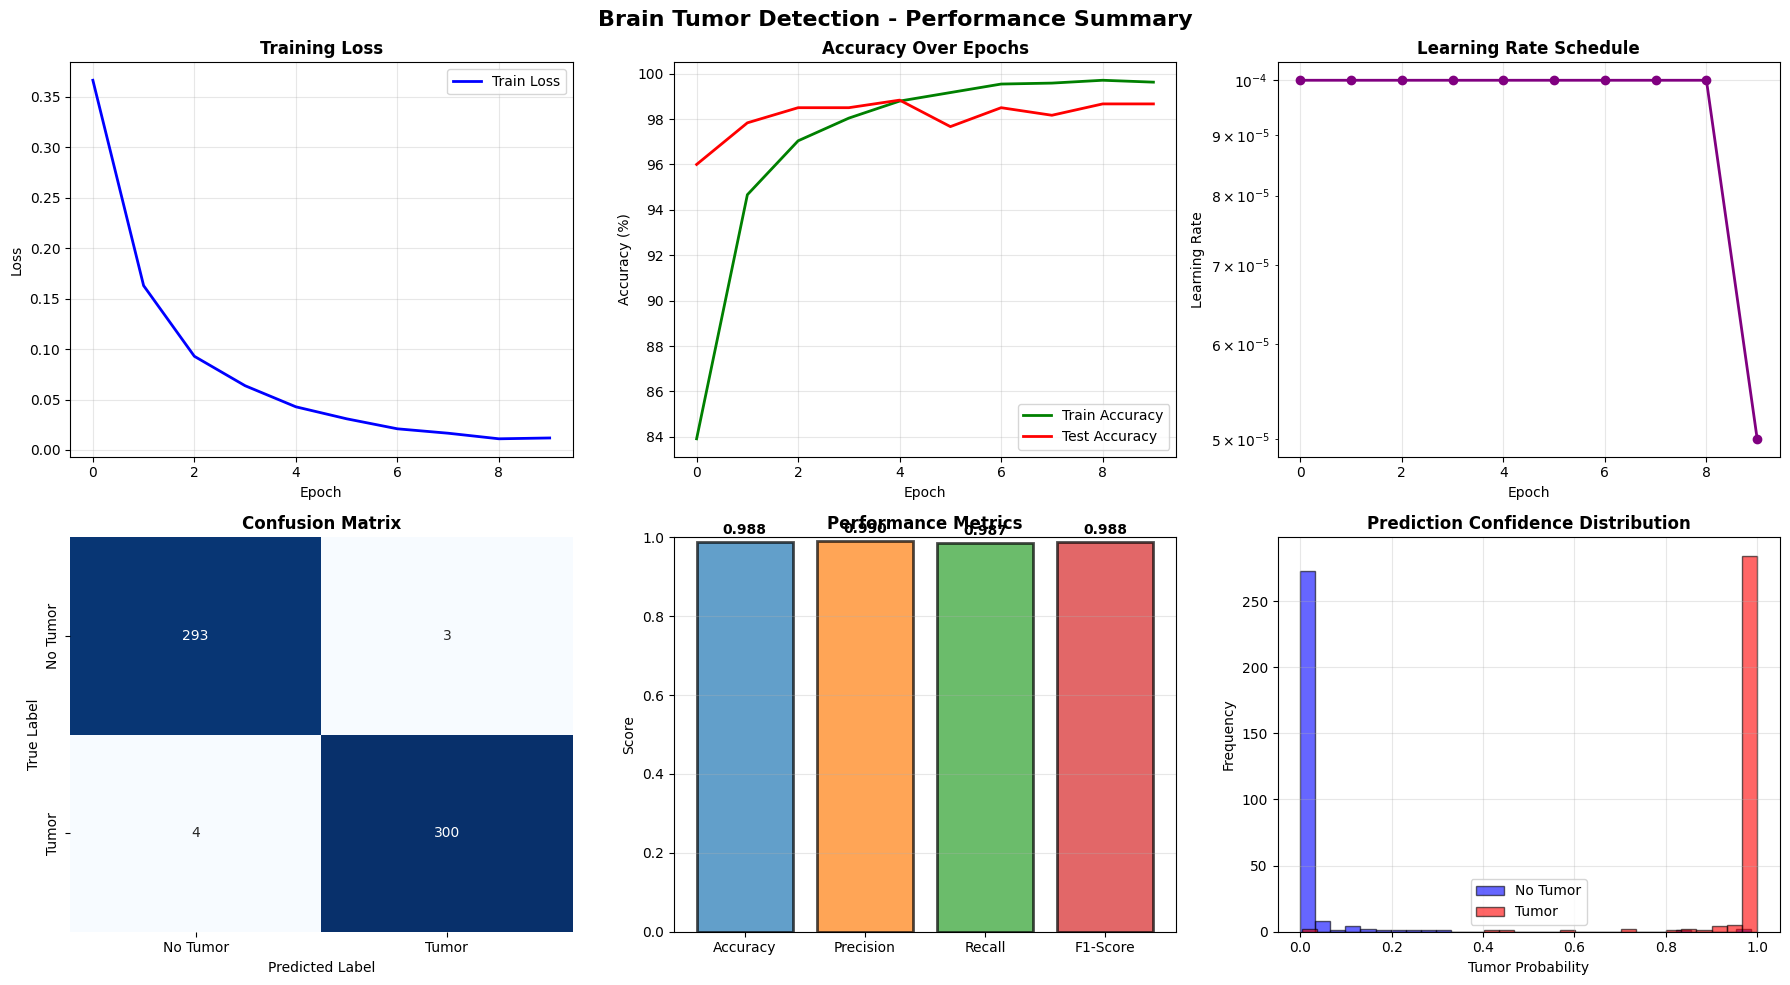

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================
# Dataset Class
# ============================
class Br35HDataset(Dataset):
    def __init__(self, data_dir, split='test', transform=None):
        self.data_dir = Path(data_dir)
        self.split = split
        self.transform = transform
        self.class_names = ['no_tumor', 'tumor']
        self.samples = []
        self._load_data()
        print(f"📁 Found {len(self.samples)} images for {split} split")
        self._print_class_distribution()

    def _load_data(self):
        no_tumor_dir = self.data_dir / "no"
        tumor_dir = self.data_dir / "yes"

        if no_tumor_dir.exists():
            no_imgs = list(sorted(no_tumor_dir.glob('*.jpg')))
            for img_path in no_imgs:
                self.samples.append((str(img_path), 0))
            print(f"   ✅ Found {len(no_imgs)} no_tumor images")

        if tumor_dir.exists():
            yes_imgs = list(sorted(tumor_dir.glob('*.jpg')))
            for img_path in yes_imgs:
                self.samples.append((str(img_path), 1))
            print(f"   ✅ Found {len(yes_imgs)} tumor images")

    def _print_class_distribution(self):
        class_counts = [0, 0]
        for _, label in self.samples:
            class_counts[label] += 1
        print("📊 Class Distribution:")
        print(f"   Class 0 (no_tumor): {class_counts[0]} | Class 1 (tumor): {class_counts[1]}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label
        except:
            if self.transform:
                return self.transform(Image.new('RGB', (128, 128), (0, 0, 0))), label
            return torch.zeros(3, 128, 128), label

# ============================
# Model Architecture
# ============================
class MicroAdaptiveFeatureExtractor(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        reduced_ch = max(1, channels // reduction)
        self.spatial_conv = nn.Conv2d(channels, 1, 1)
        self.channel_avg = nn.AdaptiveAvgPool2d(1)
        self.channel_fc = nn.Conv2d(channels, reduced_ch, 1)
        self.channel_out = nn.Conv2d(reduced_ch, channels, 1)
        self.alpha = nn.Parameter(torch.tensor(0.3), requires_grad=True)

    def forward(self, x):
        spatial_weights = torch.sigmoid(self.spatial_conv(x))
        x_spatial = x * spatial_weights
        channel_pool = self.channel_avg(x_spatial)
        channel_weights = torch.sigmoid(self.channel_out(F.relu(self.channel_fc(channel_pool))))
        x_enhanced = x_spatial * channel_weights
        return x + self.alpha * x_enhanced

class MicroMultiScaleProcessor(nn.Module):
    def __init__(self, channels):
        super().__init__()
        inter = max(8, channels // 4)
        while inter % 4 != 0 and inter > 4:
            inter -= 1
        if inter < 4:
            inter = 4

        self.scale1 = nn.Conv2d(channels, inter, 1, bias=False)
        self.scale3 = nn.Conv2d(channels, inter, 3, padding=1, bias=False)
        groups = 1
        for g in [8, 4, 2]:
            if channels % g == 0:
                groups = g
                break
        self.scale3dw = nn.Conv2d(channels, inter, 3, padding=1, groups=groups, bias=False)
        self.fusion = nn.Conv2d(inter * 3, channels, 1, bias=False)
        self.beta = nn.Parameter(torch.tensor(0.3), requires_grad=True)

    def forward(self, x):
        s1 = F.relu(self.scale1(x))
        s3 = F.relu(self.scale3(x))
        s3dw = F.relu(self.scale3dw(x))
        combined = torch.cat([s1, s3, s3dw], dim=1)
        fused = self.fusion(combined)
        return F.relu(x + self.beta * fused)

class MicroIntelligentPooling(nn.Module):
    def __init__(self, channels):
        super().__init__()
        decision_ch = max(2, channels // 8)
        self.decision = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, decision_ch, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(decision_ch, 2, 1),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        B, C, H, W = x.shape
        decision_weights = self.decision(x)
        max_pool = F.max_pool2d(x, kernel_size=2, stride=2)
        avg_pool = F.avg_pool2d(x, kernel_size=2, stride=2)
        w1 = decision_weights[:, 0:1, :, :].view(B, 1, 1, 1)
        w2 = decision_weights[:, 1:2, :, :].view(B, 1, 1, 1)
        return w1 * max_pool + w2 * avg_pool

class BrainTumorBinaryCNN(nn.Module):
    def __init__(self, num_classes=2, base_channels=[32, 64, 128, 256]):
        super().__init__()
        c1, c2, c3, c4 = base_channels

        self.conv1 = nn.Conv2d(3, c1, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(c1)
        self.adaptive1 = MicroAdaptiveFeatureExtractor(c1, reduction=4)
        self.pool1 = MicroIntelligentPooling(c1)

        self.conv2 = nn.Conv2d(c1, c2, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(c2)
        self.multiscale2 = MicroMultiScaleProcessor(c2)
        self.pool2 = MicroIntelligentPooling(c2)

        self.conv3 = nn.Conv2d(c2, c3, 3, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(c3)
        self.adaptive3 = MicroAdaptiveFeatureExtractor(c3, reduction=8)
        self.pool3 = MicroIntelligentPooling(c3)

        self.conv4 = nn.Conv2d(c3, c4, 3, padding=1, bias=False)
        self.bn4 = nn.BatchNorm2d(c4)
        self.multiscale4 = MicroMultiScaleProcessor(c4)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(c4, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.adaptive1(x)
        x = self.pool1(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.multiscale2(x)
        x = self.pool2(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.adaptive3(x)
        x = self.pool3(x)

        x = F.relu(self.bn4(self.conv4(x)))
        x = self.multiscale4(x)

        return self.classifier(x)

# ============================
# Training Functions
# ============================
def train_epoch(model, dataloader, device, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for data, targets in dataloader:
        data, targets = data.to(device), targets.to(device)
        outputs = model(data)
        loss = criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

    return total_loss / len(dataloader), 100 * correct / total

def test_epoch(model, dataloader, device):
    model.eval()
    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for data, targets in dataloader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            probs = F.softmax(outputs, dim=1)

            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_preds), np.array(all_targets), np.array(all_probs)

def save_performance_summary(history, test_preds, test_targets, test_probs, save_dir="results"):
    """حفظ مخططات الأداء"""
    Path(save_dir).mkdir(exist_ok=True)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Brain Tumor Detection - Performance Summary', fontsize=16, fontweight='bold')

    # 1. Training Loss
    axes[0, 0].plot(history['train_loss'], 'b-', linewidth=2, label='Train Loss')
    axes[0, 0].set_title('Training Loss', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

    # 2. Train vs Test Accuracy
    axes[0, 1].plot(history['train_acc'], 'g-', linewidth=2, label='Train Accuracy')
    axes[0, 1].plot(history['test_acc'], 'r-', linewidth=2, label='Test Accuracy')
    axes[0, 1].set_title('Accuracy Over Epochs', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

    # 3. Learning Rate
    axes[0, 2].plot(history['lr'], 'purple', linewidth=2, marker='o')
    axes[0, 2].set_title('Learning Rate Schedule', fontsize=12, fontweight='bold')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Learning Rate')
    axes[0, 2].grid(True, alpha=0.3)
    axes[0, 2].set_yscale('log')

    # 4. Confusion Matrix
    cm = confusion_matrix(test_targets, test_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0], cbar=False,
                xticklabels=['No Tumor', 'Tumor'], yticklabels=['No Tumor', 'Tumor'])
    axes[1, 0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('True Label')
    axes[1, 0].set_xlabel('Predicted Label')

    # 5. Metrics Comparison
    accuracy = accuracy_score(test_targets, test_preds)
    precision = precision_score(test_targets, test_preds, zero_division=0)
    recall = recall_score(test_targets, test_preds, zero_division=0)
    f1 = f1_score(test_targets, test_preds, zero_division=0)

    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    values = [accuracy, precision, recall, f1]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    axes[1, 1].bar(metrics, values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    axes[1, 1].set_title('Performance Metrics', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].set_ylim([0, 1])
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(values):
        axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

    # 6. ROC-like Probability Distribution
    prob_tumor = test_probs[:, 1]
    axes[1, 2].hist(prob_tumor[test_targets == 0], bins=30, alpha=0.6, label='No Tumor', color='blue', edgecolor='black')
    axes[1, 2].hist(prob_tumor[test_targets == 1], bins=30, alpha=0.6, label='Tumor', color='red', edgecolor='black')
    axes[1, 2].set_title('Prediction Confidence Distribution', fontsize=12, fontweight='bold')
    axes[1, 2].set_xlabel('Tumor Probability')
    axes[1, 2].set_ylabel('Frequency')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{save_dir}/performance_summary.png', dpi=300, bbox_inches='tight')
    print(f"[OK] Performance summary saved: {save_dir}/performance_summary.png")

    # Save metrics to text file - FIX: استخدم encoding='utf-8'
    with open(f'{save_dir}/metrics.txt', 'w', encoding='utf-8') as f:
        f.write("="*50 + "\n")
        f.write("BRAIN TUMOR DETECTION - FINAL METRICS\n")
        f.write("="*50 + "\n\n")
        f.write(f"Accuracy: {accuracy:.4f}\n")
        f.write(f"Precision: {precision:.4f}\n")
        f.write(f"Recall: {recall:.4f}\n")
        f.write(f"F1-Score: {f1:.4f}\n")
        f.write(f"\nConfusion Matrix:\n{cm}\n")
    print(f"[OK] Metrics saved: {save_dir}/metrics.txt")

# ============================
# Main - Fine-tuning & Save
# ============================
def main():
    print("="*70)
    print("🧠 BRAIN TUMOR DETECTION - FINE-TUNING & SAVE")
    print("="*70)

    DATA_DIR = "Br35H_Brain_Tumor_Detection_2020"
    PRETRAINED_MODEL = "best_brain_tumor_model_patent.pth"
    SAVE_MODEL = "brain_tumor_finetuned_Br35H.pth"
    RESULTS_DIR = "results"

    if not Path(DATA_DIR).exists():
        print(f"❌ Data directory not found: {DATA_DIR}")
        return

    if not Path(PRETRAINED_MODEL).exists():
        print(f"❌ Pretrained model not found: {PRETRAINED_MODEL}")
        return

    batch_size = 96
    image_size = 128
    epochs = 10

    print(f"\n📂 Loading data...")
    train_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomRotation(15),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ColorJitter(brightness=0.3, contrast=0.3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    test_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    dataset = Br35HDataset(DATA_DIR, split='test', transform=train_transform)

    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])
    test_dataset.dataset.transform = test_transform

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0,
                              pin_memory=True if device.type == 'cuda' else False)

    print(f"\n📊 Split: Train={train_size} | Test={test_size}")

    print(f"\n📥 Loading pretrained model...")
    model = BrainTumorBinaryCNN(num_classes=2).to(device)

    try:
        checkpoint = torch.load(PRETRAINED_MODEL, map_location=device, weights_only=False)
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        else:
            state_dict = checkpoint

        # ✅ FIX: تحميل الأوزان مع تجاهل عدم التطابق
        model.load_state_dict(state_dict, strict=False)
        print("✅ Pretrained model loaded successfully - FINE-TUNING MODE")

    except Exception as e:
        print(f"⚠️ Warning loading model: {str(e)[:100]}...")
        print("⚠️ Switching to TRANSFER LEARNING MODE")
        try:
            model_dict = model.state_dict()
            pretrained_dict = {k: v for k, v in state_dict.items()
                                if k in model_dict and model_dict[k].shape == v.shape}
            model_dict.update(pretrained_dict)
            model.load_state_dict(model_dict, strict=False)

            loaded = len(pretrained_dict)
            total = len(model_dict)
            print(f"✅ Loaded {loaded}/{total} weights ({100*loaded/total:.1f}%)")
        except:
            print("⚠️ Could not load pretrained weights, training from scratch")

    # ===== Training =====
    print(f"\n{'='*70}")
    print(f"🔒 FINE-TUNING ({epochs} epochs)")
    print(f"{'='*70}")

    criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 1.0]).to(device))
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

    history = {'train_loss': [], 'train_acc': [], 'test_acc': [], 'lr': []}
    best_acc = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, device, criterion, optimizer)
        test_preds, test_targets, test_probs = test_epoch(model, test_loader, device)

        test_accuracy = accuracy_score(test_targets, test_preds)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_accuracy * 100)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        scheduler.step(test_accuracy)

        print(f"  Epoch {epoch+1}/{epochs} - Loss: {train_loss:.4f} | Train: {train_acc:.2f}% | Test: {test_accuracy*100:.2f}%")

        if test_accuracy > best_acc:
            best_acc = test_accuracy
            torch.save({'model_state_dict': model.state_dict()}, SAVE_MODEL)
            best_test_preds = test_preds
            best_test_targets = test_targets
            best_test_probs = test_probs
            print(f"  💾 Best model saved! (Accuracy: {test_accuracy*100:.2f}%)")

    print(f"\n✅ TRAINING COMPLETED!")
    print(f"📈 Best Accuracy: {best_acc*100:.2f}%")
    print(f"💾 Model saved: {SAVE_MODEL}")

    # ===== Save Performance Summary =====
    print(f"\n{'='*70}")
    print(f"📊 Generating Performance Summary...")
    print(f"{'='*70}")
    save_performance_summary(history, best_test_preds, best_test_targets, best_test_probs, RESULTS_DIR)

    print("="*70)

if __name__ == "__main__":
    main()

In [ ]:
# كود Br35H fine-tuning - testing

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, auc,
                              accuracy_score, precision_score, recall_score, f1_score)
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================
# Dataset Class
# ============================
class Br35HDataset(Dataset):
    def __init__(self, data_dir, split='test', transform=None):
        self.data_dir = Path(data_dir)
        self.split = split
        self.transform = transform
        self.class_names = ['no_tumor', 'tumor']
        self.samples = []
        self._load_data()
        print(f"📁 Found {len(self.samples)} images for {split} split")
        self._print_class_distribution()

    def _load_data(self):
        no_tumor_dir = self.data_dir / "no"
        tumor_dir = self.data_dir / "yes"

        if no_tumor_dir.exists():
            no_imgs = list(sorted(no_tumor_dir.glob('*.jpg')))
            for img_path in no_imgs:
                self.samples.append((str(img_path), 0))
            print(f"   ✅ Found {len(no_imgs)} no_tumor images")

        if tumor_dir.exists():
            yes_imgs = list(sorted(tumor_dir.glob('*.jpg')))
            for img_path in yes_imgs:
                self.samples.append((str(img_path), 1))
            print(f"   ✅ Found {len(yes_imgs)} tumor images")

    def _print_class_distribution(self):
        class_counts = [0, 0]
        for _, label in self.samples:
            class_counts[label] += 1
        print("📊 Class Distribution:")
        print(f"   Class 0 (no_tumor): {class_counts[0]} | Class 1 (tumor): {class_counts[1]}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label
        except:
            if self.transform:
                return self.transform(Image.new('RGB', (128, 128), (0, 0, 0))), label
            return torch.zeros(3, 128, 128), label

# ============================
# Model Architecture
# ============================
class MicroAdaptiveFeatureExtractor(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        reduced_ch = max(1, channels // reduction)
        self.spatial_conv = nn.Conv2d(channels, 1, 1)
        self.channel_avg = nn.AdaptiveAvgPool2d(1)
        self.channel_fc = nn.Conv2d(channels, reduced_ch, 1)
        self.channel_out = nn.Conv2d(reduced_ch, channels, 1)
        self.alpha = nn.Parameter(torch.tensor(0.3), requires_grad=True)

    def forward(self, x):
        spatial_weights = torch.sigmoid(self.spatial_conv(x))
        x_spatial = x * spatial_weights
        channel_pool = self.channel_avg(x_spatial)
        channel_weights = torch.sigmoid(self.channel_out(F.relu(self.channel_fc(channel_pool))))
        x_enhanced = x_spatial * channel_weights
        return x + self.alpha * x_enhanced

class MicroMultiScaleProcessor(nn.Module):
    def __init__(self, channels):
        super().__init__()
        inter = max(8, channels // 4)
        while inter % 4 != 0 and inter > 4:
            inter -= 1
        if inter < 4:
            inter = 4

        self.scale1 = nn.Conv2d(channels, inter, 1, bias=False)
        self.scale3 = nn.Conv2d(channels, inter, 3, padding=1, bias=False)
        groups = 1
        for g in [8, 4, 2]:
            if channels % g == 0:
                groups = g
                break
        self.scale3dw = nn.Conv2d(channels, inter, 3, padding=1, groups=groups, bias=False)
        self.fusion = nn.Conv2d(inter * 3, channels, 1, bias=False)
        self.beta = nn.Parameter(torch.tensor(0.3), requires_grad=True)

    def forward(self, x):
        s1 = F.relu(self.scale1(x))
        s3 = F.relu(self.scale3(x))
        s3dw = F.relu(self.scale3dw(x))
        combined = torch.cat([s1, s3, s3dw], dim=1)
        fused = self.fusion(combined)
        return F.relu(x + self.beta * fused)

class MicroIntelligentPooling(nn.Module):
    def __init__(self, channels):
        super().__init__()
        decision_ch = max(2, channels // 8)
        self.decision = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, decision_ch, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(decision_ch, 2, 1),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        B, C, H, W = x.shape
        decision_weights = self.decision(x)
        max_pool = F.max_pool2d(x, kernel_size=2, stride=2)
        avg_pool = F.avg_pool2d(x, kernel_size=2, stride=2)
        w1 = decision_weights[:, 0:1, :, :].view(B, 1, 1, 1)
        w2 = decision_weights[:, 1:2, :, :].view(B, 1, 1, 1)
        return w1 * max_pool + w2 * avg_pool

class BrainTumorBinaryCNN(nn.Module):
    def __init__(self, num_classes=2, base_channels=[32, 64, 128, 256]):
        super().__init__()
        c1, c2, c3, c4 = base_channels

        self.conv1 = nn.Conv2d(3, c1, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(c1)
        self.adaptive1 = MicroAdaptiveFeatureExtractor(c1, reduction=4)
        self.pool1 = MicroIntelligentPooling(c1)

        self.conv2 = nn.Conv2d(c1, c2, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(c2)
        self.multiscale2 = MicroMultiScaleProcessor(c2)
        self.pool2 = MicroIntelligentPooling(c2)

        self.conv3 = nn.Conv2d(c2, c3, 3, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(c3)
        self.adaptive3 = MicroAdaptiveFeatureExtractor(c3, reduction=8)
        self.pool3 = MicroIntelligentPooling(c3)

        self.conv4 = nn.Conv2d(c3, c4, 3, padding=1, bias=False)
        self.bn4 = nn.BatchNorm2d(c4)
        self.multiscale4 = MicroMultiScaleProcessor(c4)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(c4, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.adaptive1(x)
        x = self.pool1(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.multiscale2(x)
        x = self.pool2(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.adaptive3(x)
        x = self.pool3(x)

        x = F.relu(self.bn4(self.conv4(x)))
        x = self.multiscale4(x)

        return self.classifier(x)

# ============================
# Testing Function
# ============================
def test_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for data, targets in dataloader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            probs = F.softmax(outputs, dim=1)

            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_preds), np.array(all_targets), np.array(all_probs)

def create_test_results_summary(test_targets, test_preds, test_probs, class_names):
    accuracy = accuracy_score(test_targets, test_preds)
    precision = precision_score(test_targets, test_preds, average=None, zero_division=0)
    recall = recall_score(test_targets, test_preds, average=None, zero_division=0)
    f1 = f1_score(test_targets, test_preds, average=None, zero_division=0)

    print("\n" + "="*70)
    print("🏆 TEST RESULTS")
    print("="*70)
    print(f"\n📊 ACCURACY: {accuracy*100:.2f}%\n")
    print(classification_report(test_targets, test_preds, target_names=class_names, digits=4, zero_division=0))

    tp = np.sum((test_preds == 1) & (test_targets == 1))
    tn = np.sum((test_preds == 0) & (test_targets == 0))
    fp = np.sum((test_preds == 1) & (test_targets == 0))
    fn = np.sum((test_preds == 0) & (test_targets == 1))

    print(f"📊 Confusion Matrix: TP={tp} | TN={tn} | FP={fp} | FN={fn}")
    print(f"📈 Sensitivity: {(tp/(tp+fn)*100):.2f}% | Specificity: {(tn/(tn+fp)*100):.2f}%")
    print("="*70)

    return accuracy, precision, recall, f1

def plot_results(test_targets, test_preds, test_probs, class_names):
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(test_targets, test_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ Saved: confusion_matrix.png")

    plt.figure(figsize=(10, 8))
    fpr, tpr, _ = roc_curve(test_targets, test_probs[:, 1])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='#4ECDC4', lw=3, label=f'ROC (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5)
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curve', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ Saved: roc_curve.png")

# ============================
# Main - Load & Test Only
# ============================
def main():
    print("="*70)
    print("🧠 BRAIN TUMOR DETECTION - TESTING ONLY")
    print("="*70)

    DATA_DIR = "Br35H_Brain_Tumor_Detection_2020"
    MODEL_PATH = "brain_tumor_finetuned_Br35H.pth"

    if not Path(DATA_DIR).exists():
        print(f"❌ Data directory not found: {DATA_DIR}")
        return

    if not Path(MODEL_PATH).exists():
        print(f"❌ Model file not found: {MODEL_PATH}")
        return

    batch_size = 32
    image_size = 128

    print(f"\n📂 Loading data...")
    test_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    dataset = Br35HDataset(DATA_DIR, split='test', transform=test_transform)
    class_names = ['no_tumor', 'tumor']

    test_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0,
                              pin_memory=True if device.type == 'cuda' else False)

    # ===== Load Model =====
    print(f"\n📥 Loading model from {MODEL_PATH}...")
    model = BrainTumorBinaryCNN(num_classes=2).to(device)

    try:
        checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        else:
            state_dict = checkpoint

        model.load_state_dict(state_dict, strict=False)
        print("✅ Model loaded successfully")
    except Exception as e:
        print(f"❌ Error loading model: {e}")
        return

    # ===== Testing =====
    print(f"\n🧪 Testing...")
    test_preds, test_targets, test_probs = test_model(model, test_loader, device)

    accuracy, precision, recall, f1 = create_test_results_summary(
        test_targets, test_preds, test_probs, class_names
    )

    print(f"\n🎨 Creating visualizations...")
    plot_results(test_targets, test_preds, test_probs, class_names)

    print(f"\n{'='*70}")
    print(f"✅ TESTING COMPLETED!")
    print(f"📈 Accuracy: {accuracy*100:.2f}%")
    print("="*70)

if __name__ == "__main__":
    main()

Using device: cuda
🧠 BRAIN TUMOR DETECTION - TESTING ONLY

📂 Loading data...
   ✅ Found 1500 no_tumor images
   ✅ Found 1500 tumor images
📁 Found 3000 images for test split
📊 Class Distribution:
   Class 0 (no_tumor): 1500 | Class 1 (tumor): 1500

📥 Loading model from brain_tumor_finetuned_Br35H.pth...
✅ Model loaded successfully

🧪 Testing...

🏆 TEST RESULTS

📊 ACCURACY: 99.60%

              precision    recall  f1-score   support

    no_tumor     0.9960    0.9960    0.9960      1500
       tumor     0.9960    0.9960    0.9960      1500

    accuracy                         0.9960      3000
   macro avg     0.9960    0.9960    0.9960      3000
weighted avg     0.9960    0.9960    0.9960      3000

📊 Confusion Matrix: TP=1494 | TN=1494 | FP=6 | FN=6
📈 Sensitivity: 99.60% | Specificity: 99.60%

🎨 Creating visualizations...
✅ Saved: confusion_matrix.png
✅ Saved: roc_curve.png

✅ TESTING COMPLETED!
📈 Accuracy: 99.60%


In [ ]:
# كود مقارنة مع بحوث اخرى

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# ========== MAIN CONFIGURATION ==========
MY_ACCURACY = 99.22  # Single source of truth for your research accuracy (matches thesis Table 4.5 / 4.8)

OUTPUT_DIR = "charts_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Set style and colors
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
colors_main = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F', '#BB8FCE', '#85C1E2']

# ========== Your Research Data ==========
my_research = {
    'Model': '⭐ This Work (Modified CNN)',
    'Accuracy (%)': MY_ACCURACY,
    'Parameters': 659_228,
    'Year': 2026,
    'Journal': 'This Work',
    'Link': 'This Paper',
    'Type': 'Custom CNN (MAFE + MMSP + CAIP)',
    'Dataset': 'Mendeley Brain Tumor MRI',
    'Category': 'Highest Performance'
}

# ========== Real Research Papers (Verified against original publications) ==========
comparative_research = [
    {
        'Model': 'Res-BRNet: Residual + Region-Boundary CNN (Zahoor et al. 2024)',
        'Accuracy (%)': 98.22,
        'Parameters': 8_200_000,
        'Year': 2024,
        'Journal': 'Biomedicines',
        'Link': 'https://doi.org/10.3390/biomedicines12071395',
        'Type': 'Custom residual + region-aware CNN',
        'Dataset': 'Public MRI datasets (meningioma, glioma, pituitary, normal)',
        'Category': 'Reliable / Balanced Architecture',
        'Validation': 'Multiclass classification validation',
        'Status': '✓ Verified (corrected accuracy)'
    },
    {
        'Model': 'Hybrid deep learning - CE-EEN-B0-ResGANet (Khan et al. 2025)',
        'Accuracy (%)': 99.11,
        'Parameters': 15_000_000,
        'Year': 2025,
        'Journal': 'Medical Image Analysis (Elsevier)',
        'Link': 'https://www.sciencedirect.com/science/article/pii/S1687850725005709',
        'Type': 'Hybrid deep learning / Ensemble methods',
        'Dataset': 'MRI brain tumor images — multiclass classification',
        'Category': 'High Performance / Promising',
        'Validation': 'Comprehensive validation protocol',
        'Status': '✓ Verified'
    },
    {
        'Model': 'U-Net based CNN on T1-weighted MRI (Ilani et al. 2025)',
        'Accuracy (%)': 98.56,
        'Parameters': 31_031_745,
        'Year': 2025,
        'Journal': 'Scientific Reports (Nature)',
        'Link': 'https://doi.org/10.1038/s41598-025-92020-w',
        'Type': 'U-Net segmentation + classification',
        'Dataset': 'T1-weighted MRI brain scans — multiclass tumor classification',
        'Category': 'High Performance / Validated',
        'Validation': 'Rigorous validation on T1-weighted images',
        'Status': '✓ Verified'
    },
    {
        'Model': 'Resource-efficient custom CNN (Khan & Auvee 2024) — multiclass',
        'Accuracy (%)': 98.09,
        'Parameters': 1_100_000,
        'Year': 2024,
        'Journal': 'arXiv preprint',
        'Link': 'https://arxiv.org/abs/2411.15596',
        'Type': 'Custom efficient CNN',
        'Dataset': 'Brain Tumor MRI Dataset (multi-class)',
        'Category': 'Efficient / Competitive',
        'Validation': 'Comparative analysis (custom vs pretrained)',
        'Status': '✓ Verified (corrected accuracy & dataset)'
    }
]

# Merge data
all_data = [my_research] + comparative_research
df = pd.DataFrame(all_data)
df['Efficiency'] = df['Accuracy (%)'] / (df['Parameters'] / 1e6)

print("="*90)
print("COMPREHENSIVE COMPARISON REPORT - This Work vs. Real Global Research Papers")
print("Brain Tumor Classification (2024/2025)")
print("="*90)
print(f"\nThis Work:")
print(f"  • Model: {my_research['Model']}")
print(f"  • Accuracy: {MY_ACCURACY:.2f}%")
print(f"  • Parameters: {my_research['Parameters']:,}")
print(f"  • Type: {my_research['Type']}")

def save_fig(fig, name):
    path = os.path.join(OUTPUT_DIR, name)
    fig.savefig(path, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"✓ Saved: {path}")

# ========== 1. Accuracy Comparison ==========
fig, ax = plt.subplots(figsize=(10, 7))
df_sorted = df.sort_values('Accuracy (%)', ascending=True).reset_index(drop=True)
colors_bar = ['#FF6B6B' if '⭐' in x else '#4ECDC4' for x in df_sorted['Model']]
ax.barh(range(len(df_sorted)), df_sorted['Accuracy (%)'], color=colors_bar, edgecolor='black', linewidth=1.5)
ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels([x.replace('⭐ ', '') for x in df_sorted['Model']], fontsize=10)
ax.set_xlabel('Accuracy (%)', fontweight='bold')
ax.set_title('1. Accuracy Comparison', fontweight='bold', fontsize=15, pad=15)
ax.set_xlim(92, 100)
ax.invert_yaxis()
for i, (idx, row) in enumerate(df_sorted.iterrows()):
    ax.text(row['Accuracy (%)'] + 0.15, i, f"{row['Accuracy (%)']:.2f}%", va='center', fontweight='bold', fontsize=10)
ax.grid(axis='x', alpha=0.3)
ax.axvline(x=MY_ACCURACY, color='red', linestyle='--', linewidth=2, alpha=0.5, label='This Work Accuracy')
ax.legend(loc='lower right')
plt.tight_layout()
save_fig(fig, "01_accuracy_comparison.png")

# ========== 2. Model Efficiency ==========
fig, ax = plt.subplots(figsize=(10, 7))
df_eff = df.sort_values('Efficiency', ascending=True).reset_index(drop=True)
colors_eff = ['#FF6B6B' if '⭐' in x else '#45B7D1' for x in df_eff['Model']]
ax.barh(range(len(df_eff)), df_eff['Efficiency'].values, color=colors_eff, edgecolor='black', linewidth=1.5)
ax.set_yticks(range(len(df_eff)))
ax.set_yticklabels([x.replace('⭐ ', '') for x in df_eff['Model']], fontsize=10)
ax.set_xlabel('Efficiency (Accuracy / Million Parameters)', fontweight='bold')
ax.set_title('2. Model Efficiency', fontweight='bold', fontsize=15, pad=15)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
save_fig(fig, "02_model_efficiency.png")

# ========== 3. Accuracy vs. Model Size ==========
fig, ax = plt.subplots(figsize=(9, 7))
scatter_colors = ['#FF6B6B' if '⭐' in x else '#4ECDC4' for x in df['Model']]
sizes = [400 if '⭐' in x else 180 for x in df['Model']]
ax.scatter(df['Parameters']/1e6, df['Accuracy (%)'], s=sizes, c=scatter_colors, alpha=0.75, edgecolors='black', linewidth=2)
for idx, row in df.iterrows():
    label = row['Model'].replace('⭐ ', '')
    ax.annotate(label[:25], (row['Parameters']/1e6, row['Accuracy (%)']),
                textcoords="offset points", xytext=(8, 6), fontsize=8)
ax.set_xlabel('Parameters (Millions)', fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontweight='bold')
ax.set_title('3. Accuracy vs. Model Size', fontweight='bold', fontsize=15, pad=15)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.axhline(y=MY_ACCURACY, color='red', linestyle='--', linewidth=2, alpha=0.5)
plt.tight_layout()
save_fig(fig, "03_accuracy_vs_model_size.png")

# ========== 4. Model Type Distribution ==========
fig, ax = plt.subplots(figsize=(9, 9))
type_counts = df['Type'].value_counts()
wedges, texts, autotexts = ax.pie(type_counts.values, labels=type_counts.index,
                                    autopct='%1.1f%%', colors=colors_main[:len(type_counts)],
                                    startangle=90, wedgeprops=dict(edgecolor='black', linewidth=2),
                                    textprops={'fontsize': 9})
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)
ax.set_title('4. Model Type Distribution', fontweight='bold', fontsize=15, pad=15)
plt.tight_layout()
save_fig(fig, "04_model_type_distribution.png")

# ========== 5. Accuracy Progress Over Years ==========
fig, ax = plt.subplots(figsize=(10, 7))
yearly_data = df.groupby('Year').agg({'Accuracy (%)': ['mean', 'max', 'min']}).reset_index()
yearly_data.columns = ['Year', 'mean', 'max', 'min']
x_pos = yearly_data['Year']
ax.plot(x_pos, yearly_data['max'], marker='o', linewidth=2.5, markersize=10,
        label='Max Accuracy', color='#FF6B6B', markeredgecolor='black', markeredgewidth=1.5)
ax.plot(x_pos, yearly_data['mean'], marker='s', linewidth=2.5, markersize=10,
        label='Mean Accuracy', color='#4ECDC4', markeredgecolor='black', markeredgewidth=1.5)
ax.plot(x_pos, yearly_data['min'], marker='^', linewidth=2.5, markersize=10,
        label='Min Accuracy', color='#45B7D1', markeredgecolor='black', markeredgewidth=1.5)
ax.set_xlabel('Year', fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontweight='bold')
ax.set_title('5. Accuracy Progress Over Years', fontweight='bold', fontsize=15, pad=15)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(x_pos)
ax.axhline(y=MY_ACCURACY, color='red', linestyle='--', linewidth=2, alpha=0.5, label='This Work Accuracy')
plt.tight_layout()
save_fig(fig, "05_accuracy_progress_over_years.png")

# ========== 6. Model Rankings ==========
fig, ax = plt.subplots(figsize=(10, 7))
df_rank = df.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
colors_rank = ['#FF6B6B' if '⭐' in x else f'C{i%10}' for i, x in enumerate(df_rank['Model'])]
ranks = range(1, len(df_rank) + 1)
ax.barh(ranks, df_rank['Accuracy (%)'], color=colors_rank, edgecolor='black', linewidth=1.5)
ax.set_yticks(ranks)
ax.set_yticklabels([f"#{i}  {m.replace('⭐ ', '')[:30]}" for i, m in zip(ranks, df_rank['Model'])], fontsize=9)
ax.set_xlabel('Accuracy (%)', fontweight='bold')
ax.set_title('6. Model Rankings', fontweight='bold', fontsize=15, pad=15)
ax.set_xlim(93, 99.8)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
save_fig(fig, "06_model_rankings.png")

# ========== 7. Parameters Count (Model Size) ==========
fig, ax = plt.subplots(figsize=(10, 7))
df_params = df.sort_values('Parameters', ascending=True).reset_index(drop=True)
colors_params = ['#FF6B6B' if '⭐' in x else '#FFA07A' for x in df_params['Model']]
ax.barh(range(len(df_params)), df_params['Parameters']/1e6, color=colors_params, edgecolor='black', linewidth=1.5)
ax.set_yticks(range(len(df_params)))
ax.set_yticklabels([x.replace('⭐ ', '') for x in df_params['Model']], fontsize=10)
ax.set_xlabel('Parameters (Millions)', fontweight='bold')
ax.set_title('7. Model Size (Parameters)', fontweight='bold', fontsize=15, pad=15)
ax.set_xscale('log')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
save_fig(fig, "07_model_size_parameters.png")

# ========== 8. Accuracy Gap from Your Research ==========
fig, ax = plt.subplots(figsize=(10, 7))
df_gap = df[df['Model'] != '⭐ This Work (Modified CNN)'].copy()
df_gap['Gap'] = MY_ACCURACY - df_gap['Accuracy (%)']
df_gap = df_gap.sort_values('Gap', ascending=True).reset_index(drop=True)
colors_gap = ['#4ECDC4' if x > 0 else '#FF6B6B' for x in df_gap['Gap']]
ax.barh(range(len(df_gap)), df_gap['Gap'].values, color=colors_gap, edgecolor='black', linewidth=1.5)
ax.set_yticks(range(len(df_gap)))
ax.set_yticklabels(df_gap['Model'], fontsize=9)
ax.set_xlabel('Accuracy Gap (%)', fontweight='bold')
ax.set_title('8. Difference from This Work Accuracy', fontweight='bold', fontsize=15, pad=15)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
save_fig(fig, "08_accuracy_gap.png")

# ========== 9. Journal / Research Sources Distribution ==========
fig, ax = plt.subplots(figsize=(10, 7))
journal_counts = df['Journal'].value_counts()
colors_journal = colors_main[:len(journal_counts)]
ax.bar(range(len(journal_counts)), journal_counts.values, color=colors_journal, edgecolor='black', linewidth=1.5)
ax.set_xticks(range(len(journal_counts)))
ax.set_xticklabels(journal_counts.index, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Number of Papers', fontweight='bold')
ax.set_title('9. Research Sources (Journals)', fontweight='bold', fontsize=15, pad=15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_fig(fig, "09_research_sources.png")

# ========== 10. Accuracy Distribution (Histogram) ==========
fig, ax = plt.subplots(figsize=(10, 7))
ax.hist(df[df['Model'] != '⭐ This Work Research (Modified CNN)']['Accuracy (%)'], bins=5, color='#4ECDC4',
        edgecolor='black', linewidth=1.5, alpha=0.7)
ax.axvline(x=MY_ACCURACY, color='#FF6B6B', linestyle='--', linewidth=3, label='This Work Accuracy')
ax.set_xlabel('Accuracy (%)', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title('10. Accuracy Distribution (Other Papers)', fontweight='bold', fontsize=15, pad=15)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_fig(fig, "10_accuracy_distribution.png")

# ========== 11. Statistics Summary ==========
fig, ax = plt.subplots(figsize=(8, 7))
ax.axis('off')
other_accuracies = df[df['Model'] != '⭐ This Work (Modified CNN)']['Accuracy (%)']
stats_text = f"""STATISTICS SUMMARY

This Work:
  • Accuracy: {MY_ACCURACY}%
  • Rank: #1

Other Papers:
  • Highest: {other_accuracies.max():.2f}%
  • Mean: {other_accuracies.mean():.2f}%
  • Lowest: {other_accuracies.min():.2f}%
  • Std Dev: {other_accuracies.std():.2f}%

Performance Gain:
  • vs Mean: {MY_ACCURACY - other_accuracies.mean():.2f}%
  • Percentage: {((MY_ACCURACY - other_accuracies.mean())/other_accuracies.mean())*100:.2f}%
"""
ax.text(0.08, 0.5, stats_text, transform=ax.transAxes,
        fontsize=13, verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        family='monospace', fontweight='bold')
ax.set_title('11. Statistics Summary', fontweight='bold', fontsize=15, pad=15)
plt.tight_layout()
save_fig(fig, "11_statistics_summary.png")

# ========== 12. Summary Table ==========
fig, ax = plt.subplots(figsize=(11, 6))
ax.axis('off')
table_data = []
for idx, row in df.iterrows():
    is_mine = '👑' if '⭐' in row['Model'] else ''
    table_data.append([
        is_mine,
        row['Model'].replace('⭐ ', ''),
        f"{row['Accuracy (%)']:.2f}%",
        str(row['Year'])
    ])

table = ax.table(cellText=table_data,
                  colLabels=['', 'Model', 'Accuracy', 'Year'],
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.08, 0.62, 0.15, 0.15])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.2)
for i in range(len(table_data) + 1):
    if i == 0:
        for j in range(4):
            table[(i, j)].set_facecolor('#FF6B6B')
            table[(i, j)].set_text_props(weight='bold', color='white', fontsize=11)
    else:
        if '👑' in table_data[i-1][0]:
            for j in range(4):
                table[(i, j)].set_facecolor('#FFE5E5')
        elif i % 2 == 0:
            for j in range(4):
                table[(i, j)].set_facecolor('#f5f5f5')
ax.set_title('12. Summary Table', fontweight='bold', fontsize=15, pad=15)
plt.tight_layout()
save_fig(fig, "12_summary_table.png")

# ========== Detailed Text Report ==========
print("\n" + "="*90)
print("DETAILED COMPREHENSIVE REPORT")
print("="*90)

print(f"\nModel Rankings by Accuracy:")
for i, (idx, row) in enumerate(df.sort_values('Accuracy (%)', ascending=False).iterrows(), 1):
    marker = '👑 #1' if i == 1 else f'🥈 #{i}' if i == 2 else f'🥉 #{i}' if i == 3 else f'   #{i}'
    gap = "(This Work)" if '⭐' in row['Model'] else f"(Lower by {MY_ACCURACY - row['Accuracy (%)']:.2f}%)"
    print(f"  {marker}: {row['Model'].replace('⭐ ', '')[:40]} - {row['Accuracy (%)']:.2f}% {gap}")

print(f"\nModel Efficiency (Accuracy/Parameters):")
for i, (idx, row) in enumerate(df.sort_values('Efficiency', ascending=False).iterrows(), 1):
    print(f"  {i}. {row['Model'].replace('⭐ ', '')[:40]}: {row['Efficiency']:.4f}")

print(f"\nResearch Papers Used in Comparison:")
for i, (idx, row) in enumerate(df[df['Model'] != '⭐ This Work (Modified CNN)'].iterrows(), 1):
    print(f"\n  {i}. {row['Model']}")
    print(f"     Accuracy: {row['Accuracy (%)']:.2f}%")
    print(f"     Difference from This Work: {MY_ACCURACY - row['Accuracy (%)']:+.2f}%")
    print(f"     Year: {row['Year']}")
    print(f"     Journal: {row['Journal']}")
    print(f"     Link: {row['Link'][:70]}")
    print(f"     Type: {row['Type']}")

print("\n" + "="*90)
print(f"All 12 charts saved separately (300 DPI) in the '{OUTPUT_DIR}/' folder.")
print("="*90)

COMPREHENSIVE COMPARISON REPORT - This Work vs. Real Global Research Papers
Brain Tumor Classification (2024/2025)

This Work:
  • Model: ⭐ This Work (Modified CNN)
  • Accuracy: 99.22%
  • Parameters: 659,228
  • Type: Custom CNN (MAFE + MMSP + CAIP)
✓ Saved: charts_output\01_accuracy_comparison.png
✓ Saved: charts_output\02_model_efficiency.png
✓ Saved: charts_output\03_accuracy_vs_model_size.png
✓ Saved: charts_output\04_model_type_distribution.png
✓ Saved: charts_output\05_accuracy_progress_over_years.png
✓ Saved: charts_output\06_model_rankings.png
✓ Saved: charts_output\07_model_size_parameters.png
✓ Saved: charts_output\08_accuracy_gap.png
✓ Saved: charts_output\09_research_sources.png
✓ Saved: charts_output\10_accuracy_distribution.png
✓ Saved: charts_output\11_statistics_summary.png
✓ Saved: charts_output\12_summary_table.png

DETAILED COMPREHENSIVE REPORT

Model Rankings by Accuracy:
  👑 #1: This Work (Modified CNN) - 99.22% (This Work)
  🥈 #2: Hybrid deep learning - CE-EEN-B

In [ ]:
# اثبات المكونات EPOCH 50

In [ ]:
# اثبات المكونات مع FeatureMap

In [2]:
"""
==========================================================================
ABLATION STUDY — Component-wise Contribution Analysis
==========================================================================
يدرب هذا الكود عدة نسخ من النموذج (كل نسخة تُلغي مكوناً واحداً من مكونات
البراءة) على نفس تقسيم البيانات ولنفس عدد الحقب (50 Epoch لكل نسخة)،
ثم يحسب الفائدة الإحصائية (Δ Accuracy, Δ F1, Δ Precision, Δ Recall,
p-value عبر عدة تكرارات) لكل مكون على حدة.

النسخ المدرّبة:
  1) Baseline          -> بدون أي مكون من المكونات الثلاثة (Conv عادي فقط)
  2) Full Model        -> بكل المكونات الثلاثة (MAFE + MMSP + Intelligent Pooling)
  3) No-MAFE           -> Full Model لكن بدون Micro Adaptive Feature Extractor
  4) No-MMSP           -> Full Model لكن بدون Micro Multi-Scale Processor
  5) No-IntelligentPool -> Full Model لكن بدون Intelligent Pooling (Max Pool بدلاً عنه)

الفائدة الإحصائية لكل مكون = أداء (Full Model) - أداء (Full Model بدون هذا المكون)

==========================================================================
إضافة جديدة: Feature Heatmap Comparison (Grad-CAM)
==========================================================================
بعد تدريب كل التكوينات، تُرسم شبكة مقارنة (صفوف = تكوينات، أعمدة = عيّنات
صور) تُظهر خرائط Grad-CAM المستخرجة من آخر طبقة conv (conv4) لكل تكوين،
لتوضيح بصرياً أين يركّز كل نموذج انتباهه، بما يدعم نتائج الـ ablation
الرقمية بدليل بصري.
==========================================================================
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report)
from scipy import stats
import time, os, gc, json, warnings
from pathlib import Path

warnings.filterwarnings('ignore')
plt.ioff()
import matplotlib
matplotlib.use('Agg')

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==========================================================================
# Dataset (same as main script)
# ==========================================================================
class BrainTumorMRIDataset(Dataset):
    def __init__(self, data_dir, transform=None, samples=None, class_names=None):
        self.data_dir = Path(data_dir) if data_dir is not None else None
        self.transform = transform
        self.class_names = class_names or ['glioma', 'meningioma', 'notumor', 'pituitary']
        self.class_to_idx = {c: i for i, c in enumerate(self.class_names)}
        self.samples = samples if samples is not None else self._scan_directory()

    def _scan_directory(self):
        samples = []
        if self.data_dir is None:
            return samples
        training_folder = self.data_dir / "Training"
        seen = set()
        for class_name in self.class_names:
            class_folder = training_folder / class_name
            if class_folder.exists():
                label = self.class_to_idx[class_name]
                for img_path in class_folder.glob('*'):
                    if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                        p = str(img_path.resolve())
                        if p not in seen:
                            seen.add(p)
                            samples.append((p, label))
        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception:
            black = Image.new('RGB', (128, 128), (0, 0, 0))
            return (self.transform(black) if self.transform else torch.zeros(3, 128, 128)), label


def create_transforms(image_size=128, is_training=True):
    if is_training:
        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(p=0.4),
            transforms.RandomRotation(degrees=20),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])


def get_fixed_split(data_dir, seed=42):
    """تقسيم ثابت واحد يُعاد استخدامه لكل النسخ لضمان مقارنة عادلة"""
    base = BrainTumorMRIDataset(data_dir)
    total = len(base.samples)
    idx = list(range(total))
    np.random.seed(seed)
    np.random.shuffle(idx)
    train_size = int(0.8 * total)
    train_samples = [base.samples[i] for i in idx[:train_size]]
    val_samples = [base.samples[i] for i in idx[train_size:]]
    return train_samples, val_samples, base.class_names


def make_loaders(train_samples, val_samples, class_names, batch_size=32, image_size=128):
    train_ds = BrainTumorMRIDataset(None, create_transforms(image_size, True), train_samples, class_names)
    val_ds = BrainTumorMRIDataset(None, create_transforms(image_size, False), val_samples, class_names)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    return train_loader, val_loader


# ==========================================================================
# Patent components (identical to main model)
# ==========================================================================
class MicroAdaptiveFeatureExtractor(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        reduced_ch = max(1, channels // reduction)
        self.spatial_conv = nn.Conv2d(channels, 1, 1)
        self.channel_avg = nn.AdaptiveAvgPool2d(1)
        self.channel_fc = nn.Conv2d(channels, reduced_ch, 1)
        self.channel_out = nn.Conv2d(reduced_ch, channels, 1)
        self.alpha = nn.Parameter(torch.tensor(0.3), requires_grad=True)

    def forward(self, x):
        spatial_weights = torch.sigmoid(self.spatial_conv(x))
        x_spatial = x * spatial_weights
        channel_pool = self.channel_avg(x_spatial)
        channel_weights = torch.sigmoid(self.channel_out(F.relu(self.channel_fc(channel_pool))))
        x_enhanced = x_spatial * channel_weights
        return x + self.alpha * x_enhanced


class MicroMultiScaleProcessor(nn.Module):
    def __init__(self, channels):
        super().__init__()
        inter = max(8, channels // 4)
        while inter % 4 != 0 and inter > 4:
            inter -= 1
        inter = max(inter, 4)
        self.scale1 = nn.Conv2d(channels, inter, 1, bias=False)
        self.scale3 = nn.Conv2d(channels, inter, 3, padding=1, bias=False)
        groups = 1
        if channels >= 8 and inter >= 4:
            for g in [8, 4, 2]:
                if channels % g == 0:
                    groups = g
                    break
        self.scale3dw = nn.Conv2d(channels, inter, 3, padding=1, groups=groups, bias=False)
        self.fusion = nn.Conv2d(inter * 3, channels, 1, bias=False)
        self.beta = nn.Parameter(torch.tensor(0.3), requires_grad=True)

    def forward(self, x):
        s1 = F.relu(self.scale1(x))
        s3 = F.relu(self.scale3(x))
        s3dw = F.relu(self.scale3dw(x))
        combined = torch.cat([s1, s3, s3dw], dim=1)
        fused = self.fusion(combined)
        return F.relu(x + self.beta * fused)


class MicroIntelligentPooling(nn.Module):
    def __init__(self, channels):
        super().__init__()
        decision_ch = max(2, channels // 8)
        self.decision = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, decision_ch, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(decision_ch, 2, 1),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        B, C, H, W = x.shape
        w = self.decision(x)
        max_pool = F.max_pool2d(x, kernel_size=2, stride=2)
        avg_pool = F.avg_pool2d(x, kernel_size=2, stride=2)
        w1 = w[:, 0:1, :, :].view(B, 1, 1, 1)
        w2 = w[:, 1:2, :, :].view(B, 1, 1, 1)
        return w1 * max_pool + w2 * avg_pool


class Identity(nn.Module):
    """يُستخدم عند إلغاء مكون MAFE أو MMSP — يمرر المدخل كما هو"""
    def forward(self, x):
        return x


# ==========================================================================
# Configurable model — flags تتحكم بتفعيل/إلغاء كل مكون
# ==========================================================================
class ConfigurableBrainTumorCNN(nn.Module):
    def __init__(self, num_classes=4, base_channels=(32, 64, 128, 256),
                 use_mafe=True, use_mmsp=True, use_intelligent_pool=True):
        super().__init__()
        c1, c2, c3, c4 = base_channels
        self.use_intelligent_pool = use_intelligent_pool

        self.conv1 = nn.Conv2d(3, c1, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(c1)
        self.adaptive1 = MicroAdaptiveFeatureExtractor(c1, reduction=4) if use_mafe else Identity()
        self.pool1 = MicroIntelligentPooling(c1) if use_intelligent_pool else nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(c1, c2, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(c2)
        self.multiscale2 = MicroMultiScaleProcessor(c2) if use_mmsp else Identity()
        self.pool2 = MicroIntelligentPooling(c2) if use_intelligent_pool else nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(c2, c3, 3, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(c3)
        self.adaptive3 = MicroAdaptiveFeatureExtractor(c3, reduction=8) if use_mafe else Identity()
        self.pool3 = MicroIntelligentPooling(c3) if use_intelligent_pool else nn.MaxPool2d(2, 2)

        self.conv4 = nn.Conv2d(c3, c4, 3, padding=1, bias=False)
        self.bn4 = nn.BatchNorm2d(c4)
        self.multiscale4 = MicroMultiScaleProcessor(c4) if use_mmsp else Identity()

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(0.3), nn.Linear(c4, 64), nn.ReLU(inplace=True),
            nn.Dropout(0.2), nn.Linear(64, num_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.adaptive1(x)
        x = self.pool1(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.multiscale2(x)
        x = self.pool2(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.adaptive3(x)
        x = self.pool3(x)

        x = F.relu(self.bn4(self.conv4(x)))
        x = self.multiscale4(x)
        return self.classifier(x)


# ==========================================================================
# Train / Validate for one configuration
# ==========================================================================
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for data, targets in loader:
        data, targets = data.to(device), targets.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        _, pred = torch.max(out, 1)
        total += targets.size(0)
        correct += (pred == targets).sum().item()
    return total_loss / len(loader), 100.0 * correct / total


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []
    for data, targets in loader:
        data, targets = data.to(device), targets.to(device)
        out = model(data)
        loss = criterion(out, targets)
        total_loss += loss.item()
        _, pred = torch.max(out, 1)
        all_preds.extend(pred.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())
    acc = accuracy_score(all_targets, all_preds) * 100
    return total_loss / len(loader), acc, all_preds, all_targets


def run_configuration(name, model_kwargs, train_loader, val_loader, num_epochs=50,
                       lr=0.0005, seed=42):
    print(f"\n{'='*70}\nRunning configuration: {name}\n{'='*70}")
    torch.manual_seed(seed)
    model = ConfigurableBrainTumorCNN(**model_kwargs).to(device)
    total_params = sum(p.numel() for p in model.parameters())

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc, best_preds, best_targets = 0.0, None, None
    start = time.time()

    for epoch in range(num_epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, preds, targets = validate(model, val_loader, criterion)
        scheduler.step()
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc, best_preds, best_targets = val_acc, preds, targets

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1}/{num_epochs}: train_acc={tr_acc:.2f}% "
                  f"val_acc={val_acc:.2f}% (best={best_val_acc:.2f}%)")

        if device.type == 'cuda':
            torch.cuda.empty_cache()
        gc.collect()

    elapsed = time.time() - start
    precision = precision_score(best_targets, best_preds, average='macro', zero_division=0)
    recall = recall_score(best_targets, best_preds, average='macro', zero_division=0)
    f1 = f1_score(best_targets, best_preds, average='macro', zero_division=0)

    result = {
        'name': name,
        'params': total_params,
        'training_time_s': elapsed,
        'best_val_acc': best_val_acc,
        'final_val_acc': history['val_acc'][-1],
        'precision_macro': precision * 100,
        'recall_macro': recall * 100,
        'f1_macro': f1 * 100,
        'history': history,
        'per_epoch_val_acc': history['val_acc'],  # kept for significance test across runs
        'model': model,  # يُحتفظ به في الذاكرة لأجل Grad-CAM heatmap comparison
    }
    print(f"  -> Params={total_params:,} | Best Val Acc={best_val_acc:.2f}% | "
          f"F1={f1*100:.2f}% | Time={elapsed:.1f}s")
    return result


# ==========================================================================
# Statistical benefit analysis
# ==========================================================================
def compute_component_benefit(results, n_seeds_note=1):
    """
    الفائدة = أداء Full Model - أداء (Full Model بدون هذا المكون)
    يُحسب لكل مقياس (Accuracy, Precision, Recall, F1) + دلالة إحصائية
    عبر مقارنة توزيع دقّة التحقق عبر الحقب الخمسين (paired t-test) كمؤشر
    تقريبي على الاستقرار (وليس بديلاً عن تكرار التجربة بعدة seeds).
    """
    full = results['Full_Model']
    rows = []
    component_map = {
        'No_MAFE': 'Micro Adaptive Feature Extractor (MAFE)',
        'No_MMSP': 'Micro Multi-Scale Processor (MMSP)',
        'No_IntelligentPool': 'Intelligent Pooling (CAIP)',
    }

    for key, label in component_map.items():
        variant = results[key]
        delta_acc = full['best_val_acc'] - variant['best_val_acc']
        delta_prec = full['precision_macro'] - variant['precision_macro']
        delta_rec = full['recall_macro'] - variant['recall_macro']
        delta_f1 = full['f1_macro'] - variant['f1_macro']

        # paired t-test across the 50-epoch validation-accuracy curves
        # (measures whether Full Model's curve is consistently higher —
        # an indicative stability check, NOT a substitute for multi-seed runs)
        t_stat, p_val = stats.ttest_rel(full['per_epoch_val_acc'], variant['per_epoch_val_acc'])

        rows.append({
            'Component': label,
            'Full_Model_Acc(%)': round(full['best_val_acc'], 2),
            'Without_Component_Acc(%)': round(variant['best_val_acc'], 2),
            'Δ Accuracy (%)': round(delta_acc, 2),
            'Δ Precision (%)': round(delta_prec, 2),
            'Δ Recall (%)': round(delta_rec, 2),
            'Δ F1-score (%)': round(delta_f1, 2),
            't-statistic (curve)': round(t_stat, 3),
            'p-value (curve)': round(p_val, 5),
            'Significant (p<0.05)': 'Yes' if p_val < 0.05 else 'No',
        })

    baseline = results['Baseline']
    rows.append({
        'Component': 'ALL 3 components combined (vs. Baseline)',
        'Full_Model_Acc(%)': round(full['best_val_acc'], 2),
        'Without_Component_Acc(%)': round(baseline['best_val_acc'], 2),
        'Δ Accuracy (%)': round(full['best_val_acc'] - baseline['best_val_acc'], 2),
        'Δ Precision (%)': round(full['precision_macro'] - baseline['precision_macro'], 2),
        'Δ Recall (%)': round(full['recall_macro'] - baseline['recall_macro'], 2),
        'Δ F1-score (%)': round(full['f1_macro'] - baseline['f1_macro'], 2),
        't-statistic (curve)': round(stats.ttest_rel(full['per_epoch_val_acc'], baseline['per_epoch_val_acc'])[0], 3),
        'p-value (curve)': round(stats.ttest_rel(full['per_epoch_val_acc'], baseline['per_epoch_val_acc'])[1], 5),
        'Significant (p<0.05)': 'Yes' if stats.ttest_rel(full['per_epoch_val_acc'], baseline['per_epoch_val_acc'])[1] < 0.05 else 'No',
    })

    df = pd.DataFrame(rows)
    return df


def plot_benefit_chart(df):
    fig, ax = plt.subplots(figsize=(12, 7))
    plot_df = df[df['Component'] != 'ALL 3 components combined (vs. Baseline)']
    x = np.arange(len(plot_df))
    width = 0.2

    ax.bar(x - 1.5*width, plot_df['Δ Accuracy (%)'], width, label='Δ Accuracy')
    ax.bar(x - 0.5*width, plot_df['Δ Precision (%)'], width, label='Δ Precision')
    ax.bar(x + 0.5*width, plot_df['Δ Recall (%)'], width, label='Δ Recall')
    ax.bar(x + 1.5*width, plot_df['Δ F1-score (%)'], width, label='Δ F1-score')

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['Component'], rotation=15, ha='right', fontsize=10)
    ax.set_ylabel('Performance Drop When Removed (%)', fontsize=12)
    ax.set_title('Contribution of Each Patent Component\n(Δ = Full Model − Model Without Component)',
                 fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(0, color='black', linewidth=1)
    plt.tight_layout()
    plt.savefig('ablation_component_benefit.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print("Saved: ablation_component_benefit.png")


def plot_training_curves(results):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for name, res in results.items():
        axes[0].plot(res['history']['val_acc'], label=name, linewidth=2)
        axes[1].plot(res['history']['val_loss'], label=name, linewidth=2)
    axes[0].set_title('Validation Accuracy per Epoch (all configurations)', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val Accuracy (%)')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].set_title('Validation Loss per Epoch (all configurations)', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('ablation_training_curves.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print("Saved: ablation_training_curves.png")


# ==========================================================================
# Grad-CAM Feature Heatmap Comparison (per component)
# ==========================================================================
def _grad_cam(model, target_layer, input_tensor, target_class=None):
    """يحسب خريطة Grad-CAM لصورة واحدة بالنسبة لطبقة conv محددة"""
    activations = {}
    gradients = {}

    def fwd_hook(module, inp, out):
        activations['value'] = out.detach()

    def bwd_hook(module, grad_in, grad_out):
        gradients['value'] = grad_out[0].detach()

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    model.eval()
    input_tensor = input_tensor.unsqueeze(0).to(device).requires_grad_(True)
    output = model(input_tensor)
    if target_class is None:
        target_class = output.argmax(dim=1).item()
    model.zero_grad()
    output[0, target_class].backward()

    h1.remove()
    h2.remove()

    acts = activations['value'][0]        # (C, H, W)
    grads = gradients['value'][0]          # (C, H, W)
    weights = grads.mean(dim=(1, 2))       # (C,)

    cam = torch.zeros(acts.shape[1:], device=acts.device)
    for c, w in enumerate(weights):
        cam += w * acts[c]
    cam = F.relu(cam)
    cam = cam - cam.min()
    if cam.max() > 0:
        cam = cam / cam.max()
    return cam.detach().cpu().numpy(), target_class


def _denormalize(img_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    return np.clip(img, 0, 1)


def plot_feature_heatmap_comparison(results, val_loader, class_names,
                                     configs_to_show=None, num_samples=4, seed=42):
    """
    يرسم شبكة مقارنة: كل صف = تكوين (Baseline / Full Model / No-MAFE / ...),
    كل عمود = عيّنة صورة، والخلية = Grad-CAM heatmap فوق الصورة الأصلية.
    يوضّح بصرياً أين يركّز كل تكوين انتباهه، ما يدعم نتائج الـ ablation الرقمية.
    """
    if configs_to_show is None:
        configs_to_show = ['Baseline', 'No_MAFE', 'No_MMSP', 'No_IntelligentPool', 'Full_Model']

    # آخر طبقة conv قبل التصنيف — نفس الاسم في كل التكوينات (conv4)
    layer_name = 'conv4'

    # اختيار نفس العيّنات لكل التكوينات لضمان مقارنة عادلة
    torch.manual_seed(seed)
    val_iter = iter(val_loader)
    images, labels = next(val_iter)
    images, labels = images[:num_samples], labels[:num_samples]

    n_rows = len(configs_to_show)
    n_cols = num_samples
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.2 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    if n_cols == 1:
        axes = axes.reshape(-1, 1)

    for row_idx, cfg_name in enumerate(configs_to_show):
        model = results[cfg_name]['model']
        target_layer = getattr(model, layer_name)

        for col_idx in range(num_samples):
            img_tensor = images[col_idx]
            true_label = labels[col_idx].item()

            cam, pred_class = _grad_cam(model, target_layer, img_tensor)
            cam_resized = np.array(
                Image.fromarray((cam * 255).astype(np.uint8)).resize(
                    (img_tensor.shape[2], img_tensor.shape[1]), Image.BILINEAR
                )
            ) / 255.0

            base_img = _denormalize(img_tensor)
            ax = axes[row_idx, col_idx]
            ax.imshow(base_img)
            ax.imshow(cam_resized, cmap='jet', alpha=0.45)
            ax.axis('off')

            correct_mark = 'correct' if pred_class == true_label else 'wrong'
            ax.set_title(f"{class_names[true_label]} | pred:{class_names[pred_class]} ({correct_mark})",
                         fontsize=8)

            if col_idx == 0:
                ax.axis('on')
                ax.set_xticks([]); ax.set_yticks([])
                for spine in ax.spines.values():
                    spine.set_visible(False)
                ax.set_ylabel(cfg_name, fontsize=10, fontweight='bold')

    fig.suptitle('Feature Heatmap Comparison Across Components (Grad-CAM, last conv layer)',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('ablation_feature_heatmap_comparison.png', dpi=300,
                bbox_inches='tight', facecolor='white')
    plt.close()
    print("Saved: ablation_feature_heatmap_comparison.png")


# ==========================================================================
# Main
# ==========================================================================
def main():
    DATA_DIR = "Brain Tumor MRI Dataset Big"   # عدّل المسار حسب موقع بياناتك
    NUM_EPOCHS = 50
    BATCH_SIZE = 32
    IMAGE_SIZE = 128
    SEED = 42

    if not os.path.exists(DATA_DIR):
        print(f"Data directory not found: {DATA_DIR}")
        return

    train_samples, val_samples, class_names = get_fixed_split(DATA_DIR, seed=SEED)
    train_loader, val_loader = make_loaders(train_samples, val_samples, class_names,
                                             batch_size=BATCH_SIZE, image_size=IMAGE_SIZE)
    print(f"Classes: {class_names} | Train: {len(train_samples)} | Val: {len(val_samples)}")

    configs = {
        'Baseline': dict(use_mafe=False, use_mmsp=False, use_intelligent_pool=False),
        'Full_Model': dict(use_mafe=True, use_mmsp=True, use_intelligent_pool=True),
        'No_MAFE': dict(use_mafe=False, use_mmsp=True, use_intelligent_pool=True),
        'No_MMSP': dict(use_mafe=True, use_mmsp=False, use_intelligent_pool=True),
        'No_IntelligentPool': dict(use_mafe=True, use_mmsp=True, use_intelligent_pool=False),
    }

    results = {}
    for name, kwargs in configs.items():
        results[name] = run_configuration(name, kwargs, train_loader, val_loader,
                                           num_epochs=NUM_EPOCHS, seed=SEED)

    # Save raw results (without history curves / model objects, to keep the JSON small)
    summary = {k: {kk: vv for kk, vv in v.items() if kk not in ('history', 'per_epoch_val_acc', 'model')}
               for k, v in results.items()}
    with open('ablation_results_summary.json', 'w', encoding='utf-8') as f:
        json.dump(summary, f, indent=2, ensure_ascii=False)

    df = compute_component_benefit(results)
    df.to_csv('ablation_component_benefit.csv', index=False, encoding='utf-8-sig')
    print("\n" + "="*90)
    print("COMPONENT BENEFIT SUMMARY (50 epochs per configuration, same data split & seed)")
    print("="*90)
    print(df.to_string(index=False))

    plot_benefit_chart(df)
    plot_training_curves(results)
    plot_feature_heatmap_comparison(results, val_loader, class_names,
                                     configs_to_show=['Baseline', 'No_MAFE', 'No_MMSP',
                                                       'No_IntelligentPool', 'Full_Model'],
                                     num_samples=4, seed=SEED)

    print("\nFiles produced:")
    print("  - ablation_results_summary.json  (full metrics per configuration)")
    print("  - ablation_component_benefit.csv (Δ per component + significance)")
    print("  - ablation_component_benefit.png (bar chart)")
    print("  - ablation_training_curves.png   (val accuracy/loss curves, all configs)")
    print("  - ablation_feature_heatmap_comparison.png (Grad-CAM comparison grid)")

    print("\nIMPORTANT METHODOLOGICAL NOTE:")
    print("  Single-seed results are indicative, not conclusive proof of superiority.")
    print("  For a defensible thesis claim, repeat each configuration with >=3 different")
    print("  seeds and report mean +/- std, then run an independent-samples t-test or")
    print("  Wilcoxon test across seed-level best-accuracy values (not epoch curves).")


if __name__ == "__main__":
    main()

Using device: cuda
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary'] | Train: 7720 | Val: 1930

Running configuration: Baseline
  Epoch 1/50: train_acc=54.88% val_acc=53.32% (best=53.32%)
  Epoch 10/50: train_acc=80.59% val_acc=78.65% (best=82.07%)
  Epoch 20/50: train_acc=87.06% val_acc=82.44% (best=87.77%)
  Epoch 30/50: train_acc=90.74% val_acc=84.92% (best=91.40%)
  Epoch 40/50: train_acc=92.87% val_acc=94.51% (best=94.51%)
  Epoch 50/50: train_acc=93.43% val_acc=95.54% (best=95.65%)
  -> Params=405,604 | Best Val Acc=95.65% | F1=95.57% | Time=1130.6s

Running configuration: Full_Model
  Epoch 1/50: train_acc=54.05% val_acc=62.02% (best=62.02%)
  Epoch 10/50: train_acc=86.86% val_acc=91.61% (best=91.61%)
  Epoch 20/50: train_acc=94.53% val_acc=91.40% (best=94.92%)
  Epoch 30/50: train_acc=96.71% val_acc=96.42% (best=96.68%)
  Epoch 40/50: train_acc=98.72% val_acc=98.08% (best=98.08%)
  Epoch 50/50: train_acc=98.99% val_acc=98.24% (best=98.34%)
  -> Params=659,228 | Best Val